In [ ]:
# warnings/logs
import os
import sys
import warnings
import glob

sys.stderr = open(os.devnull, "w")      # suppress stderr
warnings.filterwarnings("ignore")       # suppress warnings

# Standard library
import csv
import gc
import io
import json
import math
import pickle
import cloudpickle
from copy import deepcopy
from itertools import combinations

# data science library
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde, percentileofscore

# ML library
from joblib import Parallel, delayed, load
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cross_decomposition import PLSRegression
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from transformers.onnx import OnnxConfig


# chemistry library
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Draw import IPythonConsole  

import pubchempy as pcp
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank


# plotting library
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans"]
matplotlib.rcParams["figure.dpi"] = 96
matplotlib.rcParams["savefig.dpi"] = 600


# display library
from PIL import Image
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage


# local modules
sys.path.append("../")

import macaw
print(macaw.__version__)
from macaw import *  # if possible, replace with explicit imports

from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations

# notebook management
%run "./plotting.py"
%config InlineBackend.figure_format = "retina"


# functions
def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

# 3. Use ART to get predictions using `Ensemble model`

### Extract the data for `Ebola` into a data frame with `duplicate` SMILES

In [17]:
EbolaVirusData_allDB_wMACAW = pd.read_csv(resultsDir + "EbolaVirusData_allDB_wMACAW.csv")
EbolaVirusData_allDB_wMACAW 

,compound_id,Canonical_SMILES,pPotency,StrainClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,-0.164434,0.058899,-0.194485,0.231054,-0.141605,0.052492,...,-0.002104,0.011350,0.014281,-0.000237,0.056139,-0.013185,0.049325,0.029934,0.032952,0.017236
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola,-0.164434,0.058899,-0.194485,0.231054,-0.141605,0.052492,...,-0.002104,0.011350,0.014281,-0.000237,0.056139,-0.013185,0.049325,0.029934,0.032952,0.017236
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola,-0.154220,0.059115,-0.160091,0.213629,-0.145294,0.044615,...,-0.011945,-0.031756,0.002150,-0.026499,0.041905,-0.012766,0.039231,-0.026055,0.026574,-0.004416
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola,-0.154220,0.059115,-0.160091,0.213629,-0.145294,0.044615,...,-0.011945,-0.031756,0.002150,-0.026499,0.041905,-0.012766,0.039231,-0.026055,0.026574,-0.004416
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,-0.173578,0.055245,-0.184186,0.235941,-0.141759,0.043349,...,-0.002848,0.012575,0.019814,-0.009299,0.043783,0.006175,0.053311,0.016172,0.012329,0.007963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,0.009356,-0.015573,0.071117,0.035188,-0.033923,-0.163456,...,0.015138,0.025627,0.008600,0.015239,0.015771,-0.021556,0.044617,0.014419,0.021939,-0.024397
2700,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,0.009356,-0.015573,0.071117,0.035188,-0.033923,-0.163456,...,0.015138,0.025627,0.008600,0.015239,0.015771,-0.021556,0.044617,0.014419,0.021939,-0.024397
2701,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,-0.041066,-0.000075,0.074335,0.045519,-0.016864,-0.146985,...,-0.052718,-0.036118,0.021584,-0.009251,0.047634,-0.001857,-0.058521,-0.005955,-0.002667,0.029287
2702,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,-0.041066,-0.000075,0.074335,0.045519,-0.016864,-0.146985,...,-0.052718,-0.036118,0.021584,-0.009251,0.047634,-0.001857,-0.058521,-0.005955,-0.002667,0.029287


### Prepare data to run `ART` on `Ebola` data with `duplicate` SMILES + predict response with `ART`

#### Find Features and Response

In [18]:
input_var = [col for col in EbolaVirusData_allDB_wMACAW.columns if col.startswith('MACAW_')]
print(f"MACAW Embeddings: {len(input_var)}")
print(input_var)

MACAW Embeddings: 60
['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_60']


### Run ART without recommendations but with cross-validations to gauge how generalizable the results are

run using ART command line interface

`/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART_MACAW`

### Load pre-trained ART model (if necessary, otherwise skip this step) - trained with embeddings from `MACAW`

ART model loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART/ART_MACAW/ART_results/art.cpkl
ART output directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative


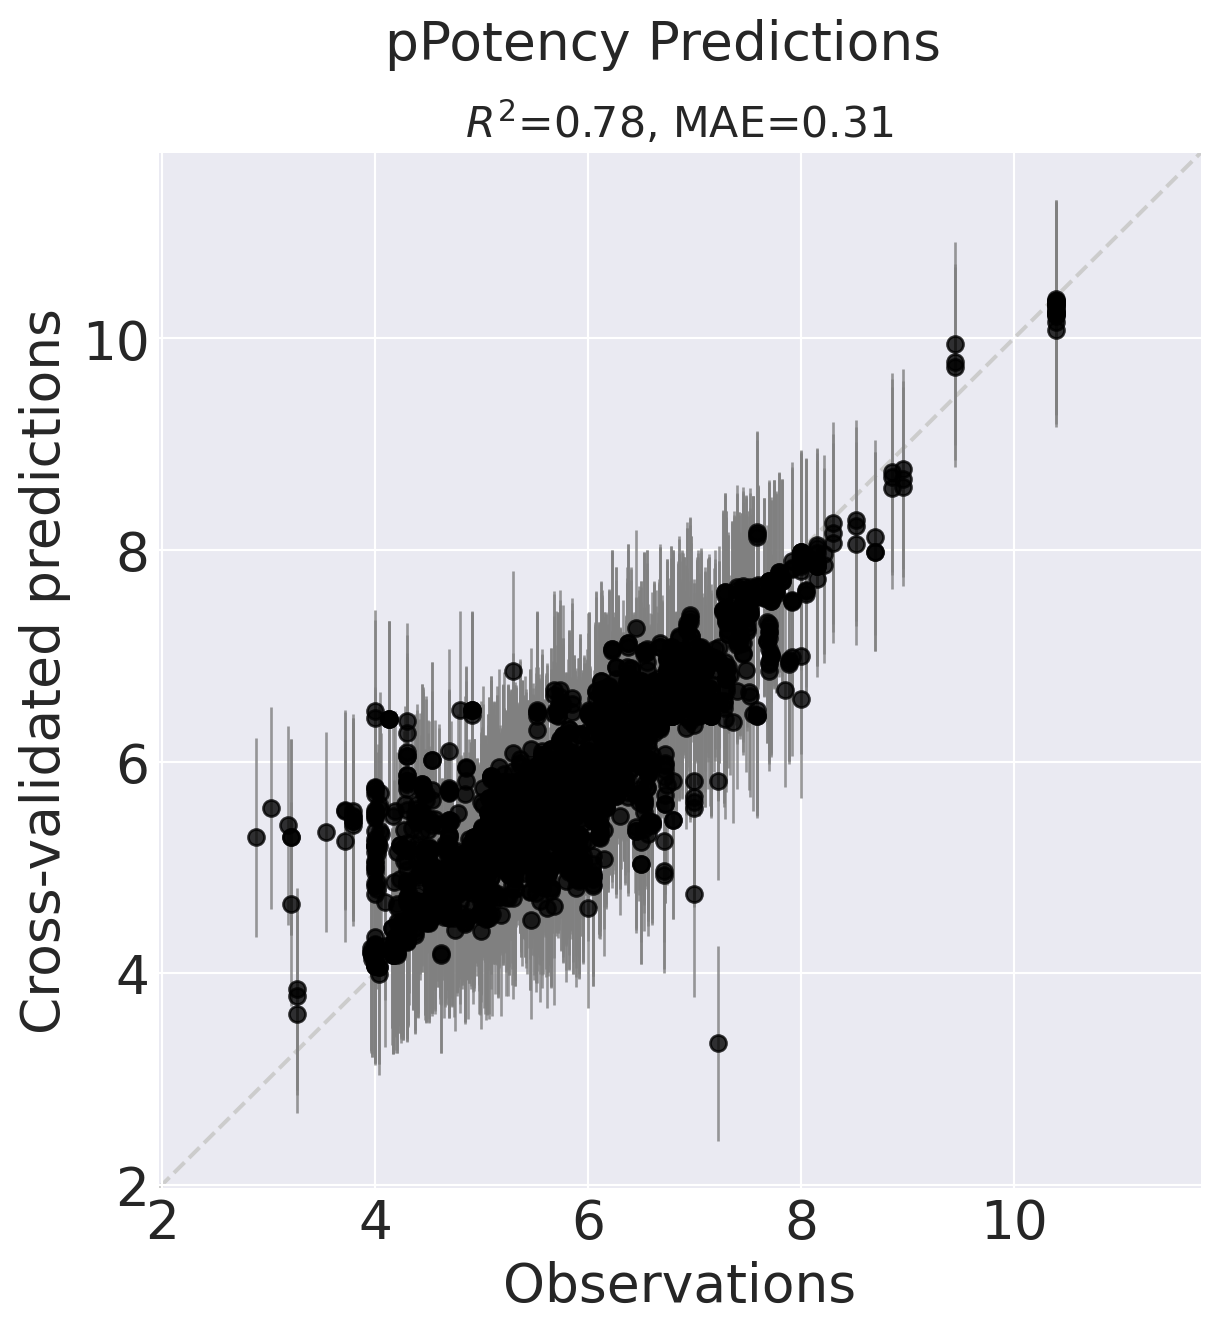

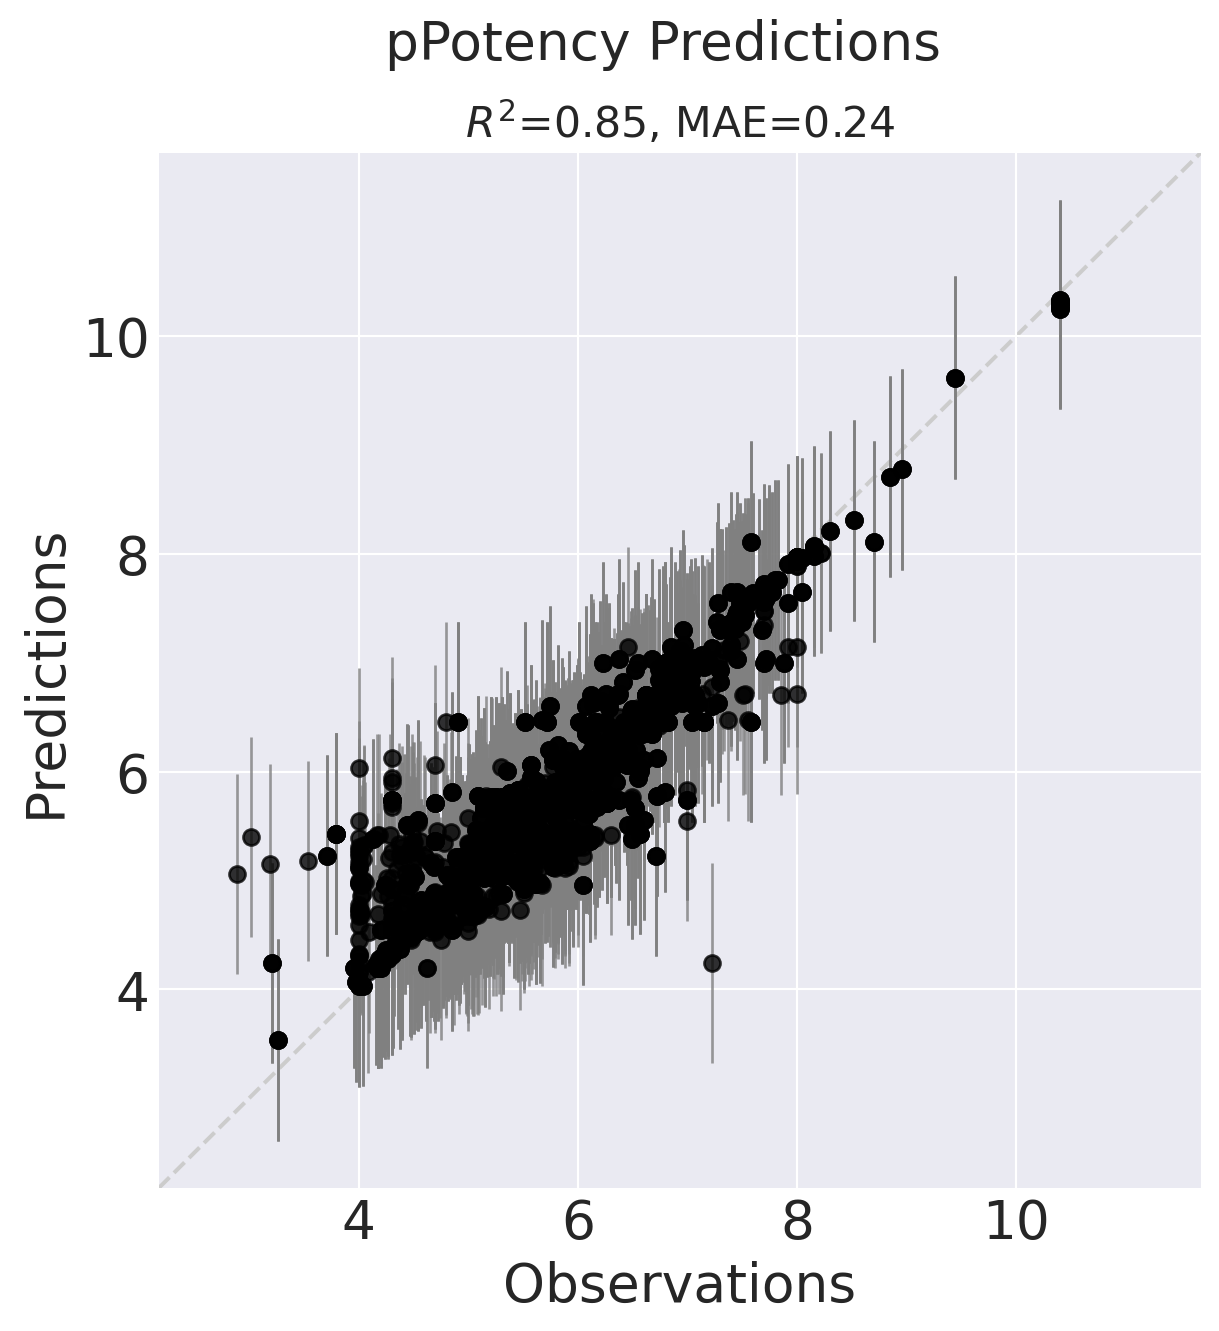

In [19]:
ARTtrainedModelFile = os.path.join(resultsDir, "ART/ART_MACAW/ART_results/art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art_macaw = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art_macaw.output_dir = resultsDir
os.makedirs(art_macaw.output_dir, exist_ok=True)

print(f"ART output directory: {art_macaw.output_dir}")

# Generate both ART plots
predictions_vs_observations(
    art_macaw,
    cv=True,
    error_bars=True
)

predictions_vs_observations(
    art_macaw,
    cv=False,
    error_bars=True
)

### Plot ART model peformance with all embeddings

Loaded MACAW from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART/ART_MACAW/ART_results/art.cpkl
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_ART_MACAW_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_ART_MACAW_CV.png


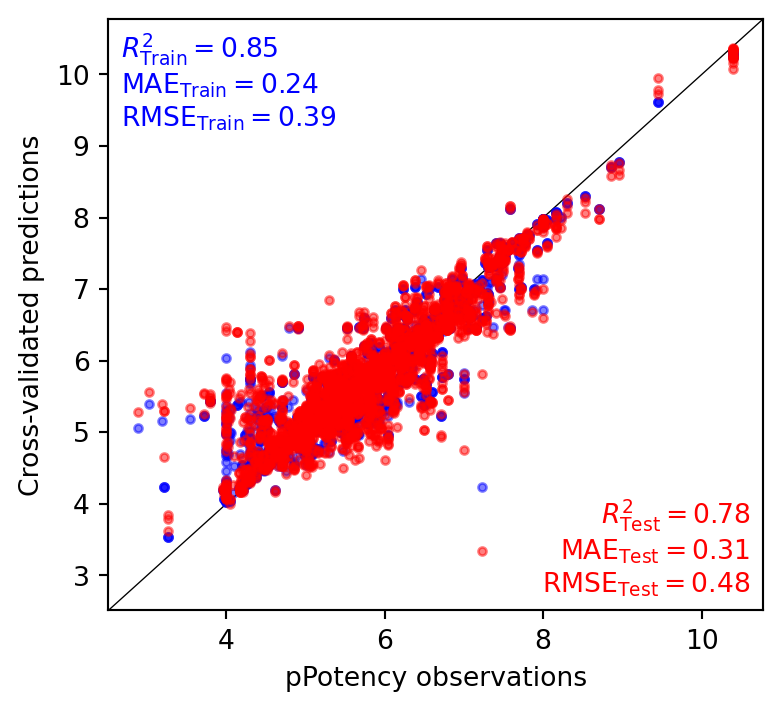

Saved parity plot for MACAW
Loaded MolFormer from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART/ART_MolFormer/ART_results/art_molformer.cpkl
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_ART_MolFormer_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_ART_MolFormer_CV.png


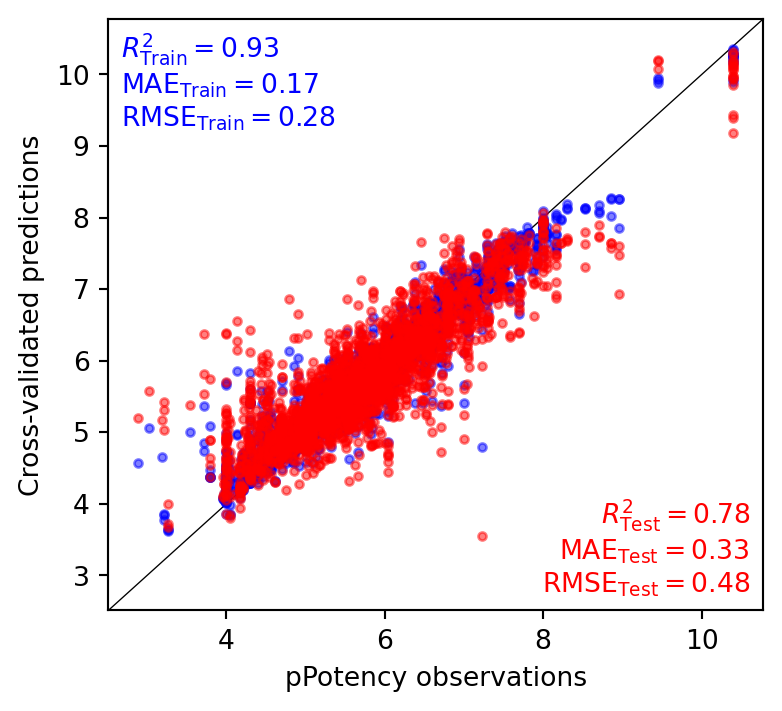

Saved parity plot for MolFormer
Loaded MIST from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART/ART_MIST/ART_results/art_mist.cpkl
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_ART_MIST_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_ART_MIST_CV.png


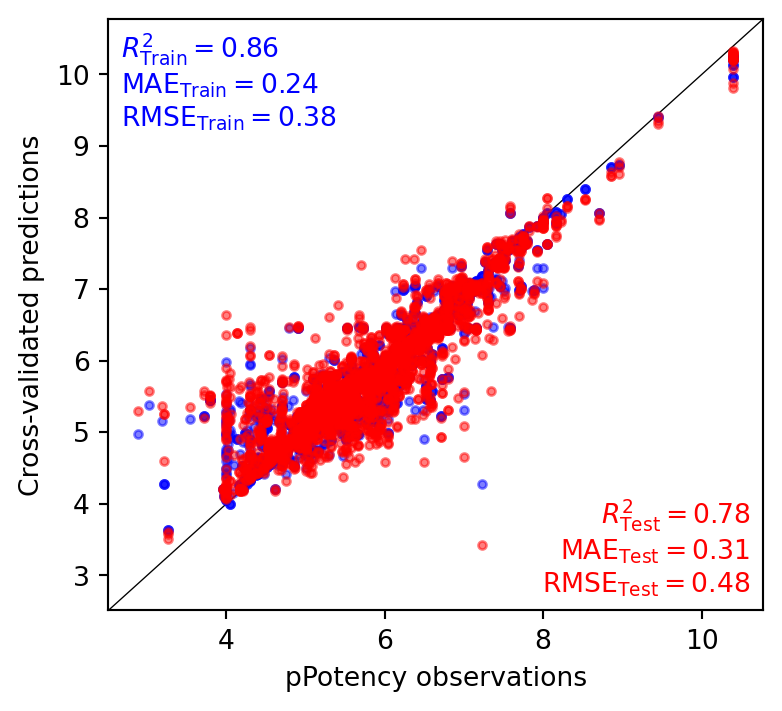

Saved parity plot for MIST
Loaded ChemBERTa from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART/ART_ChemBERTa_wPCA/ART_results/art_chembarta.cpkl
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_ART_ChemBERTa_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirus_allDB_ART_ChemBERTa_CV.png


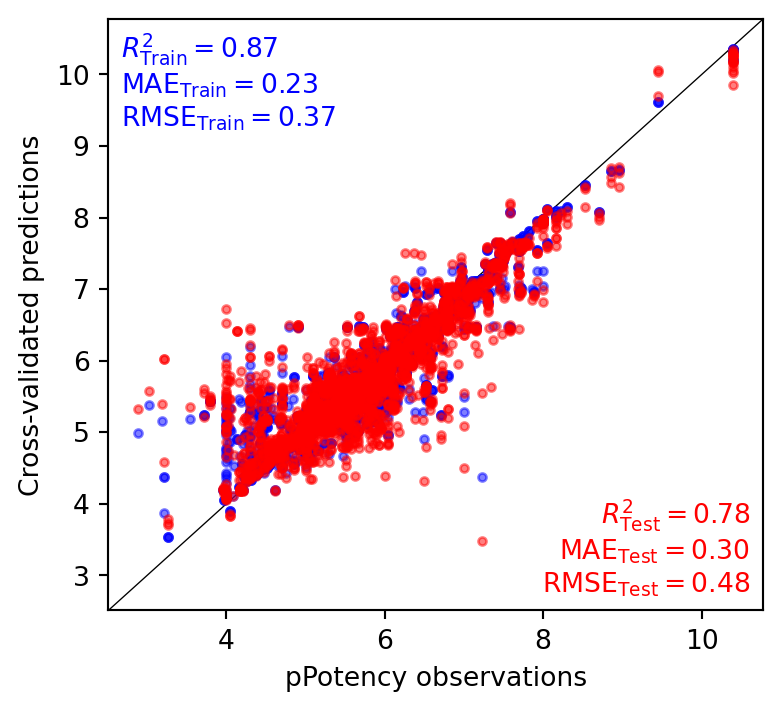

Saved parity plot for ChemBERTa


In [20]:
import numpy as np
import cloudpickle
import os

artModelConfigs = [
    {
        "path":     os.path.join(resultsDir, "ART/ART_MACAW/ART_results/art.cpkl"),
        "label":    "MACAW",
        "saveName": "combinedEbolaVirus_allDB_ART_MACAW_CV",
    },
    {
        "path":     os.path.join(resultsDir, "ART/ART_MolFormer/ART_results/art_molformer.cpkl"),
        "label":    "MolFormer",
        "saveName": "combinedEbolaVirus_allDB_ART_MolFormer_CV",
    },
    {
        "path":     os.path.join(resultsDir, "ART/ART_MIST/ART_results/art_mist.cpkl"),
        "label":    "MIST",
        "saveName": "combinedEbolaVirus_allDB_ART_MIST_CV",
    },
    {
        "path":     os.path.join(resultsDir, "ART/ART_ChemBERTa_wPCA/ART_results/art_chembarta.cpkl"),
        "label":    "ChemBERTa",
        "saveName": "combinedEbolaVirus_allDB_ART_ChemBERTa_CV",
    },
]

for cfg in artModelConfigs:
    with open(cfg["path"], "rb") as f:
        artModel = cloudpickle.load(f)
    artModel.output_dir = resultsDir
    os.makedirs(artModel.output_dir, exist_ok=True)
    print(f"Loaded {cfg['label']} from: {cfg['path']}")

    responseVar = artModel.response_vars[0]
    XTrain      = artModel.df["Input Variables"][artModel.input_vars].values
    yObsTrain   = artModel.df["Response Variables"][responseVar].values

    yPredMeanTrain, _ = artModel.post_pred_stats(XTrain)
    yPredTrain        = yPredMeanTrain[:, 0]

    cvDf    = artModel.model_prediction_cv_dfs[0]
    yPredCv = np.array(cvDf.loc["Ensemble Model (L1)", "Predictions"])
    yObsCv  = yObsTrain.copy()

    parity_plot(
        x=yObsTrain,  y=yPredTrain,
        x_test=yObsCv, y_test=yPredCv,
        xlabel="pPotency observations",
        ylabel="Cross-validated predictions",
        savetitle=resultsDir + cfg["saveName"] + ".svg",
        save_formats=["svg", "png"],
    )
    print(f"Saved parity plot for {cfg['label']}")

# 4. Find external validation with pre-trained `ART` models

## 4.1 Predict pPotency `FDA approved` antivirals from `Drugbank`

In [21]:
drugBankDrug_FDAapproved_Antiviral = pd.read_csv(dataDir + "Toxicity/DrugBank/drugBankDrug_FDAapproved_antiviral_wToxicity.csv", dtype=str)
print(f"Original DrugBank data shape: {drugBankDrug_FDAapproved_Antiviral.shape}")

drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral[["smiles","ATC_code","Drug_Type"]].copy()
# canonicalize and rename
drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"] = drugBankDrug_FDAapproved_Antiviral["smiles"].apply(canonicalizeSmiles)
drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral.drop(columns=["smiles"])
drugBankDrug_FDAapproved_Antiviral

Original DrugBank data shape: (77, 102)


,ATC_code,Drug_Type,Canonical_SMILES
0,J05AF;J05AR,antiviral,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1
1,J05AB,antiviral,Nc1nc(=O)c2ncn(COCCO)c2[nH]1
2,J05AF,antiviral,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...
3,J05AE,antiviral,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...
4,J05AP,antiviral,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...
...,...,...,...
72,J05AB,antiviral,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O
73,J05AP,antiviral,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...
74,J05AF,antiviral,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1
75,J05AH,antiviral,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...


### Check how many common `SMILES` are presents in training set

In [22]:
# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(drugBankDrug_FDAapproved_Antiviral)
drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral[
    ~drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(drugBankDrug_FDAapproved_Antiviral)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(drugBankDrug_FDAapproved_Antiviral)}")

drugBankDrug_FDAapproved_Antiviral

Number of canonical SMILES common to training & external: 1
Training set molecules found and removed (unique canonical overlap): 1
Total buyable antiviral molecules for external validation after removing training set molecules: 76


,ATC_code,Drug_Type,Canonical_SMILES
0,J05AF;J05AR,antiviral,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1
1,J05AB,antiviral,Nc1nc(=O)c2ncn(COCCO)c2[nH]1
2,J05AF,antiviral,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...
3,J05AE,antiviral,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...
4,J05AP,antiviral,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...
...,...,...,...
71,J05AB,antiviral,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O
72,J05AP,antiviral,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...
73,J05AF,antiviral,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1
74,J05AH,antiviral,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...


### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [23]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(drugBankDrug_FDAapproved_Antiviral['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=drugBankDrug_FDAapproved_Antiviral.index)

drugBankDrug_FDAapproved_Antiviral_wMACAW = pd.concat([drugBankDrug_FDAapproved_Antiviral, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {drugBankDrug_FDAapproved_Antiviral.shape}")
print(f"New dataframe shape: {drugBankDrug_FDAapproved_Antiviral_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
drugBankDrug_FDAapproved_Antiviral_wMACAW.to_csv(os.path.join(resultsDir, "drugBankDrug_FDAapproved_Antiviral_wMACAW.csv"), index=False)
drugBankDrug_FDAapproved_Antiviral_wMACAW

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (76, 60)

Original dataframe shape: (76, 3)
New dataframe shape: (76, 63)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58

,ATC_code,Drug_Type,Canonical_SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,J05AF;J05AR,antiviral,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,-0.154581,0.057817,-0.111791,0.122726,-0.066385,0.011532,-0.027614,...,-0.021035,0.031125,0.006020,-0.000483,0.024706,-0.008426,-0.020618,0.031630,-0.006894,-0.008609
1,J05AB,antiviral,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,-0.150799,0.070359,-0.124676,0.105466,-0.118500,0.052182,-0.041103,...,-0.020220,-0.034662,-0.010488,0.029502,0.041084,0.010992,0.006629,0.008703,-0.008122,-0.015621
2,J05AF,antiviral,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,-0.006626,-0.004172,-0.118031,0.000648,0.020309,0.042132,-0.005272,...,-0.036868,-0.024796,-0.025639,0.012159,-0.009462,0.000069,0.027401,-0.036029,-0.016555,-0.002122
3,J05AE,antiviral,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,0.028557,-0.033331,-0.049008,0.035660,0.064683,-0.101755,0.023688,...,0.016377,-0.001431,0.008500,-0.008178,0.005819,-0.001227,0.017319,-0.017944,-0.007595,0.017799
4,J05AP,antiviral,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,0.147636,-0.096422,-0.117657,0.064573,0.094344,0.032768,0.030077,...,-0.035321,0.014993,-0.004221,0.025059,0.004012,0.025031,0.022012,-0.011099,-0.012547,0.000916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,J05AB,antiviral,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,-0.135321,0.060291,-0.204447,0.202536,-0.123838,0.028684,-0.062774,...,0.033813,0.058853,0.026854,0.048385,0.065170,-0.027663,0.019288,0.027312,0.043169,0.029179
72,J05AP,antiviral,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,0.176338,-0.083581,-0.144988,0.059983,0.107786,0.050877,0.025644,...,-0.024515,0.014442,0.012758,0.021303,-0.028253,0.040523,0.028925,-0.029333,-0.027215,0.002229
73,J05AF,antiviral,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,-0.135665,0.109679,-0.131889,0.090855,-0.081821,-0.005869,-0.045836,...,0.026758,-0.021515,-0.002617,0.056013,0.002312,0.041448,0.004929,0.000928,-0.008234,-0.004413
74,J05AH,antiviral,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,-0.087905,0.037014,-0.163909,0.100257,-0.068389,-0.028876,-0.005645,...,0.037752,-0.028109,0.012918,0.026430,0.047356,-0.007208,0.014017,-0.024430,0.012780,-0.024942


In [24]:
macawFeatureCols = [col for col in drugBankDrug_FDAapproved_Antiviral_wMACAW.columns if col.startswith('MACAW_')]
smiLib = drugBankDrug_FDAapproved_Antiviral_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [25]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
drugBankDrug_FDAapproved_Antiviral_wART = drugBankDrug_FDAapproved_Antiviral_wMACAW[['Canonical_SMILES', 'Drug_Type']].copy()

drugBankDrug_FDAapproved_Antiviral_wART['pPotency_prediction'] = mean
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_std'] = std

# Calculate 95% Confidence Intervals
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_lower_95CI'] = mean - 1.96 * std
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_prediction'] = 10 ** (-mean)
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_lower_95CI'] = 10 ** (-drugBankDrug_FDAapproved_Antiviral_wART['pPotency_upper_95CI'])
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_upper_95CI'] = 10 ** (-drugBankDrug_FDAapproved_Antiviral_wART['pPotency_lower_95CI'])

# Select and save results
drugBankDrug_FDAapproved_Antiviral_wART = drugBankDrug_FDAapproved_Antiviral_wART.filter(
    items=["Canonical_SMILES", "Drug_Type", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

drugBankDrug_FDAapproved_Antiviral_wART = (
    drugBankDrug_FDAapproved_Antiviral_wART
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

drugBankDrug_FDAapproved_Antiviral_wART.to_csv(os.path.join(resultsDir + "/drugBankDrug_FDAapproved_Antiviral_wART.csv"), index=False)
drugBankDrug_FDAapproved_Antiviral_wART[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/drugBankDrug_FDAapproved_Antiviral_wART_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = drugBankDrug_FDAapproved_Antiviral_wART.loc[drugBankDrug_FDAapproved_Antiviral_wART["pPotency_prediction"].idxmin()]
potency_max = drugBankDrug_FDAapproved_Antiviral_wART.loc[drugBankDrug_FDAapproved_Antiviral_wART["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.2f} ± {min_std:.2f} - {max_pred:.2f} ± {max_std:.2f}")

drugBankDrug_FDAapproved_Antiviral_wART

Predicted potency range: 5.11 ± 0.48 - 6.63 ± 0.47


,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,antiviral,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002
1,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,antiviral,6.421459,0.473641,5.493123,7.349796,3.789141e-07,4.468939e-08,0.000003
2,CC(C)(C)[C@@H]1NC(=O)O[C@@H]2CCC[C@H]2OC/C=C/C...,antiviral,6.360733,0.474828,5.430070,7.291396,4.357794e-07,5.112152e-08,0.000004
3,COC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)Nc1ccc([C@@...,antiviral,6.231433,0.474520,5.301375,7.161492,5.869038e-07,6.894589e-08,0.000005
4,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc2cc([C@H]3CC...,antiviral,6.192363,0.472963,5.265355,7.119371,6.421502e-07,7.596762e-08,0.000005
...,...,...,...,...,...,...,...,...,...
71,CC(C)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@H](n...,antiviral,5.157025,0.475299,4.225440,6.088610,6.965867e-06,8.154363e-07,0.000060
72,CN(C)CCOCC(=O)NC12CC3CC(CC(C3)C1)C2,antiviral,5.146557,0.478147,4.209389,6.083725,7.135807e-06,8.246596e-07,0.000062
73,CC(C)[C@H](N)C(=O)OCCOCn1cnc2c(=O)nc(N)[nH]c21,antiviral,5.122079,0.478454,4.184309,6.059849,7.549542e-06,8.712659e-07,0.000065
74,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,antiviral,5.116885,0.481782,4.172592,6.061179,7.640375e-06,8.686028e-07,0.000067


### Compute `ADMET profile` of all `FDA approved` antibiotics

In [26]:
model = ADMETModel()
pred = model.predict(smiles=drugBankDrug_FDAapproved_Antiviral_wART["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
drugBankDrug_FDAapproved_Antiviral_wART_wADMET = drugBankDrug_FDAapproved_Antiviral_wART.merge(pred, on="Canonical_SMILES", how="left")
drugBankDrug_FDAapproved_Antiviral_wART_wADMET

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,antiviral,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,602.585,...,17.855888,32.548330,87.381371,56.028120,15.536028,96.731107,79.613357,70.298770,48.189807,68.611599
1,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,antiviral,6.421459,0.473641,5.493123,7.349796,3.789141e-07,4.468939e-08,0.000003,868.948,...,33.743409,47.451670,84.323374,66.362039,33.110721,95.676626,87.662566,95.676626,10.966608,19.437610
2,CC(C)(C)[C@@H]1NC(=O)O[C@@H]2CCC[C@H]2OC/C=C/C...,antiviral,6.360733,0.474828,5.430070,7.291396,4.357794e-07,5.112152e-08,0.000004,838.878,...,29.384886,28.014060,75.395431,53.040422,27.065026,96.590510,74.446397,88.084359,18.699473,14.657293
3,COC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)Nc1ccc([C@@...,antiviral,6.231433,0.474520,5.301375,7.161492,5.869038e-07,6.894589e-08,0.000005,894.127,...,22.249561,61.300527,94.235501,91.458699,13.673111,94.270650,99.578207,97.504394,3.971880,70.685413
4,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc2cc([C@H]3CC...,antiviral,6.192363,0.472963,5.265355,7.119371,6.421502e-07,7.596762e-08,0.000005,1113.199,...,26.924429,3.339192,82.319859,97.434095,9.173989,99.964851,99.683656,94.938489,4.217926,92.794376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,CC(C)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@H](n...,antiviral,5.157025,0.475299,4.225440,6.088610,6.965867e-06,8.154363e-07,0.000060,529.458,...,20.246046,46.959578,77.680141,3.233743,20.351494,91.845343,58.980668,52.688928,56.555360,18.418278
72,CN(C)CCOCC(=O)NC12CC3CC(CC(C3)C1)C2,antiviral,5.146557,0.478147,4.209389,6.083725,7.135807e-06,8.246596e-07,0.000062,280.412,...,78.101933,67.908612,56.098418,42.355009,74.551845,61.546573,46.362039,22.530756,67.557118,61.968366
73,CC(C)[C@H](N)C(=O)OCCOCn1cnc2c(=O)nc(N)[nH]c21,antiviral,5.122079,0.478454,4.184309,6.059849,7.549542e-06,8.712659e-07,0.000065,324.341,...,13.778559,27.100176,33.673111,8.154657,12.583480,40.456942,16.731107,21.089631,61.089631,67.838313
74,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,antiviral,5.116885,0.481782,4.172592,6.061179,7.640375e-06,8.686028e-07,0.000067,225.208,...,16.309315,25.026362,20.281195,18.488576,14.727592,24.639719,16.414763,21.933216,65.272408,70.861160


### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [27]:
# Potency-related columns
dataCols = ["Canonical_SMILES","Drug_Type"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_Antiviral_wART_wADMET.columns
]

drugBankDrug_FDAapproved_Antiviral_wART_wADMET = drugBankDrug_FDAapproved_Antiviral_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_Antiviral_wART_wADMET.shape)
drugBankDrug_FDAapproved_Antiviral_wART_wADMET.to_csv(resultsDir + "drugBankDrug_FDAapproved_Antiviral_wART_wADMET.csv", index=False)
drugBankDrug_FDAapproved_Antiviral_wART_wADMET.head()

Filtered dataframe shape: (76, 42)


,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,antiviral,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,0.473479,...,0.277044,0.757844,0.001464,0.091504,0.089238,0.112458,0.049566,0.061976,0.630507,0.594246
1,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,antiviral,6.421459,0.473641,5.493123,7.349796,3.789141e-07,4.468939e-08,0.000003,0.402790,...,0.828310,0.719191,0.000117,0.095870,0.049874,0.261650,0.025222,0.006694,0.876515,0.975297
2,CC(C)(C)[C@@H]1NC(=O)O[C@@H]2CCC[C@H]2OC/C=C/C...,antiviral,6.360733,0.474828,5.430070,7.291396,4.357794e-07,5.112152e-08,0.000004,0.402193,...,0.566219,0.692124,0.000146,0.062885,0.067880,0.181337,0.019857,0.011510,0.771802,0.868724
3,COC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)Nc1ccc([C@@...,antiviral,6.231433,0.474520,5.301375,7.161492,5.869038e-07,6.894589e-08,0.000005,0.110028,...,0.472612,0.741510,0.000094,0.232419,0.103702,0.511647,0.014375,0.013199,0.846098,0.938079
4,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc2cc([C@H]3CC...,antiviral,6.192363,0.472963,5.265355,7.119371,6.421502e-07,7.596762e-08,0.000005,0.078322,...,0.677893,0.716190,0.000045,0.234808,0.075199,0.690765,0.026800,0.019639,0.937238,0.997227


### Read `ADMET` endpoints for the `withdrawn` drugs from `Drugbank`

In [28]:
drugBankDrugWithdrawnDataDF = pd.read_csv(dataDir + '/Toxicity/DrugBank/drugBankDrugWithdrawnDataDF_wADMET.csv')
drugBankDrugWithdrawnDataDF

,Unnamed: 0,DrugBank ID,Drug Groups,Name,Formula,CAS Number,InChIKey,ChEMBL ID,SMILES,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,0,DB00106,approved; investigational; withdrawn,Abarelix,C72H95ClN14O14,183552-38-7,AIWRTTMUVOZGPW-HSPKUQOVSA-N,CHEMBL1252,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,0.244807,...,0.463332,0.605704,0.017399,0.263449,0.207183,0.100211,0.232910,0.125635,0.925135,0.938593
1,1,DB00131,approved; investigational; nutraceutical; with...,Adenosine phosphate,C10H14N5O7P,61-19-8,UDMBCSSLTHHNCD-KQYNXXCUSA-N,CHEMBL752,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,0.215953,...,0.027663,0.470261,0.000746,0.008154,0.066037,0.003312,0.010593,0.036415,0.061753,0.000318
2,2,DB00132,approved; investigational; nutraceutical; with...,alpha-Linolenic acid,C18H30O2,463-40-1,DTOSIQBPPRVQHS-PDBXOOCHSA-N,CHEMBL8739,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,0.494518,...,0.737525,0.696307,0.166940,0.244747,0.189303,0.188501,0.161169,0.020346,0.343310,0.108636
3,3,DB00138,approved; investigational; nutraceutical; with...,Cystine,C6H12N2O4S2,56-89-3,LEVWYRKDKASIDU-IMJSIDKUSA-N,CHEMBL590540,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,0.678855,...,0.086299,0.860139,0.031484,0.182946,0.114121,0.124554,0.160284,0.026472,0.090174,0.046522
4,4,DB00150,approved; investigational; nutraceutical; with...,Tryptophan,C11H12N2O2,73-22-3,QIVBCDIJIAJPQS-VIFPVBQESA-N,CHEMBL54976,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,0.227781,...,0.227191,0.956495,0.102633,0.029928,0.428593,0.004736,0.231113,0.026281,0.171291,0.030738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,604,DB19382,approved; withdrawn,Benzoylpas,C14H11NO4,13898-58-3,GNZCRYWFWKFIDM-UHFFFAOYSA-N,CHEMBL1487804,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,0.250689,...,0.094615,0.934835,0.072102,0.036693,0.347887,0.206038,0.039468,0.026548,0.103570,0.006168
605,605,DB19383,approved; withdrawn,Pentapiperium,C19H30NO2,26372-86-1,WSWDKMFWJOALEW-UHFFFAOYSA-N,CHEMBL2111014,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,0.010421,...,0.845728,0.240165,0.000727,0.004731,0.050183,0.001061,0.538791,0.215035,0.560323,0.001474
606,606,DB20118,approved; withdrawn,Dichlorotetrafluoroethane,C2Cl2F4,76-14-2,DDMOUSALMHHKOS-UHFFFAOYSA-N,CHEMBL325436,FC(F)(Cl)C(F)(F)Cl,0.013408,...,0.984755,0.942265,0.243439,0.567955,0.310735,0.045990,0.262644,0.001311,0.650809,0.001634
607,607,DB20138,approved; withdrawn,Tribromsalan,C13H8Br3NO2,87-10-5,KVSKGMLNBAPGKH-UHFFFAOYSA-N,CHEMBL24944,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,0.139711,...,0.753677,0.839571,0.949634,0.672943,0.431539,0.900576,0.232279,0.186494,0.658334,0.171204


In [29]:
drugBankDrugWithdrawnDataDF["Canonical_SMILES"] = (
    drugBankDrugWithdrawnDataDF["SMILES"].apply(canonicalizeSmiles))

# Keep only Name + Canonical_SMILES and add Drug_Type
drugBankDrugWithdrawnDataDF = drugBankDrugWithdrawnDataDF[
    ["Name", "Canonical_SMILES"]].copy()

drugBankDrugWithdrawnDataDF["Drug_Type"] = "withdrawn"
drugBankDrugWithdrawnDataDF

,Name,Canonical_SMILES,Drug_Type
0,Abarelix,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,withdrawn
1,Adenosine phosphate,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,withdrawn
2,alpha-Linolenic acid,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,withdrawn
3,Cystine,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,withdrawn
4,Tryptophan,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,withdrawn
...,...,...,...
604,Benzoylpas,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,withdrawn
605,Pentapiperium,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,withdrawn
606,Dichlorotetrafluoroethane,FC(F)(Cl)C(F)(F)Cl,withdrawn
607,Tribromsalan,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,withdrawn


### Compute `ADMET profile` of all `FDA withdrawn` drugs (we do not know the category like antiviral/antibiotic)

In [30]:
model = ADMETModel()
pred = model.predict(smiles=drugBankDrugWithdrawnDataDF["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF.merge(pred, on="Canonical_SMILES", how="left")
drugBankDrugWithdrawnDataDF_wADMET

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,Name,Canonical_SMILES,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Abarelix,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,withdrawn,1416.089,1.1680,16,13,1.0,0.024675,10,...,3.725835,22.917399,94.446397,54.692443,3.198594,84.253076,59.086116,69.279438,51.739895,54.973638
1,Adenosine phosphate,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,withdrawn,347.224,-1.8630,9,5,4.0,0.390179,4,...,7.029877,17.609842,42.460457,38.558875,6.783831,21.898067,24.147627,21.687170,80.702988,72.126538
2,alpha-Linolenic acid,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,withdrawn,278.436,5.6605,1,1,3.0,0.348410,0,...,80.843585,89.490334,77.188049,2.284710,89.138840,10.755712,70.123023,84.639719,19.718805,29.068541
3,Cystine,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,withdrawn,240.306,-0.8084,6,4,4.0,0.336025,2,...,10.474517,32.794376,38.804921,8.435852,16.414763,22.214411,14.657293,31.564148,62.917399,6.889279
4,Tryptophan,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,withdrawn,204.229,1.1223,2,3,4.0,0.700584,1,...,19.332162,14.868190,12.513181,15.079086,25.659051,53.005272,21.652021,32.513181,72.794376,25.553603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,Benzoylpas,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,withdrawn,257.245,2.3427,3,3,4.0,0.787225,0,...,39.086116,49.490334,31.599297,11.704745,35.114236,19.718805,29.630931,66.467487,39.156415,22.214411
605,Pentapiperium,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,withdrawn,304.454,3.5983,2,0,4.0,0.613551,2,...,79.929701,62.495606,33.954306,60.702988,72.548330,42.390158,34.973638,16.274165,80.175747,75.711775
606,Dichlorotetrafluoroethane,FC(F)(Cl)C(F)(F)Cl,withdrawn,170.920,2.6496,0,0,4.0,0.419713,0,...,99.437610,91.950791,68.049209,72.442882,99.824253,0.421793,68.049209,36.801406,55.079086,84.674868
607,Tribromsalan,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,withdrawn,449.924,4.9320,2,2,4.0,0.682461,0,...,54.692443,74.235501,75.043937,97.574692,70.123023,66.080844,91.142355,81.898067,8.049209,94.130053


### Retain only `Canonical_SMILES`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [31]:
# Potency-related columns
dataCols = ["Name","Canonical_SMILES","Drug_Type"]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrugWithdrawnDataDF_wADMET.columns
]

drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrugWithdrawnDataDF_wADMET.shape)
drugBankDrugWithdrawnDataDF_wADMET.to_csv(resultsDir + "drugBankDrugWithdrawnDataDF_wADMET.csv", index=False)
drugBankDrugWithdrawnDataDF_wADMET.head()

Filtered dataframe shape: (609, 36)


,Name,Canonical_SMILES,Drug_Type,AMES,hERG,DILI,ClinTox,Carcinogens_Lagunin,Skin_Reaction,LD50_Zhu,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Abarelix,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,withdrawn,0.254504,0.981034,0.470070,0.309441,0.066228,0.117368,3.057549,...,0.011846,0.223714,0.000003,0.029137,0.004623,0.127366,0.004255,0.238418,0.695700,0.997110
1,Adenosine phosphate,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,withdrawn,0.332332,0.071598,0.720851,0.552732,0.126209,0.204692,1.965409,...,0.001456,0.181162,0.000473,0.027287,0.008534,0.011404,0.001425,0.024123,0.049317,0.001035
2,alpha-Linolenic acid,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,withdrawn,0.237453,0.234704,0.159396,0.105420,0.264607,0.763378,1.705102,...,0.727614,0.690413,0.038983,0.054847,0.270240,0.044004,0.203606,0.062427,0.563903,0.036418
3,Cystine,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,withdrawn,0.722585,0.013167,0.049900,0.039962,0.234551,0.722627,1.971292,...,0.047806,0.516514,0.001128,0.006420,0.008872,0.002367,0.031434,0.001855,0.049758,0.000370
4,Tryptophan,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,withdrawn,0.286964,0.224766,0.344543,0.237204,0.320831,0.499903,2.486238,...,0.474984,0.870896,0.238705,0.042194,0.192286,0.022449,0.227100,0.082563,0.260672,0.013772


## 4.2 Checking drug likeliness of custom compounds:
- `Remdesivir`
- `Molnupiravir`
- `Favipiravir`
- `Brincidofovir`

In [32]:
querySmilesDict = {
    "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Molnupiravir": r"CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O",
    "Favipiravir": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

queryCanonicalDict = {name: canonicalizeSmiles(smiles) for name, smiles in querySmilesDict.items()}

queryAntiviralsDF = pd.DataFrame(
    [{"drugName": name, "Canonical_SMILES": cs} for name, cs in queryCanonicalDict.items()])

queryAntiviralsDF

,drugName,Canonical_SMILES
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...
2,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O
3,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...


### Are they present in training data ?

In [33]:
# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    queryAntiviralsDF["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(queryAntiviralsDF)
queryAntiviralsDF = queryAntiviralsDF[
    ~queryAntiviralsDF["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(queryAntiviralsDF)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(queryAntiviralsDF)}")

queryAntiviralsDF

Number of canonical SMILES common to training & external: 0
Training set molecules found and removed (unique canonical overlap): 0
Total buyable antiviral molecules for external validation after removing training set molecules: 4


,drugName,Canonical_SMILES
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...
2,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O
3,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...


### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [34]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(queryAntiviralsDF['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=queryAntiviralsDF.index)

queryAntiviralsDF_wMACAW = pd.concat([queryAntiviralsDF, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {queryAntiviralsDF.shape}")
print(f"New dataframe shape: {queryAntiviralsDF_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
queryAntiviralsDF_wMACAW.to_csv(os.path.join(resultsDir, "queryAntiviralsDF_wMACAW.csv"), index=False)
queryAntiviralsDF_wMACAW

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (4, 60)

Original dataframe shape: (4, 2)
New dataframe shape: (4, 62)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 

,drugName,Canonical_SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.143171,-0.169881,-0.294594,0.160284,0.215070,-0.007827,0.052498,-0.021193,...,0.017305,0.001557,-0.007112,-0.053585,0.014354,-0.041146,-0.008522,0.004131,0.017275,0.000606
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,-0.078102,0.012838,-0.184307,0.102667,-0.014136,-0.028947,-0.032610,0.027960,...,0.011424,-0.034138,-0.017162,-0.006987,0.027272,0.013374,0.007422,-0.037038,0.008317,-0.046365
2,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,-0.195735,0.085677,-0.154042,0.164502,-0.220953,0.156392,-0.130209,-0.057172,...,-0.000985,0.009235,0.000004,0.016693,-0.000150,-0.015894,0.002341,-0.043229,-0.002557,-0.011280
3,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,0.116127,0.019739,-0.093622,0.031452,-0.017005,0.028041,-0.000266,-0.022467,...,0.066637,0.025010,0.020967,0.012361,0.027155,0.019631,-0.016332,-0.079580,-0.021357,-0.025923


In [35]:
macawFeatureCols = [col for col in queryAntiviralsDF_wMACAW.columns if col.startswith('MACAW_')]
smiLib = queryAntiviralsDF_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [36]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
queryAntiviralsDF_ARTprediction = queryAntiviralsDF_wMACAW[['Canonical_SMILES', 'drugName']].copy()

queryAntiviralsDF_ARTprediction['pPotency_prediction'] = mean
queryAntiviralsDF_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
queryAntiviralsDF_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
queryAntiviralsDF_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
queryAntiviralsDF_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
queryAntiviralsDF_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-queryAntiviralsDF_ARTprediction['pPotency_upper_95CI'])
queryAntiviralsDF_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-queryAntiviralsDF_ARTprediction['pPotency_lower_95CI'])

# Select and save results
queryAntiviralsDF_ARTprediction = queryAntiviralsDF_ARTprediction.filter(
    items=["Canonical_SMILES", "drugName", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

queryAntiviralsDF_ARTprediction = (
    queryAntiviralsDF_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

queryAntiviralsDF_ARTprediction.to_csv(os.path.join(resultsDir + "/queryAntiviralsDF_ARTprediction.csv"), index=False)
queryAntiviralsDF_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/queryAntiviralsDF_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = queryAntiviralsDF_ARTprediction.loc[queryAntiviralsDF_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = queryAntiviralsDF_ARTprediction.loc[queryAntiviralsDF_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.2f} ± {min_std:.2f} - {max_pred:.2f} ± {max_std:.2f}")

queryAntiviralsDF_ARTprediction

Predicted potency range: 4.91 ± 0.48 - 6.63 ± 0.47


,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir,5.503281,0.471096,4.579933,6.426628,3.138479e-06,3.744309e-07,0.000026
2,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,Molnupiravir,5.244613,0.477223,4.309255,6.179970,5.693607e-06,6.607385e-07,0.000049
3,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir,4.908812,0.481485,3.965101,5.852524,1.233637e-05,1.404352e-06,0.000108


### Plot prediction `probability`

Molecule 1: mean=6.62, std=0.48, 95% CI=[5.69, 7.54], IC50=0.2400 µM
Molecule 2: mean=5.51, std=0.48, 95% CI=[4.60, 6.44], IC50=3.0968 µM
Molecule 3: mean=5.24, std=0.48, 95% CI=[4.29, 6.17], IC50=5.8155 µM
Molecule 4: mean=4.92, std=0.48, 95% CI=[3.99, 5.84], IC50=12.0927 µM


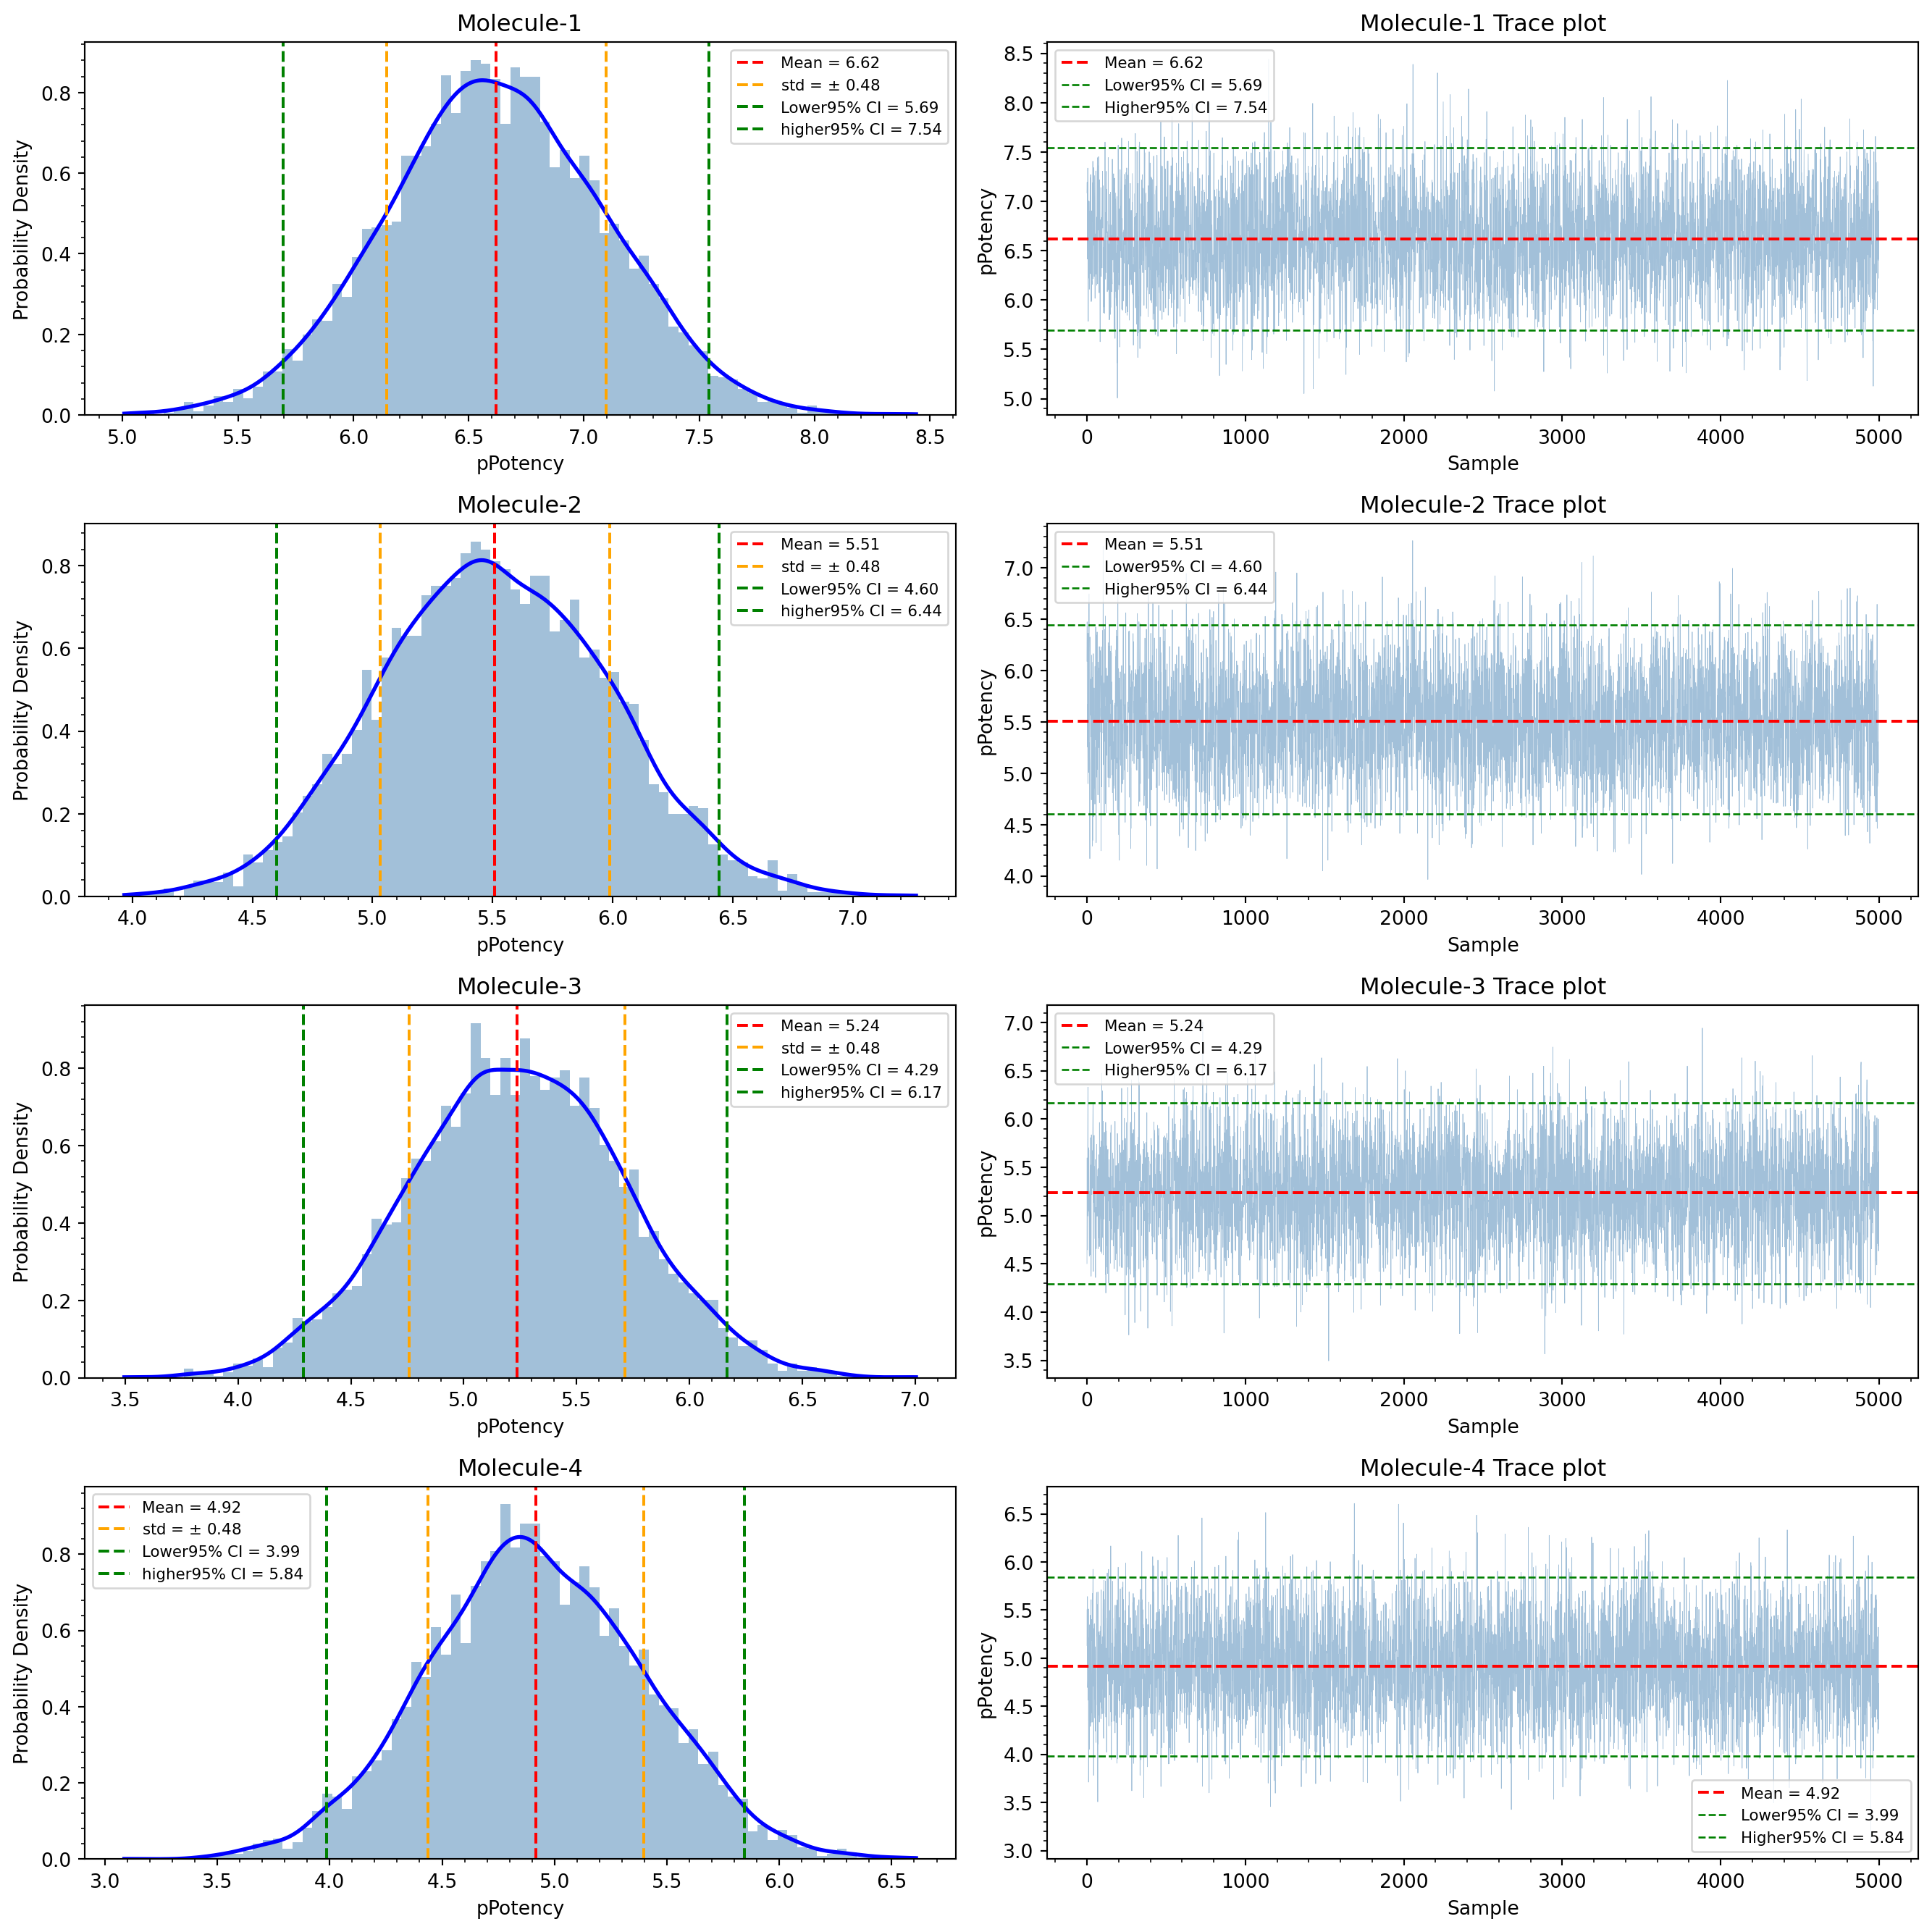

In [37]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.2f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.2f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.2f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.2f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.2f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.2f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.2f}, std={std:.2f}, "
              f"95% CI=[{lower_95:.2f}, {upper_95:.2f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "queryAntiviralsDF_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "queryAntiviralsDF_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=queryAntiviralsDF_ARTprediction,
    feat_df=queryAntiviralsDF_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Show compounds

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/queryAntiviralsDF_wARTprediction_all_Compounds.png
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/queryAntiviralsDF_wARTprediction_all_Compounds.svg


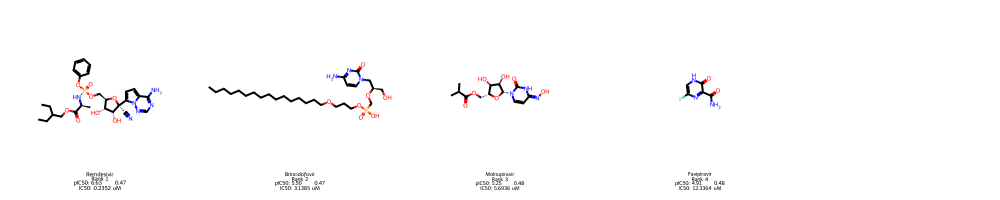

In [38]:
df = queryAntiviralsDF_ARTprediction.sort_values("pPotency_prediction", ascending=False).reset_index(drop=True)

p = df["pPotency_prediction"].to_numpy()
df["Rank"] = np.arange(1, len(df) + 1)
df["pPotency_prediction"] = np.round(p, 3)
df["IC50 (µM)"] = (10 ** (-p)) * 1e6

std_arr = df["pPotency_std"].to_numpy() if "pPotency_std" in df.columns else None
ic50_arr = df["IC50 (µM)"].to_numpy()
p_arr = df["pPotency_prediction"].to_numpy()
drug_arr = df["drugName"].to_numpy()
smi_arr = df["Canonical_SMILES"].to_numpy()

legends = []
for drug, pp, ic, ss in zip(drug_arr, p_arr, ic50_arr, std_arr if std_arr is not None else [None]*len(df)):
    if ss is not None and pd.notna(ss):
        legends.append(f"{drug}\nRank {len(legends)+1}\npIC50: {pp:.2f} ± {ss:.2f}\nIC50: {ic:.4f} uM")
    else:
        legends.append(f"{drug}\nRank {len(legends)+1}\npIC50: {pp:.2f}\nIC50: {ic:.4f} uM")

molecules = []
legends_ok = []
for smi, leg in zip(smi_arr, legends):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        molecules.append(mol)
        legends_ok.append(leg)

output_png = os.path.join(resultsDir, "queryAntiviralsDF_wARTprediction_all_Compounds.png")
png = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                            legends=legends_ok, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(png.data if hasattr(png, "data") else png)

output_svg = os.path.join(resultsDir, "queryAntiviralsDF_wARTprediction_all_Compounds.svg")
svg = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                            legends=legends_ok, useSVG=True)
with open(output_svg, "w") as f:
    f.write(svg.data if hasattr(svg, "data") else svg)

print("Saved:", output_png)
print("Saved:", output_svg)
display(png)

### Compute their ADMET profile

In [39]:
model = ADMETModel()
pred = model.predict(smiles=queryAntiviralsDF_ARTprediction["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
queryAntiviralsDF_wART_wADMET = queryAntiviralsDF_ARTprediction.merge(pred, on="Canonical_SMILES", how="left")
queryAntiviralsDF_wART_wADMET

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,602.585,...,17.855888,32.548330,87.381371,56.028120,15.536028,96.731107,79.578207,70.298770,48.189807,68.646749
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir,5.503281,0.471096,4.579933,6.426628,3.138479e-06,3.744309e-07,0.000026,561.701,...,25.448155,77.188049,84.358524,73.251318,30.509666,56.274165,77.680141,70.615114,23.585237,94.411248
2,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,Molnupiravir,5.244613,0.477223,4.309255,6.179970,5.693607e-06,6.607385e-07,0.000049,329.309,...,16.414763,45.272408,33.321617,5.166960,11.528998,10.474517,18.242531,27.873462,64.815466,42.003515
3,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir,4.908812,0.481485,3.965101,5.852524,1.233637e-05,1.404352e-06,0.000108,157.104,...,72.091388,34.657293,15.395431,20.949033,51.001757,44.288225,30.439367,18.664323,76.766257,9.525483


## 4.3.1.1 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

DORAnet starter: `Inosine + Guanosine + Xanthosine + Adenosine`

### Import all compounds generated by `DORAnet` from `Inosine` only (gen=3) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Inosine` only (gen=3) --> Possible `Antivirals` 
- *with substructure match*

In [40]:
InosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Inosine_Pubchem/InosineOnly_gen3/InosineOnly_gen3_generated_compounds.csv", dtype=str)
print(f"Loaded {len(InosineOnly_DORAnetGenerated)} molecules")
InosineOnly_DORAnetGenerated['source_DataBase'] = 'InosineOnly_gen3'
InosineOnly_DORAnetGenerated

Loaded 4122 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore,source_DataBase
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]...,3,0.5231,NaN,InosineOnly_gen3
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O...,3,0.5556,NaN,InosineOnly_gen3
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]...,3,0.5556,NaN,InosineOnly_gen3
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,3,0.5231,NaN,InosineOnly_gen3
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,3,0.5469,NaN,InosineOnly_gen3
...,...,...,...,...,...,...
4117,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O,3,0.0208,NaN,InosineOnly_gen3
4118,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)=O,3,0.0426,NaN,InosineOnly_gen3
4119,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,N#CC=O,3,0.0204,NaN,InosineOnly_gen3
4120,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CCO,3,0.0682,NaN,InosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Adenosine` only (gen=3) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Adenosine` only (gen=3) --> Possible `Antivirals`
- *with substructure match*

In [41]:
AdenosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Adenosine_Pubchem/AdenosineOnly_gen3/AdenosineOnly_generated_compounds.csv", dtype=str)
print(f"Loaded {len(AdenosineOnly_DORAnetGenerated)} molecules")
AdenosineOnly_DORAnetGenerated['source_DataBase'] = 'AdenosineOnly_gen3'
AdenosineOnly_DORAnetGenerated

Loaded 4045 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore,source_DataBase
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](CO)[...,3,0.3939,NaN,AdenosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CCC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](CO)...,3,0.5965,NaN,AdenosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](C(C)...,3,0.4062,NaN,AdenosineOnly_gen3
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,COC[C@H]1O[C@@H](n2cnc3c(N(C(C)=O)C(N)=O)ncnc3...,3,0.4839,NaN,AdenosineOnly_gen3
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@]1(C)O[C@H](CO...,3,0.3382,NaN,AdenosineOnly_gen3
...,...,...,...,...,...,...
4040,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,O=CCO,3,0.0667,NaN,AdenosineOnly_gen3
4041,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(N)=O,3,0.0444,NaN,AdenosineOnly_gen3
4042,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,N#CC=O,3,0.0,NaN,AdenosineOnly_gen3
4043,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CCO,3,0.0714,NaN,AdenosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Guanosine` only (gen=3) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Guanosine` only (gen=3) --> Possible `Antivirals`
- *with substructure match*

In [42]:
GuanosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Guanosine_Pubchem/GuanosineOnly_gen3/GuanosineOnly_gen3_generated_compounds.csv", dtype=str)
print(f"Loaded {len(GuanosineOnly_DORAnetGenerated)} molecules")
GuanosineOnly_DORAnetGenerated['source_DataBase'] = 'GuanosineOnly_gen3'
GuanosineOnly_DORAnetGenerated

Loaded 3962 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore,source_DataBase
0,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CO[C@H]1[C@@H](O)[C@H](n2c[n+](C)c3c(=O)[nH]c(...,3,0.3973,NaN,GuanosineOnly_gen3
1,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CO[C@@H]1[C@H](OS(=O)(=O)O)[C@@H](CO)O[C@H]1n1...,3,0.4028,NaN,GuanosineOnly_gen3
2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CNc1nc2c(c(=O)[nH]1)[n+](C)cn2[C@@H]1O[C@H](CO...,3,0.3333,NaN,GuanosineOnly_gen3
3,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CNc1nc2c(c(=O)[nH]1)[n+](C)cn2[C@@H]1O[C@H](CO...,3,0.3467,NaN,GuanosineOnly_gen3
4,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CO[C@H]1[C@@H](OS(=O)(=O)O)[C@H](n2c[n+](C)c3c...,3,0.4028,NaN,GuanosineOnly_gen3
...,...,...,...,...,...,...
3957,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=CCO,3,0.0816,NaN,GuanosineOnly_gen3
3958,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(N)=O,3,0.0612,NaN,GuanosineOnly_gen3
3959,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,N#CC=O,3,0.0192,NaN,GuanosineOnly_gen3
3960,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CCO,3,0.0638,NaN,GuanosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Xanthosine` only (gen=3) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Xanthosine` only (gen=3) --> Possible `Antivirals`
- *with substructure match*

In [43]:
XanthosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Xanthosine_Pubchem/XanthosineOnly_gen3/XanthosineOnly_gen3_generated_compounds.csv", dtype=str)
print(f"Loaded {len(XanthosineOnly_DORAnetGenerated)} molecules")
XanthosineOnly_DORAnetGenerated['source_DataBase'] = 'XanthosineOnly_gen3'
XanthosineOnly_DORAnetGenerated

Loaded 3398 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,DerivativeSimScore,NonDerivativeSimScore,source_DataBase
0,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,O=C(CCS(=O)O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)...,3,0.6333,NaN,XanthosineOnly_gen3
1,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,O=C(CCS(=O)O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(...,3,0.6271,NaN,XanthosineOnly_gen3
2,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,O=C(CCS(=O)O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1...,3,0.6333,NaN,XanthosineOnly_gen3
3,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,CO[C@H]1[C@@H](OS(=O)(=O)O)[C@H](n2c[n+](C)c3c...,3,0.3623,NaN,XanthosineOnly_gen3
4,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,Cn1c(=O)[nH]c2c(c1=O)[n+](C)cn2[C@@H]1O[C@H](C...,3,0.3194,NaN,XanthosineOnly_gen3
...,...,...,...,...,...,...
3393,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,CC(N)O,3,0.0208,NaN,XanthosineOnly_gen3
3394,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,CC(N)=O,3,0.0426,NaN,XanthosineOnly_gen3
3395,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,N#CC=O,3,0.0204,NaN,XanthosineOnly_gen3
3396,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,CCO,3,0.0682,NaN,XanthosineOnly_gen3


### Marge the data for all `DORAnet` generated `Antivirals` for different starter molecule

In [44]:
%%time

dfList = [
    InosineOnly_DORAnetGenerated,
    AdenosineOnly_DORAnetGenerated,
    GuanosineOnly_DORAnetGenerated,
    XanthosineOnly_DORAnetGenerated,
]

combinedEbola_allDORAnetGenerated_Antivirals = pd.concat(dfList, ignore_index=True)

del InosineOnly_DORAnetGenerated
del AdenosineOnly_DORAnetGenerated
del GuanosineOnly_DORAnetGenerated
del XanthosineOnly_DORAnetGenerated
gc.collect()

print(f"Total molecules before deduplication: {len(combinedEbola_allDORAnetGenerated_Antivirals)}")

combinedEbola_allDORAnetGenerated_Antivirals = (
    combinedEbola_allDORAnetGenerated_Antivirals
    .dropna(subset=["Canonical_SMILES"])
    .drop_duplicates(subset="Canonical_SMILES", keep="first")
    .filter(items=["starter_Canonical_SMILES", "Canonical_SMILES", "source_DataBase"])
    .reset_index(drop=True)
)
gc.collect()

print(f"Total molecules after deduplication: {len(combinedEbola_allDORAnetGenerated_Antivirals)}")

output_path = DORANETmoleculesDataDir + "combinedEbola_allDORAnetGenerated_Antivirals.csv"
combinedEbola_allDORAnetGenerated_Antivirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

combinedEbola_allDORAnetGenerated_Antivirals

Total molecules before deduplication: 15527
Total molecules after deduplication: 15477
Saved to /users/sghosh6/DTRA_project/MACAW/doranet/scriptscombinedEbola_allDORAnetGenerated_Antivirals.csv
CPU times: user 831 ms, sys: 93.1 ms, total: 924 ms
Wall time: 926 ms


,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]...,InosineOnly_gen3
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O...,InosineOnly_gen3
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]...,InosineOnly_gen3
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,InosineOnly_gen3
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,InosineOnly_gen3
...,...,...,...
15472,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32)[C@...,XanthosineOnly_gen3
15473,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H]([C@H](n3cnc4c(=O)[nH]c(=O)[nH]c...,XanthosineOnly_gen3
15474,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@]2(n3cnc4c(=O)[nH]c(=O)[nH]c43)O[C...,XanthosineOnly_gen3
15475,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H](n3cnc4c(=O)[nH]c(=O)[nH]c43)[C@...,XanthosineOnly_gen3


### Remove common `SMILES` presents in training data (if any)

In [45]:
# --- Canonicalize SMILES helper ---
def canonicalizeSmiles(x):
    if pd.isna(x):
        return None
    mol = Chem.MolFromSmiles(str(x))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)


# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    combinedEbola_allDORAnetGenerated_Antivirals["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(combinedEbola_allDORAnetGenerated_Antivirals)
combinedEbola_allDORAnetGenerated_Antivirals = combinedEbola_allDORAnetGenerated_Antivirals[
    ~combinedEbola_allDORAnetGenerated_Antivirals["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(combinedEbola_allDORAnetGenerated_Antivirals)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(combinedEbola_allDORAnetGenerated_Antivirals)}")

combinedEbola_allDORAnetGenerated_Antivirals

Number of canonical SMILES common to training & external: 0
Training set molecules found and removed (unique canonical overlap): 0
Total buyable antiviral molecules for external validation after removing training set molecules: 15477


,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]...,InosineOnly_gen3
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O...,InosineOnly_gen3
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]...,InosineOnly_gen3
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,InosineOnly_gen3
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,InosineOnly_gen3
...,...,...,...
15472,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32)[C@...,XanthosineOnly_gen3
15473,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H]([C@H](n3cnc4c(=O)[nH]c(=O)[nH]c...,XanthosineOnly_gen3
15474,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@]2(n3cnc4c(=O)[nH]c(=O)[nH]c43)O[C...,XanthosineOnly_gen3
15475,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H](n3cnc4c(=O)[nH]c(=O)[nH]c43)[C@...,XanthosineOnly_gen3


### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [46]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(combinedEbola_allDORAnetGenerated_Antivirals['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=combinedEbola_allDORAnetGenerated_Antivirals.index)

combinedEbola_allDORAnetGenerated_Antivirals_wMACAW = pd.concat([combinedEbola_allDORAnetGenerated_Antivirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {combinedEbola_allDORAnetGenerated_Antivirals.shape}")
print(f"New dataframe shape: {combinedEbola_allDORAnetGenerated_Antivirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
combinedEbola_allDORAnetGenerated_Antivirals_wMACAW.to_csv(os.path.join(resultsDir, "combinedEbola_allDORAnetGenerated_Antivirals_wMACAW.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wMACAW

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (15477, 60)

Original dataframe shape: (15477, 3)
New dataframe shape: (15477, 63)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 

,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](O)[C@@H](COP(=O)(O)O)O[C@H]...,InosineOnly_gen3,-0.064805,-0.016314,-0.178586,0.104407,-0.019610,-0.002232,-0.026540,...,0.007199,-0.020007,-0.001866,0.025768,0.061916,-0.051712,0.030296,-0.010008,-0.000661,-0.020059
1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](OP(=O)(O)O)[C@H](n2cnc3c(=O...,InosineOnly_gen3,-0.066683,-0.003642,-0.156844,0.101830,-0.030997,-0.009140,-0.022191,...,0.031298,-0.005430,-0.003120,0.027794,0.054820,-0.015842,0.024311,-0.000208,0.014435,-0.011104
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@@H]1[C@H](OP(=O)(O)O)[C@@H](CO)O[C@H]...,InosineOnly_gen3,-0.067527,-0.002241,-0.179675,0.114031,-0.029483,-0.006833,-0.019119,...,0.018169,-0.008066,0.003717,0.032392,0.046983,-0.017739,0.020153,-0.009194,0.021093,-0.012267
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,InosineOnly_gen3,-0.065913,-0.021109,-0.182497,0.117162,-0.015172,-0.000704,-0.026513,...,0.025296,-0.014183,-0.008148,0.019163,0.041819,-0.035772,0.035108,-0.006182,0.006672,-0.019878
4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(N)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,InosineOnly_gen3,-0.063751,-0.016317,-0.164702,0.113461,-0.020166,-0.021013,-0.028676,...,0.008615,-0.020410,-0.005128,0.000479,0.071106,-0.030755,0.010666,-0.004236,0.002927,-0.014315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15472,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32)[C@...,XanthosineOnly_gen3,-0.117226,0.034826,-0.167376,0.109538,-0.082252,0.030745,-0.028852,...,0.023095,-0.007325,-0.006803,0.008277,0.006371,0.016638,0.023736,-0.003341,0.019200,-0.000961
15473,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H]([C@H](n3cnc4c(=O)[nH]c(=O)[nH]c...,XanthosineOnly_gen3,-0.115472,0.037629,-0.166008,0.119742,-0.075292,0.021492,-0.041617,...,0.029310,0.005562,0.016147,0.019320,0.006494,0.015227,0.017884,-0.020303,0.015415,-0.012932
15474,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@]2(n3cnc4c(=O)[nH]c(=O)[nH]c43)O[C...,XanthosineOnly_gen3,-0.115758,0.031994,-0.170855,0.126202,-0.087614,0.021525,-0.042485,...,0.014709,-0.000635,0.016988,0.019121,-0.002801,0.040056,-0.003132,-0.014788,0.026250,0.004134
15475,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H](n3cnc4c(=O)[nH]c(=O)[nH]c43)[C@...,XanthosineOnly_gen3,-0.122937,0.038776,-0.154516,0.131096,-0.078683,0.009757,-0.046327,...,0.019124,0.007017,0.010265,0.011102,-0.008689,0.024409,0.021709,-0.026326,0.009972,0.003243


In [47]:
macawFeatureCols = [col for col in combinedEbola_allDORAnetGenerated_Antivirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedEbola_allDORAnetGenerated_Antivirals_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [48]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction = combinedEbola_allDORAnetGenerated_Antivirals_wMACAW[['starter_Canonical_SMILES', 'Canonical_SMILES', 'source_DataBase']].copy()

combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_prediction'] = mean
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_upper_95CI'])
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_lower_95CI'])

# Select and save results
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.filter(
    items=["starter_Canonical_SMILES", "Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction = (
    combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.to_csv(os.path.join(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.loc[combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.loc[combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.2f} ± {min_std:.2f} - {max_pred:.2f} ± {max_std:.2f}")

combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction

Predicted potency range: 4.36 ± 0.47 - 5.76 ± 0.48


,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,AdenosineOnly_gen3,5.757650,0.479591,4.817652,6.697648,0.000002,2.006096e-07,0.000015
1,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,GuanosineOnly_gen3,5.693192,0.478908,4.754532,6.631853,0.000002,2.334249e-07,0.000018
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,AdenosineOnly_gen3,5.692371,0.473252,4.764797,6.619945,0.000002,2.399139e-07,0.000017
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,AdenosineOnly_gen3,5.683030,0.471067,4.759739,6.606321,0.000002,2.475589e-07,0.000017
4,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,GuanosineOnly_gen3,5.679013,0.476017,4.746019,6.612007,0.000002,2.443394e-07,0.000018
...,...,...,...,...,...,...,...,...,...,...
15472,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@]1(n2cnc3c(N)ncnc32)O[C@H](CO)[C@@H](O)[C@...,AdenosineOnly_gen3,5.053144,0.480072,4.112202,5.994085,0.000009,1.013712e-06,0.000077
15473,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,N#C[C@]1(n2cnc3c(=O)[nH]c(=O)[nH]c32)O[C@H](CO...,XanthosineOnly_gen3,5.049211,0.477121,4.114055,5.984368,0.000009,1.036650e-06,0.000077
15474,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,N#C[C@]1(n2cnc3c(=O)[nH]c(N)nc32)O[C@H](CO)[C@...,GuanosineOnly_gen3,4.995117,0.477091,4.060018,5.930216,0.000010,1.174313e-06,0.000087
15475,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,N#C[C@]1(n2cnc3c(=O)[nH]cnc32)O[C@H](CO)[C@@H]...,InosineOnly_gen3,4.944989,0.477190,4.009697,5.880281,0.000011,1.317404e-06,0.000098


### `Out-of-fold` SVR performance on the labeled Ebola training data

In [49]:
from sklearn.model_selection import KFold, GroupKFold
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Aligned, cleaned labeled data
svrSmiles = EbolaVirusData_allDB["Canonical_SMILES"]
svrTarget = pd.to_numeric(EbolaVirusData_allDB["pPotency"], errors="coerce")
validMask = svrTarget.notna()
svrSmiles = svrSmiles[validMask].reset_index(drop=True)
svrTarget = svrTarget[validMask].reset_index(drop=True)

nSplits = 10
if "param_grid" not in globals():
    param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

def getScaffoldGroups(smilesSeries):
    # Bemis Murcko scaffold per molecule; acyclic or unparseable molecules become their own group
    groups = []
    for idx, smi in enumerate(smilesSeries):
        try:
            core = MurckoScaffold.MurckoScaffoldSmiles(smiles=str(smi), includeChirality=False)
        except Exception:
            core = ""
        groups.append(core if core else f"singleton_{idx}")
    return np.array(groups)

def runSvrFold(trainIdx, testIdx):
    smiTrain = svrSmiles.iloc[trainIdx].tolist()
    smiTest  = svrSmiles.iloc[testIdx].tolist()
    yTrain   = svrTarget.iloc[trainIdx].values.astype(float)
    yTest    = svrTarget.iloc[testIdx].values.astype(float)

    mcwFold = MACAW(type_fp="atompairs", metric="sokal",
                    n_components=macawNComponents, n_landmarks=macawNLandmarks,
                    random_state=42)
    mcwFold.fit(smiTrain, yTrain)

    xTrain = np.asarray(mcwFold.transform(smiTrain), dtype=np.float32)
    xTest  = np.asarray(mcwFold.transform(smiTest),  dtype=np.float32)

    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True, n_jobs=1)
    grid.fit(xTrain, yTrain)
    return testIdx, grid.predict(xTest), yTest

def runSvrCrossValidation(splitName, foldSplits):
    foldResults = Parallel(n_jobs=4)(
        delayed(runSvrFold)(trainIdx, testIdx) for trainIdx, testIdx in foldSplits
    )
    oofPrediction = np.full(len(svrTarget), np.nan, dtype=float)
    for testIdx, predTest, _ in foldResults:
        oofPrediction[testIdx] = predTest
    oofObserved = svrTarget.values.astype(float)

    scored   = ~np.isnan(oofPrediction)
    cvR2     = r2_score(oofObserved[scored], oofPrediction[scored])
    cvRmse   = np.sqrt(mean_squared_error(oofObserved[scored], oofPrediction[scored]))
    cvMae    = mean_absolute_error(oofObserved[scored], oofPrediction[scored])

    print(f"{splitName}: R2 {cvR2:.2f} | RMSE {cvRmse:.2f} | MAE {cvMae:.2f} | scored {scored.sum()}")
    return {"Split": splitName, "R2": cvR2, "RMSE": cvRmse, "MAE": cvMae}

# Random split (interpolation estimate)
randomSplits = list(KFold(n_splits=nSplits, shuffle=True, random_state=42).split(svrSmiles))

# Scaffold grouped split (extrapolation estimate)
scaffoldGroups = getScaffoldGroups(svrSmiles)
scaffoldSplits = list(GroupKFold(n_splits=nSplits).split(svrSmiles, groups=scaffoldGroups))

print(f"SVR {nSplits} fold cross validation on {len(svrTarget)} labeled molecules")
print(f"Unique Bemis Murcko scaffolds: {len(set(scaffoldGroups))}")

cvComparison = [
    runSvrCrossValidation("Random KFold", randomSplits),
    runSvrCrossValidation("Scaffold GroupKFold", scaffoldSplits),
]
outOfFoldComparisonDF = pd.DataFrame(cvComparison)
outOfFoldComparisonDF

SVR 10 fold cross validation on 2704 labeled molecules
Unique Bemis Murcko scaffolds: 344


NameError: name 'macawNComponents' is not defined

### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency`

In [50]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.iloc[top_20_idx].copy()
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.2f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.2f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.2f}–{p_max:.2f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "starter_Canonical_SMILES", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

#combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.to_csv(os.path.join(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv"), index=False)
#combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20

Top 20 Compounds with Highest Predicted pPotency:

Cutoff (20th): pPotency=5.61 | IC50=2.4278 µM
Best   (1st):  pPotency=5.76 | IC50=1.7472 µM

Top20 ranges: pPotency 5.61–5.76 | IC50 2.4278–1.7472 µM


,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
0,1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.7580,0.4796,1.7472
1,2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,5.6930,0.4789,2.0268
2,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.6920,0.4733,2.0306
3,4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.6830,0.4711,2.0748
4,5,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,5.6790,0.4760,2.0941
5,6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,5.6770,0.4714,2.1041
6,7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,5.6700,0.4720,2.1367
7,8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.6690,0.4704,2.1409
8,9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,5.6670,0.4701,2.1551
9,10,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,5.6640,0.4789,2.1660


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg


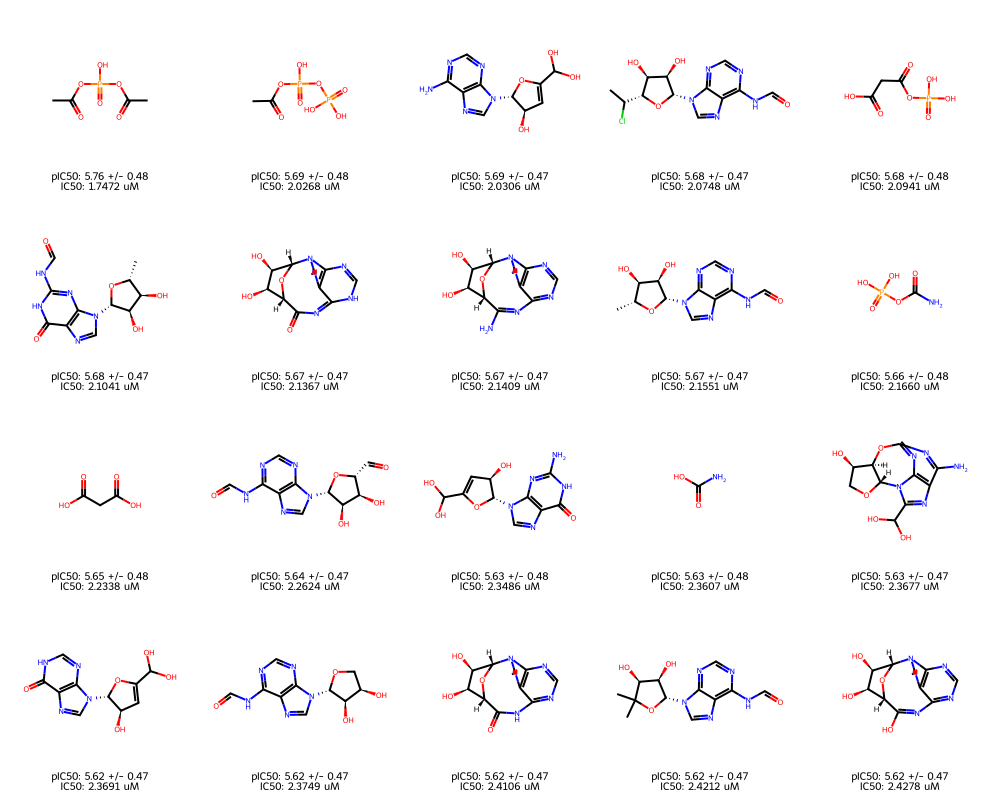

In [51]:
top20 = combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.head(50)

molecules = [Chem.MolFromSmiles(s) for s in top20["Canonical_SMILES"]]

legends = []
for _, row in top20.iterrows():
    std = row.get("pPotency_std", np.nan)
    if pd.notna(std):
        legends.append(f"pIC50: {row['pPotency_prediction']:.2f} +/- {std:.2f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legends.append(f"pIC50: {row['pPotency_prediction']:.2f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} M")

output_png = os.path.join(resultsDir, "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png")
img_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                                legends=legends, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(img_obj.data if hasattr(img_obj, "data") else img_obj)

output_svg = os.path.join(resultsDir, "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg")
svg_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                               legends=legends, useSVG=True)
svg_data = svg_obj.data if hasattr(svg_obj, "data") else svg_obj
with open(output_svg, "w") as f:
    f.write(svg_data)

print("Saved:", output_png)
print("Saved:", output_svg)
display(img_obj)

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [52]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = combinedEbola_allDORAnetGenerated_Antivirals[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = (
    combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.to_csv(os.path.join(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv"), index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20

,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.7580,0.4796,1.7472,AdenosineOnly_gen3
1,2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,5.6930,0.4789,2.0268,GuanosineOnly_gen3
2,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.6920,0.4733,2.0306,AdenosineOnly_gen3
3,4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.6830,0.4711,2.0748,AdenosineOnly_gen3
4,5,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,5.6790,0.4760,2.0941,GuanosineOnly_gen3
5,6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,5.6770,0.4714,2.1041,GuanosineOnly_gen3
6,7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,5.6700,0.4720,2.1367,InosineOnly_gen3
7,8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.6690,0.4704,2.1409,AdenosineOnly_gen3
8,9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,5.6670,0.4701,2.1551,AdenosineOnly_gen3
9,10,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,5.6640,0.4789,2.1660,AdenosineOnly_gen3


### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [84]:
combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET = pd.read_csv(resultsDir + '/ART/ART_MACAW/ADMET_AI/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction_wADMET.csv')
combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET

,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,AdenosineOnly_gen3,5.7577,0.4796,4.8177,6.6976,0.0000,0.0000,0.0000,...,47.3814,5.6942,20.8436,11.6696,75.8172,95.3603,22.8471,20.8787,94.1652,8.8928
1,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,GuanosineOnly_gen3,5.6932,0.4789,4.7545,6.6319,0.0000,0.0000,0.0000,...,13.0404,6.2214,28.9279,69.2091,24.3234,64.2882,18.6995,31.9508,89.1037,35.0439
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,AdenosineOnly_gen3,5.6924,0.4733,4.7648,6.6199,0.0000,0.0000,0.0000,...,10.1933,13.9192,27.8032,29.5958,10.2988,34.9033,21.3357,21.6169,76.0281,65.2724
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,AdenosineOnly_gen3,5.6830,0.4711,4.7597,6.6063,0.0000,0.0000,0.0000,...,21.8981,23.7258,27.7680,46.9947,17.6098,56.8717,34.6573,27.9086,65.8348,69.0685
4,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,GuanosineOnly_gen3,5.6790,0.4760,4.7460,6.6120,0.0000,0.0000,0.0000,...,13.8489,4.9561,11.6696,67.5220,23.3392,35.2900,5.7645,21.0545,93.3919,51.0369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15316,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@]1(n2cnc3c(N)ncnc32)O[C@H](CO)[C@@H](O)[C@...,AdenosineOnly_gen3,5.0531,0.4801,4.1122,5.9941,0.0000,0.0000,0.0001,...,17.0123,28.9631,28.1195,40.8436,14.7276,37.7504,24.0070,16.3093,79.0158,78.3831
15317,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,N#C[C@]1(n2cnc3c(=O)[nH]c(=O)[nH]c32)O[C@H](CO...,XanthosineOnly_gen3,5.0492,0.4771,4.1141,5.9844,0.0000,0.0000,0.0001,...,10.6503,8.2601,22.4605,30.9666,7.6274,41.3357,16.1687,29.2794,56.3796,33.9895
15318,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,N#C[C@]1(n2cnc3c(=O)[nH]c(N)nc32)O[C@H](CO)[C@...,GuanosineOnly_gen3,4.9951,0.4771,4.0600,5.9302,0.0000,0.0000,0.0001,...,10.6151,10.8612,31.0018,21.8629,8.2953,56.2390,20.0703,23.9016,60.1406,39.6134
15319,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,N#C[C@]1(n2cnc3c(=O)[nH]cnc32)O[C@H](CO)[C@@H]...,InosineOnly_gen3,4.9450,0.4772,4.0097,5.8803,0.0000,0.0000,0.0001,...,15.8172,15.3954,24.3585,30.0879,12.1265,46.5378,20.6678,19.6134,73.1810,43.7258


### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [85]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.columns
]

combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET = combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.shape)
combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.to_csv(resultsDir + "combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.csv", index=False)
combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET.head()

Filtered dataframe shape: (15321, 42)


,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,CC(=O)OP(=O)(O)OC(C)=O,AdenosineOnly_gen3,5.7577,0.4796,4.8177,6.6976,0.0000,0.0000,0.0000,0.0608,...,0.2428,0.8252,0.0046,0.0152,0.2440,0.0047,0.0439,0.0174,0.1181,0.0001
1,CC(=O)OP(=O)(O)OP(=O)(O)O,GuanosineOnly_gen3,5.6932,0.4789,4.7545,6.6319,0.0000,0.0000,0.0000,0.0155,...,0.0106,0.2858,0.0030,0.0584,0.0581,0.0242,0.0056,0.0845,0.0433,0.0004
2,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,AdenosineOnly_gen3,5.6924,0.4733,4.7648,6.6199,0.0000,0.0000,0.0000,0.7251,...,0.0273,0.5630,0.0034,0.0050,0.0279,0.0039,0.0077,0.0066,0.1355,0.0024
3,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,AdenosineOnly_gen3,5.6830,0.4711,4.7597,6.6063,0.0000,0.0000,0.0000,0.9241,...,0.1124,0.7696,0.0062,0.0076,0.0509,0.0046,0.0091,0.0067,0.2666,0.0024
4,O=C(O)CC(=O)OP(=O)(O)O,GuanosineOnly_gen3,5.6790,0.4760,4.7460,6.6120,0.0000,0.0000,0.0000,0.0177,...,0.0036,0.3271,0.0013,0.0262,0.0499,0.0157,0.0014,0.0111,0.0266,0.0001


## 4.3.2 Predict potency of DORAnet generated Antivirals from `Remdesivir` using ART

### Import all compounds generated by `DORAnet` from `Remdesivir` only (gen=2) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Remdesivir` only (gen=2) --> Possible `Antivirals`
- *with substructure match*

In [66]:
RemdesivirOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Remdesivir_Pubchem/RemdesivirOnly_gen2/RemdesivirOnly_gen2_generated_compounds.csv", dtype=str)
print(f"Loaded {len(RemdesivirOnly_DORAnetGenerated)} molecules")
RemdesivirOnly_DORAnetGenerated['source_DataBase'] = 'RemdesivirOnly_gen2'
RemdesivirOnly_DORAnetGenerated = RemdesivirOnly_DORAnetGenerated.drop(['DerivativeSimScore', 'NonDerivativeSimScore'], axis=1)
RemdesivirOnly_DORAnetGenerated

Loaded 618 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,source_DataBase
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(...,2,RemdesivirOnly_gen2
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N(P(=O)(O)O)[P@@](=O)(Oc...,2,RemdesivirOnly_gen2
2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)C(C)C(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1c...,2,RemdesivirOnly_gen2
3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1cccc(CC=C(...,2,RemdesivirOnly_gen2
4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccc(CC=C(C...,2,RemdesivirOnly_gen2
...,...,...,...,...
613,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,COC(=O)O,2,RemdesivirOnly_gen2
614,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCCO,2,RemdesivirOnly_gen2
615,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCCC,2,RemdesivirOnly_gen2
616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCC=O,2,RemdesivirOnly_gen2


### Import all compounds generated by `DORAnet` from `Remdesivir` only (gen=2) + `DORA-XGB` --> Possible `Antivirals`

### Remove common `SMILES` presents in training data (if any)

In [67]:
# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    RemdesivirOnly_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(RemdesivirOnly_DORAnetGenerated)
RemdesivirOnly_DORAnetGenerated = RemdesivirOnly_DORAnetGenerated[
    ~RemdesivirOnly_DORAnetGenerated["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(RemdesivirOnly_DORAnetGenerated)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(RemdesivirOnly_DORAnetGenerated)}")

RemdesivirOnly_DORAnetGenerated

Number of canonical SMILES common to training & external: 1
Training set molecules found and removed (unique canonical overlap): 1
Total buyable antiviral molecules for external validation after removing training set molecules: 617


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,source_DataBase
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(...,2,RemdesivirOnly_gen2
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N(P(=O)(O)O)[P@@](=O)(Oc...,2,RemdesivirOnly_gen2
2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)C(C)C(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1c...,2,RemdesivirOnly_gen2
3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1cccc(CC=C(...,2,RemdesivirOnly_gen2
4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccc(CC=C(C...,2,RemdesivirOnly_gen2
...,...,...,...,...
612,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,COC(=O)O,2,RemdesivirOnly_gen2
613,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCCO,2,RemdesivirOnly_gen2
614,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCCC,2,RemdesivirOnly_gen2
615,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCC=O,2,RemdesivirOnly_gen2


### Generate `MACAW` embeedings for molecules --> run external validation with `ART`

In [68]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(RemdesivirOnly_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=RemdesivirOnly_DORAnetGenerated.index)

RemdesivirOnly_DORAnetGenerated_wMACAW = pd.concat([RemdesivirOnly_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {RemdesivirOnly_DORAnetGenerated.shape}")
print(f"New dataframe shape: {RemdesivirOnly_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
RemdesivirOnly_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "RemdesivirOnly_DORAnetGenerated_wMACAW.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_wMACAW

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (617, 60)

Original dataframe shape: (617, 4)
New dataframe shape: (617, 64)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW

,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(...,2,RemdesivirOnly_gen2,-0.0189,-0.0498,-0.1455,0.0215,0.0549,-0.0423,...,0.0334,-0.0075,-0.0040,-0.0108,0.0341,-0.0026,0.0002,0.0031,0.0215,-0.0154
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N(P(=O)(O)O)[P@@](=O)(Oc...,2,RemdesivirOnly_gen2,-0.0305,-0.0157,-0.1313,0.0214,0.0428,-0.0439,...,0.0305,-0.0145,-0.0212,-0.0161,0.0228,0.0214,0.0251,-0.0098,0.0253,-0.0283
2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)C(C)C(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1c...,2,RemdesivirOnly_gen2,-0.0193,-0.0536,-0.1521,0.0082,0.0447,-0.0631,...,0.0327,-0.0150,-0.0107,0.0146,0.0251,-0.0028,0.0187,0.0033,0.0213,-0.0041
3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1cccc(CC=C(...,2,RemdesivirOnly_gen2,-0.0037,-0.0691,-0.1232,0.0046,0.0390,-0.0296,...,0.0338,0.0213,0.0058,0.0022,0.0370,-0.0060,0.0277,0.0117,0.0138,-0.0173
4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccc(CC=C(C...,2,RemdesivirOnly_gen2,0.0028,-0.0524,-0.1086,-0.0007,0.0514,-0.0273,...,0.0282,0.0125,0.0012,0.0230,0.0132,0.0063,0.0061,0.0004,0.0013,0.0121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,COC(=O)O,2,RemdesivirOnly_gen2,-0.1010,0.0944,-0.1147,0.0476,-0.0573,0.0319,...,0.0102,-0.0161,0.0079,0.0123,0.0061,0.0418,-0.0029,0.0176,0.0228,0.0027
613,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCCO,2,RemdesivirOnly_gen2,-0.1033,0.1065,-0.1155,0.0477,-0.0492,0.0182,...,0.0039,-0.0235,0.0006,0.0085,0.0113,0.0341,-0.0006,0.0255,0.0114,0.0060
614,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCCC,2,RemdesivirOnly_gen2,-0.1087,0.1046,-0.1108,0.0429,-0.0405,0.0215,...,0.0059,-0.0278,-0.0056,0.0096,0.0181,0.0298,-0.0056,0.0206,0.0044,0.0068
615,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCC=O,2,RemdesivirOnly_gen2,-0.0967,0.1009,-0.1113,0.0496,-0.0489,0.0208,...,0.0020,-0.0184,0.0084,0.0094,-0.0074,0.0459,-0.0021,0.0113,0.0136,0.0091


In [69]:
macawFeatureCols = [col for col in RemdesivirOnly_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = RemdesivirOnly_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [73]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
RemdesivirOnly_DORAnetGenerated_ARTprediction = RemdesivirOnly_DORAnetGenerated_wMACAW[['starter_Canonical_SMILES', 'Canonical_SMILES', 'source_DataBase']].copy()

RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
RemdesivirOnly_DORAnetGenerated_ARTprediction = RemdesivirOnly_DORAnetGenerated_ARTprediction.filter(
    items=["starter_Canonical_SMILES", "Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

RemdesivirOnly_DORAnetGenerated_ARTprediction = (
    RemdesivirOnly_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

RemdesivirOnly_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = RemdesivirOnly_DORAnetGenerated_ARTprediction.loc[RemdesivirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = RemdesivirOnly_DORAnetGenerated_ARTprediction.loc[RemdesivirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.2f} ± {min_std:.2f} - {max_pred:.2f} ± {max_std:.2f}")

RemdesivirOnly_DORAnetGenerated_ARTprediction

Predicted potency range: 5.01 ± 0.48 - 5.77 ± 0.47


,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)CC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(=...,RemdesivirOnly_gen2,5.7670,0.4739,4.8381,6.6959,0.0000,0.0000,0.0000
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,O=C(O)c1ccccc1,RemdesivirOnly_gen2,5.7487,0.4750,4.8177,6.6797,0.0000,0.0000,0.0000
2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccccc1,RemdesivirOnly_gen2,5.7470,0.4748,4.8164,6.6776,0.0000,0.0000,0.0000
3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CC(C)=CCc1ccccc1O,RemdesivirOnly_gen2,5.7233,0.4713,4.7994,6.6471,0.0000,0.0000,0.0000
4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCN[P@@](=O)(Oc1cccc(C(=O)OCC(CC)CC)c1)OP(=O)(O)O,RemdesivirOnly_gen2,5.7187,0.4771,4.7836,6.6539,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...
612,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,N#C[C@@]12O[C@H](CO)[C@@H](O)[C@H]1Oc1cc3c(N)n...,RemdesivirOnly_gen2,5.0565,0.4754,4.1247,5.9882,0.0000,0.0000,0.0001
613,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,N#C[C@]12O[C@H](CO)[C@@H](Oc3cc4c(N)ncnn4c31)[...,RemdesivirOnly_gen2,5.0347,0.4773,4.0992,5.9702,0.0000,0.0000,0.0001
614,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)O[C@H]1O[C@H](CO)[C@@H](O)[C@H](...,RemdesivirOnly_gen2,5.0345,0.4786,4.0965,5.9725,0.0000,0.0000,0.0001
615,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@]2(CO)O[C@H]2[C...,RemdesivirOnly_gen2,5.0214,0.4770,4.0865,5.9562,0.0000,0.0000,0.0001


### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency`

In [75]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

RemdesivirOnly_DORAnetGenerated_wARTprediction_top20 = RemdesivirOnly_DORAnetGenerated_ARTprediction.iloc[top_20_idx].copy()
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.2f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.2f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.2f}–{p_max:.2f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

RemdesivirOnly_DORAnetGenerated_wARTprediction_top20 = RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.filter(
    items=["Rank", "starter_Canonical_SMILES", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.to_csv(os.path.join(resultsDir + "RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "RemdesivirOnly_DORAnetGenerated_wARTprediction_top20_SMILESonly.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20

Top 20 Compounds with Highest Predicted pPotency:

Cutoff (20th): pPotency=5.67 | IC50=2.1159 µM
Best   (1st):  pPotency=5.77 | IC50=1.7099 µM

Top20 ranges: pPotency 5.67–5.77 | IC50 2.1159–1.7099 µM


,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
0,1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)CC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(=...,5.7670,0.4739,1.7099
1,2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,O=C(O)c1ccccc1,5.7490,0.4750,1.7836
2,3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccccc1,5.7470,0.4748,1.7907
3,4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CC(C)=CCc1ccccc1O,5.7230,0.4713,1.8912
4,5,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCN[P@@](=O)(Oc1cccc(C(=O)OCC(CC)CC)c1)OP(=O)(O)O,5.7190,0.4771,1.9111
5,6,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)O[C@H](C)N[P@@](=O)(Oc1ccccc1)OP...,5.7180,0.4718,1.9158
6,7,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1cccc(O)c1,5.7170,0.4733,1.9175
7,8,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(C)(C)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)O...,5.7150,0.4738,1.9265
8,9,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccccc1O,5.7140,0.4739,1.9316
9,10,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccc(O)cc1,5.7120,0.4723,1.9421


### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [76]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = RemdesivirOnly_DORAnetGenerated[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
RemdesivirOnly_DORAnetGenerated_wARTprediction_top20 = (
    RemdesivirOnly_DORAnetGenerated_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

RemdesivirOnly_DORAnetGenerated_wARTprediction_top20

,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)CC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(=...,5.7670,0.4739,1.7099,RemdesivirOnly_gen2
1,2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,O=C(O)c1ccccc1,5.7490,0.4750,1.7836,RemdesivirOnly_gen2
2,3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccccc1,5.7470,0.4748,1.7907,RemdesivirOnly_gen2
3,4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CC(C)=CCc1ccccc1O,5.7230,0.4713,1.8912,RemdesivirOnly_gen2
4,5,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCN[P@@](=O)(Oc1cccc(C(=O)OCC(CC)CC)c1)OP(=O)(O)O,5.7190,0.4771,1.9111,RemdesivirOnly_gen2
5,6,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)O[C@H](C)N[P@@](=O)(Oc1ccccc1)OP...,5.7180,0.4718,1.9158,RemdesivirOnly_gen2
6,7,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1cccc(O)c1,5.7170,0.4733,1.9175,RemdesivirOnly_gen2
7,8,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(C)(C)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)O...,5.7150,0.4738,1.9265,RemdesivirOnly_gen2
8,9,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccccc1O,5.7140,0.4739,1.9316,RemdesivirOnly_gen2
9,10,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccc(O)cc1,5.7120,0.4723,1.9421,RemdesivirOnly_gen2


### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [86]:
RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET = pd.read_csv(resultsDir + '/ART/ART_MACAW/ADMET_AI/RemdesivirOnly_DORAnetGenerated_ARTprediction_wADMET.csv')
RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET

,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)CC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(=...,RemdesivirOnly_gen2,5.7670,0.4739,4.8381,6.6959,0.0000,0.0000,0.0000,...,19.3673,23.6907,66.6432,31.5290,39.1564,83.3392,57.4692,61.4411,74.8330,36.5554
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,O=C(O)c1ccccc1,RemdesivirOnly_gen2,5.7487,0.4750,4.8177,6.6797,0.0000,0.0000,0.0000,...,80.4569,51.5641,19.5782,3.0580,77.7153,23.2337,23.3040,39.7188,74.9033,10.5800
2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccccc1,RemdesivirOnly_gen2,5.7470,0.4748,4.8164,6.6776,0.0000,0.0000,0.0000,...,95.3603,85.6239,56.4499,12.8295,89.6661,34.5167,52.4780,24.6046,89.8067,27.5923
3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CC(C)=CCc1ccccc1O,RemdesivirOnly_gen2,5.7233,0.4713,4.7994,6.6471,0.0000,0.0000,0.0000,...,86.1511,95.6063,88.4359,17.9262,91.6344,27.6977,80.7381,54.6573,54.5518,43.5852
4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCN[P@@](=O)(Oc1cccc(C(=O)OCC(CC)CC)c1)OP(=O)(O)O,RemdesivirOnly_gen2,5.7187,0.4771,4.7836,6.6539,0.0000,0.0000,0.0000,...,21.1951,35.4657,71.0721,42.8120,40.7733,78.7698,59.1916,67.4165,73.6731,55.7118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,N#C[C@@]12O[C@H](CO)[C@@H](O)[C@H]1Oc1cc3c(N)n...,RemdesivirOnly_gen2,5.0565,0.4754,4.1247,5.9882,0.0000,0.0000,0.0001,...,24.8155,13.5325,30.5097,36.7311,19.5079,85.5185,36.0281,31.5290,57.9262,39.8594
613,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,N#C[C@]12O[C@H](CO)[C@@H](Oc3cc4c(N)ncnn4c31)[...,RemdesivirOnly_gen2,5.0347,0.4773,4.0992,5.9702,0.0000,0.0000,0.0001,...,24.0773,11.3533,28.2953,39.8946,20.0000,84.9912,33.7434,29.3146,62.6362,41.3005
614,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)O[C@H]1O[C@H](CO)[C@@H](O)[C@H](...,RemdesivirOnly_gen2,5.0345,0.4786,4.0965,5.9725,0.0000,0.0000,0.0001,...,40.6678,65.6239,53.8137,39.9649,29.5958,48.2601,48.3304,34.6924,74.5518,71.9508
615,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@]2(CO)O[C@H]2[C...,RemdesivirOnly_gen2,5.0214,0.4770,4.0865,5.9562,0.0000,0.0000,0.0001,...,23.1283,12.8295,42.1441,39.6485,20.2109,93.5677,40.3163,29.4903,61.5114,36.0281


### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [87]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.columns
]

RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET = RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.shape)
RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.to_csv(resultsDir + "RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.csv", index=False)
RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.head()

Filtered dataframe shape: (617, 42)


,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,CCC(CC)CC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(=...,RemdesivirOnly_gen2,5.7670,0.4739,4.8381,6.6959,0.0000,0.0000,0.0000,0.0579,...,0.3107,0.6429,0.2345,0.4342,0.2832,0.2910,0.1191,0.4796,0.3651,0.2047
1,O=C(O)c1ccccc1,RemdesivirOnly_gen2,5.7487,0.4750,4.8177,6.6797,0.0000,0.0000,0.0000,0.0276,...,0.3095,0.8870,0.0196,0.0136,0.2901,0.0113,0.0410,0.0074,0.1098,0.0002
2,Oc1ccccc1,RemdesivirOnly_gen2,5.7470,0.4748,4.8164,6.6776,0.0000,0.0000,0.0000,0.0565,...,0.8405,0.8832,0.2845,0.0820,0.1618,0.0195,0.0758,0.0396,0.1619,0.0016
3,CC(C)=CCc1ccccc1O,RemdesivirOnly_gen2,5.7233,0.4713,4.7994,6.6471,0.0000,0.0000,0.0000,0.0694,...,0.9264,0.8100,0.7165,0.4783,0.1815,0.1727,0.2395,0.4449,0.4211,0.0303
4,CCN[P@@](=O)(Oc1cccc(C(=O)OCC(CC)CC)c1)OP(=O)(O)O,RemdesivirOnly_gen2,5.7187,0.4771,4.7836,6.6539,0.0000,0.0000,0.0000,0.0238,...,0.3805,0.7360,0.3876,0.4767,0.3481,0.3726,0.1308,0.4160,0.3642,0.1111


## 4.3.3 Predict potency of DORAnet generated Antivirals from `Brincidofovir` using ART

### Import all compounds generated by `DORAnet` from `Brincidofovir` only (gen=2) --> Possible `Antivirals`

### Import all compounds generated by `DORAnet` from `Brincidofovir` only (gen=2) --> Possible `Antivirals`
- *with substructure match*

In [77]:
BrincidofovirOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Brincidofovir_Pubchem/BrincidofovirOnly_gen2/BrincidofovirOnly_gen2_generated_compounds.csv", dtype=str)
print(f"Loaded {len(BrincidofovirOnly_DORAnetGenerated)} molecules")
BrincidofovirOnly_DORAnetGenerated['source_DataBase'] = 'BrincidofovirOnly_gen2'
BrincidofovirOnly_DORAnetGenerated = BrincidofovirOnly_DORAnetGenerated.drop(['DerivativeSimScore', 'NonDerivativeSimScore'], axis=1)
BrincidofovirOnly_DORAnetGenerated

Loaded 2932 molecules


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,source_DataBase
0,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCC[C@](CO)(Cn1ccc(N)nc1=O)OCP(=O)(O)OP...,2,BrincidofovirOnly_gen2
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC(O[C@H](CO)Cn1ccc(N)nc1=O)P(=O)(O)O...,2,BrincidofovirOnly_gen2
2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC(O)[C@H](Cn1ccc(N)nc1=O)OCP(=O)(O)O...,2,BrincidofovirOnly_gen2
3,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC([C@@H](CO)OCP(=O)(O)OP(=O)(O)O)n1c...,2,BrincidofovirOnly_gen2
4,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCc1cn(C[C@@H](CO)OCP(=O)(O)OP(=O)(O)O...,2,BrincidofovirOnly_gen2
...,...,...,...,...
2927,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCC,2,BrincidofovirOnly_gen2
2928,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCC=O,2,BrincidofovirOnly_gen2
2929,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCO,2,BrincidofovirOnly_gen2
2930,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,O=CO,2,BrincidofovirOnly_gen2


### Remove common `SMILES` presents in training data (if any)

In [78]:
# Training canonical SMILES set
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    BrincidofovirOnly_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(BrincidofovirOnly_DORAnetGenerated)
BrincidofovirOnly_DORAnetGenerated = BrincidofovirOnly_DORAnetGenerated[
    ~BrincidofovirOnly_DORAnetGenerated["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(BrincidofovirOnly_DORAnetGenerated)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(BrincidofovirOnly_DORAnetGenerated)}")

BrincidofovirOnly_DORAnetGenerated

Number of canonical SMILES common to training & external: 0
Training set molecules found and removed (unique canonical overlap): 0
Total buyable antiviral molecules for external validation after removing training set molecules: 2932


,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,source_DataBase
0,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCC[C@](CO)(Cn1ccc(N)nc1=O)OCP(=O)(O)OP...,2,BrincidofovirOnly_gen2
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC(O[C@H](CO)Cn1ccc(N)nc1=O)P(=O)(O)O...,2,BrincidofovirOnly_gen2
2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC(O)[C@H](Cn1ccc(N)nc1=O)OCP(=O)(O)O...,2,BrincidofovirOnly_gen2
3,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC([C@@H](CO)OCP(=O)(O)OP(=O)(O)O)n1c...,2,BrincidofovirOnly_gen2
4,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCc1cn(C[C@@H](CO)OCP(=O)(O)OP(=O)(O)O...,2,BrincidofovirOnly_gen2
...,...,...,...,...
2927,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCC,2,BrincidofovirOnly_gen2
2928,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCC=O,2,BrincidofovirOnly_gen2
2929,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCO,2,BrincidofovirOnly_gen2
2930,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,O=CO,2,BrincidofovirOnly_gen2


### Generate `MACAW` embeedings for molecules --> run external validation with `ART`

In [79]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BrincidofovirOnly_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BrincidofovirOnly_DORAnetGenerated.index)

BrincidofovirOnly_DORAnetGenerated_wMACAW = pd.concat([BrincidofovirOnly_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BrincidofovirOnly_DORAnetGenerated.shape}")
print(f"New dataframe shape: {BrincidofovirOnly_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BrincidofovirOnly_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "BrincidofovirOnly_DORAnetGenerated_wMACAW.csv"), index=False)
BrincidofovirOnly_DORAnetGenerated_wMACAW

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (2932, 60)

Original dataframe shape: (2932, 4)
New dataframe shape: (2932, 64)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MA

,starter_Canonical_SMILES,Canonical_SMILES,generationSteps,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCC[C@](CO)(Cn1ccc(N)nc1=O)OCP(=O)(O)OP...,2,BrincidofovirOnly_gen2,0.0737,0.0527,-0.0905,0.0306,-0.0170,0.0099,...,0.0209,0.0040,-0.0024,0.0075,0.0237,0.0093,-0.0000,-0.0560,-0.0184,-0.0419
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC(O[C@H](CO)Cn1ccc(N)nc1=O)P(=O)(O)O...,2,BrincidofovirOnly_gen2,0.0700,0.0292,-0.1070,0.0409,-0.0035,-0.0307,...,0.0438,0.0214,-0.0022,0.0138,0.0334,-0.0157,-0.0153,-0.0604,-0.0314,-0.0211
2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC(O)[C@H](Cn1ccc(N)nc1=O)OCP(=O)(O)O...,2,BrincidofovirOnly_gen2,0.0659,0.0232,-0.1222,0.0402,-0.0021,-0.0233,...,0.0570,0.0148,-0.0095,0.0079,0.0314,-0.0123,-0.0110,-0.0670,-0.0328,-0.0431
3,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCC([C@@H](CO)OCP(=O)(O)OP(=O)(O)O)n1c...,2,BrincidofovirOnly_gen2,0.0582,0.0261,-0.1204,0.0331,0.0021,-0.0229,...,0.0413,0.0061,-0.0176,0.0190,0.0292,0.0025,-0.0055,-0.0661,-0.0347,-0.0434
4,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCc1cn(C[C@@H](CO)OCP(=O)(O)OP(=O)(O)O...,2,BrincidofovirOnly_gen2,0.0619,0.0395,-0.0924,0.0283,-0.0069,0.0166,...,0.0143,0.0053,0.0054,0.0056,0.0339,0.0120,-0.0097,-0.0592,-0.0528,-0.0210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2927,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCC,2,BrincidofovirOnly_gen2,-0.1021,0.0953,-0.1100,0.0517,-0.0474,0.0238,...,0.0081,-0.0322,0.0019,0.0140,0.0090,0.0316,-0.0060,0.0118,0.0101,0.0024
2928,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCC=O,2,BrincidofovirOnly_gen2,-0.0922,0.0958,-0.1087,0.0538,-0.0527,0.0269,...,0.0066,-0.0233,0.0123,0.0112,-0.0060,0.0501,-0.0061,0.0076,0.0164,0.0012
2929,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCO,2,BrincidofovirOnly_gen2,-0.0956,0.0890,-0.1108,0.0592,-0.0556,0.0248,...,0.0046,-0.0175,0.0033,0.0165,0.0067,0.0382,-0.0058,0.0105,0.0175,0.0013
2930,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,O=CO,2,BrincidofovirOnly_gen2,-0.0947,0.0876,-0.1104,0.0552,-0.0572,0.0256,...,0.0043,-0.0151,0.0052,0.0206,0.0082,0.0370,-0.0072,0.0136,0.0185,0.0040


In [80]:
macawFeatureCols = [col for col in BrincidofovirOnly_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BrincidofovirOnly_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [81]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
BrincidofovirOnly_DORAnetGenerated_ARTprediction = BrincidofovirOnly_DORAnetGenerated_wMACAW[['starter_Canonical_SMILES', 'Canonical_SMILES', 'source_DataBase']].copy()

BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
BrincidofovirOnly_DORAnetGenerated_ARTprediction = BrincidofovirOnly_DORAnetGenerated_ARTprediction.filter(
    items=["starter_Canonical_SMILES", "Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

BrincidofovirOnly_DORAnetGenerated_ARTprediction = (
    BrincidofovirOnly_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

BrincidofovirOnly_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/BrincidofovirOnly_DORAnetGenerated_ARTprediction.csv"), index=False)
BrincidofovirOnly_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/BrincidofovirOnly_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = BrincidofovirOnly_DORAnetGenerated_ARTprediction.loc[BrincidofovirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = BrincidofovirOnly_DORAnetGenerated_ARTprediction.loc[BrincidofovirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.2f} ± {min_std:.2f} - {max_pred:.2f} ± {max_std:.2f}")

BrincidofovirOnly_DORAnetGenerated_ARTprediction

Predicted potency range: 4.75 ± 0.48 - 5.67 ± 0.47


,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C(O)[C@H](O)CO)c(=O)n1,BrincidofovirOnly_gen2,5.6728,0.4720,4.7478,6.5979,0.0000,0.0000,0.0000
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC[C@](O)(CO)Cn1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6681,0.4745,4.7380,6.5981,0.0000,0.0000,0.0000
2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC(O)[C@@H](O)Cn1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6255,0.4724,4.6996,6.5513,0.0000,0.0000,0.0000
3,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C[C@H](O)C(O)O)c(=O)n1,BrincidofovirOnly_gen2,5.6123,0.4716,4.6880,6.5367,0.0000,0.0000,0.0000
4,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC([C@H](O)CO)n1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6081,0.4731,4.6810,6.5353,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...
2927,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCOCCC=O,BrincidofovirOnly_gen2,4.8230,0.4820,3.8783,5.7676,0.0000,0.0000,0.0001
2928,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCCCOCCC=O,BrincidofovirOnly_gen2,4.7855,0.4825,3.8398,5.7312,0.0000,0.0000,0.0001
2929,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCOCCCO,BrincidofovirOnly_gen2,4.7757,0.4839,3.8272,5.7241,0.0000,0.0000,0.0001
2930,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCOCCCO,BrincidofovirOnly_gen2,4.7550,0.4842,3.8060,5.7039,0.0000,0.0000,0.0002


### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency`

In [82]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20 = BrincidofovirOnly_DORAnetGenerated_ARTprediction.iloc[top_20_idx].copy()
BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.2f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.2f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.2f}–{p_max:.2f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20 = BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20.filter(
    items=["Rank", "starter_Canonical_SMILES", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20.to_csv(os.path.join(resultsDir + "BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20.csv"), index=False)
BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20_SMILESonly.csv"), index=False)
BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20

Top 20 Compounds with Highest Predicted pPotency:

Cutoff (20th): pPotency=5.57 | IC50=2.6810 µM
Best   (1st):  pPotency=5.67 | IC50=2.1240 µM

Top20 ranges: pPotency 5.57–5.67 | IC50 2.6810–2.1240 µM


,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
0,1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C(O)[C@H](O)CO)c(=O)n1,5.6730,0.4720,2.1240
1,2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC[C@](O)(CO)Cn1ccc(N)nc1=O,5.6680,0.4745,2.1475
2,3,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC(O)[C@@H](O)Cn1ccc(N)nc1=O,5.6250,0.4724,2.3688
3,4,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C[C@H](O)C(O)O)c(=O)n1,5.6120,0.4716,2.4415
4,5,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC([C@H](O)CO)n1ccc(N)nc1=O,5.6080,0.4731,2.4652
5,6,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCOCCCOP(=O)(O)COCCn1c(CO)cc(N)nc1=O,5.6000,0.4720,2.5115
6,7,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)c1cn(C)c(=O...,5.5970,0.4732,2.5266
7,8,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C(CO)[C@H](O)CO)c(=O)n1,5.5960,0.4732,2.5332
8,9,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C(C(=O)O)[C@H](O)CO)c(=O)n1,5.5920,0.4738,2.5566
9,10,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C[C@@H](CO)OCP(=O)(O)OCCCOCCCCCCCCCCO)c...,5.5920,0.4721,2.5601


### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [83]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = BrincidofovirOnly_DORAnetGenerated[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20 = (
    BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

BrincidofovirOnly_DORAnetGenerated_wARTprediction_top20

,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C(O)[C@H](O)CO)c(=O)n1,5.6730,0.4720,2.1240,BrincidofovirOnly_gen2
1,2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC[C@](O)(CO)Cn1ccc(N)nc1=O,5.6680,0.4745,2.1475,BrincidofovirOnly_gen2
2,3,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC(O)[C@@H](O)Cn1ccc(N)nc1=O,5.6250,0.4724,2.3688,BrincidofovirOnly_gen2
3,4,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C[C@H](O)C(O)O)c(=O)n1,5.6120,0.4716,2.4415,BrincidofovirOnly_gen2
4,5,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC([C@H](O)CO)n1ccc(N)nc1=O,5.6080,0.4731,2.4652,BrincidofovirOnly_gen2
5,6,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCOCCCOP(=O)(O)COCCn1c(CO)cc(N)nc1=O,5.6000,0.4720,2.5115,BrincidofovirOnly_gen2
6,7,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)c1cn(C)c(=O...,5.5970,0.4732,2.5266,BrincidofovirOnly_gen2
7,8,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C(CO)[C@H](O)CO)c(=O)n1,5.5960,0.4732,2.5332,BrincidofovirOnly_gen2
8,9,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C(C(=O)O)[C@H](O)CO)c(=O)n1,5.5920,0.4738,2.5566,BrincidofovirOnly_gen2
9,10,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C[C@@H](CO)OCP(=O)(O)OCCCOCCCCCCCCCCO)c...,5.5920,0.4721,2.5601,BrincidofovirOnly_gen2


### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [88]:
BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET = pd.read_csv(resultsDir + '/ART/ART_MACAW/ADMET_AI/BrincidofovirOnly_DORAnetGenerated_ARTprediction_wADMET.csv')
BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET

,starter_Canonical_SMILES,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C(O)[C@H](O)CO)c(=O)n1,BrincidofovirOnly_gen2,5.6728,0.4720,4.7478,6.5979,0.0000,0.0000,0.0000,...,17.5747,24.8155,7.8032,33.5677,13.7786,6.0457,13.6028,6.3620,84.2882,34.2355
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC[C@](O)(CO)Cn1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6681,0.4745,4.7380,6.5981,0.0000,0.0000,0.0000,...,38.4534,37.4341,12.0562,31.5993,27.6626,20.4921,18.3480,4.1828,87.1705,29.8067
2,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC(O)[C@@H](O)Cn1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6255,0.4724,4.6996,6.5513,0.0000,0.0000,0.0000,...,34.3058,31.6344,4.2179,30.0527,23.8664,8.0141,13.8489,3.4095,90.0879,22.8120
3,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Nc1ccn(C[C@H](O)C(O)O)c(=O)n1,BrincidofovirOnly_gen2,5.6123,0.4716,4.6880,6.5367,0.0000,0.0000,0.0000,...,14.5167,22.3902,7.8735,26.1863,12.5132,4.2882,12.1265,5.6239,86.6081,27.6977
4,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CC([C@H](O)CO)n1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6081,0.4731,4.6810,6.5353,0.0000,0.0000,0.0000,...,31.3533,26.7487,5.3076,38.6995,23.0931,16.6257,15.7821,4.0070,88.5764,34.8330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCCC(CCC=O)C(=O)O,BrincidofovirOnly_gen2,4.8792,0.4807,3.9371,5.8214,0.0000,0.0000,0.0001,...,83.6907,86.0105,68.6467,17.5747,89.8067,16.3796,66.8190,80.7733,15.2900,49.0334
1806,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,O=CCCCCCCCCCCCCCCCO,BrincidofovirOnly_gen2,4.8767,0.4823,3.9314,5.8221,0.0000,0.0000,0.0001,...,89.9473,93.2162,78.0316,67.1002,92.7944,8.7873,76.8717,67.5571,18.3480,87.2408
1807,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCCC(CCCO)C(=O)O,BrincidofovirOnly_gen2,4.8748,0.4823,3.9294,5.8201,0.0000,0.0000,0.0001,...,75.2900,86.3269,67.5571,31.3533,86.9947,13.1107,66.3269,72.6889,20.7030,68.2953
1808,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,O=C(O)CCCCCCCCCCCCCCCCO,BrincidofovirOnly_gen2,4.8725,0.4829,3.9260,5.8191,0.0000,0.0000,0.0001,...,69.7715,84.6749,59.4728,17.2583,85.2724,6.0457,56.6257,73.2865,19.5079,53.8840


### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [89]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.columns
]

BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET = BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.shape)
BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.to_csv(resultsDir + "BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.csv", index=False)
BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.head()

Filtered dataframe shape: (1810, 42)


,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1ccn(C(O)[C@H](O)CO)c(=O)n1,BrincidofovirOnly_gen2,5.6728,0.4720,4.7478,6.5979,0.0000,0.0000,0.0000,0.1190,...,0.0523,0.8034,0.0007,0.0023,0.0722,0.0011,0.0208,0.0016,0.0914,0.0004
1,CC[C@](O)(CO)Cn1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6681,0.4745,4.7380,6.5981,0.0000,0.0000,0.0000,0.2617,...,0.1593,0.8099,0.0007,0.0031,0.0893,0.0021,0.0479,0.0030,0.1716,0.0019
2,CC(O)[C@@H](O)Cn1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6255,0.4724,4.6996,6.5513,0.0000,0.0000,0.0000,0.1982,...,0.2859,0.8902,0.0039,0.0071,0.1406,0.0042,0.0534,0.0030,0.1740,0.0021
3,Nc1ccn(C[C@H](O)C(O)O)c(=O)n1,BrincidofovirOnly_gen2,5.6123,0.4716,4.6880,6.5367,0.0000,0.0000,0.0000,0.1940,...,0.0301,0.6546,0.0007,0.0032,0.0448,0.0017,0.0185,0.0036,0.0761,0.0005
4,CC([C@H](O)CO)n1ccc(N)nc1=O,BrincidofovirOnly_gen2,5.6081,0.4731,4.6810,6.5353,0.0000,0.0000,0.0000,0.1354,...,0.1693,0.8681,0.0014,0.0046,0.1435,0.0028,0.0382,0.0024,0.1594,0.0015


## `Plots` potency-toxicity panel
**All compounds generated by DORAnet**
- Inosine (DORAnet gen=3)
- Adenosine (DORAnet gen=3)
- Xanthosine (DORAnet gen=3)
- Guanosine (DORAnet gen=3)
- Remdesivir (DORAnet gen=2)
- Brincidofovir (DORAnet gen=2)

**Experimental data**
- Remdesivir
- Brincidofovir
- Favipiravir

### Split `combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET` to four individual data frames

In [90]:
# Original dataframe:
# combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET

# Mapping: source_DataBase value -> new dataframe variable name + new label
source_map = {
    "XanthosineOnly_gen3": ("combinedEbola_allXanthosineGenerated_Antivirals_wART_wADMET", "Xanthosine"),
    "AdenosineOnly_gen3":  ("combinedEbola_allAdenosineGenerated_Antivirals_wART_wADMET", "Adenosine"),
    "InosineOnly_gen3":    ("combinedEbola_allInosineGenerated_Antivirals_wART_wADMET", "Inosine"),
    "GuanosineOnly_gen3":  ("combinedEbola_allGuanosineGenerated_Antivirals_wART_wADMET", "Guanosine"),
}

# Create split dataframes dynamically
for src_value, (df_name, renamed_label) in source_map.items():
    tmp_df = combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET[
        combinedEbola_allDORAnetGenerated_Antivirals_wART_wADMET["source_DataBase"] == src_value
    ].copy()

    # Rename source_DataBase entries
    tmp_df["source_DataBase"] = renamed_label

    # Create variable in global namespace
    globals()[df_name] = tmp_df

# check
print("Created dataframes:")
for _, (df_name, _) in source_map.items():
    print(df_name, globals()[df_name].shape)

Created dataframes:
combinedEbola_allXanthosineGenerated_Antivirals_wART_wADMET (3348, 42)
combinedEbola_allAdenosineGenerated_Antivirals_wART_wADMET (3998, 42)
combinedEbola_allInosineGenerated_Antivirals_wART_wADMET (4079, 42)
combinedEbola_allGuanosineGenerated_Antivirals_wART_wADMET (3896, 42)


### Get `potency` prediction from `ART`

In [91]:
InoAdeGuoXan_SMILES_Dict = {
    "Inosine":  'C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O',
    "Adenosine": 'C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N',
    "Guanosine": 'C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N=C(NC2=O)N',
    "Xanthosine": 'C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)NC(=O)NC2=O'
}

InoAdeGuoXan_dF = pd.DataFrame(
    [{"drugName": name, "Canonical_SMILES": canonicalizeSmiles(smi)}
     for name, smi in InoAdeGuoXan_SMILES_Dict.items()])

# 1) Load MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, "rb") as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# 2) Transform SMILES to MACAW embeddings
macaw_embeddings = mcw.transform(InoAdeGuoXan_dF["Canonical_SMILES"])
print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# 3) Build embeddings dataframe and combine
embedding_columns = [f"MACAW_{i+1}" for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=InoAdeGuoXan_dF.index)

InoAdeGuoXan_wMACAW = pd.concat([InoAdeGuoXan_dF, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {InoAdeGuoXan_dF.shape}")
print(f"New dataframe shape: {InoAdeGuoXan_wMACAW.shape}")
print(f"New columns added: {list(macaw_df.columns)}")

# 4) ART prediction
macawFeatureCols = [col for col in InoAdeGuoXan_wMACAW.columns if col.startswith('MACAW_')]
smiLib = InoAdeGuoXan_wMACAW[macawFeatureCols].values
mean, std = art_macaw.post_pred_stats(smiLib)

# 5) Assemble final result table
InoAdeGuoXan_wART = InoAdeGuoXan_wMACAW[["drugName", "Canonical_SMILES"]].copy()
InoAdeGuoXan_wART["pPotency_prediction"] = mean
InoAdeGuoXan_wART["pPotency_std"] = std

# 95% confidence intervals
InoAdeGuoXan_wART["pPotency_lower_95CI"] = InoAdeGuoXan_wART["pPotency_prediction"] - 1.96 * InoAdeGuoXan_wART["pPotency_std"]
InoAdeGuoXan_wART["pPotency_upper_95CI"] = InoAdeGuoXan_wART["pPotency_prediction"] + 1.96 * InoAdeGuoXan_wART["pPotency_std"]

# Convert pPotency to IC50(M)
InoAdeGuoXan_wART["IC50(M)_prediction"] = 10 ** (-InoAdeGuoXan_wART["pPotency_prediction"])
InoAdeGuoXan_wART["IC50(M)_lower_95CI"] = 10 ** (-InoAdeGuoXan_wART["pPotency_upper_95CI"])
InoAdeGuoXan_wART["IC50(M)_upper_95CI"] = 10 ** (-InoAdeGuoXan_wART["pPotency_lower_95CI"])

# sort by predicted potency
InoAdeGuoXan_wART = (
    InoAdeGuoXan_wART.sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True))

# Final dataframe
InoAdeGuoXan_wART

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/EbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (4, 60)

Original dataframe shape: (4, 2)
New dataframe shape: (4, 62)
New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', '

,drugName,Canonical_SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,5.3297,0.4735,4.4015,6.2578,0.0000,0.0000,0.0000
1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.3100,0.4728,4.3833,6.2366,0.0000,0.0000,0.0000
2,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,5.2879,0.4744,4.3581,6.2176,0.0000,0.0000,0.0000
3,Inosine,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.2548,0.4735,4.3268,6.1828,0.0000,0.0000,0.0000


### Compute their ADMET profile

In [92]:
model = ADMETModel()
pred = model.predict(smiles=InoAdeGuoXan_wART["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
InoAdeGuoXan_wART_wADMET = InoAdeGuoXan_wART.merge(pred, on="Canonical_SMILES", how="left")
InoAdeGuoXan_wART_wADMET

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,drugName,Canonical_SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,5.3297,0.4735,4.4015,6.2578,0.0000,0.0000,0.0000,284.2280,...,10.0879,10.2636,13.0053,37.2232,6.9947,19.7540,12.7241,22.6011,62.7768,57.5044
1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.3100,0.4728,4.3833,6.2366,0.0000,0.0000,0.0000,267.2450,...,16.3796,16.8366,19.2619,41.6520,12.8647,46.9947,22.4253,14.4815,78.4886,69.2091
2,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,5.2879,0.4744,4.3581,6.2176,0.0000,0.0000,0.0000,283.2440,...,10.3339,12.0562,18.5940,28.8576,7.9086,32.8998,15.7821,16.9420,68.7522,64.1125
3,Inosine,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.2548,0.4735,4.3268,6.1828,0.0000,0.0000,0.0000,268.2290,...,15.5009,18.6292,12.6538,39.7188,11.4236,23.8313,16.5905,13.9543,80.0000,65.6591


### Read experimental `potency` data of `Remdesivir, Favipiravir, Brincidofovir`

In [93]:
ExperimentalDataDict = {
    "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Favipiravir": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

queryPotencyDict_expt = {
    "Remdesivir": [
        7.07,  # Warren et al. 2016, EBOV, primary macrophages
        6.85,  # Warren et al. 2016, EBOV, HeLa
        6.89,  # Warren et al. 2016, EBOV, HFF-1
        7.22,  # Warren et al. 2016, EBOV, HMVEC-TERT
        7.15,  # Warren et al. 2016, EBOV, Huh-7
        7.18,  # Lo et al. 2017, EBOV Mayinga-GFP reporter assay
        7.68,  # Lo et al. 2017, EBOV Mayinga-Gluc reporter assay
        7.85,  # Lo et al. 2017, EBOV Makona-ZSG reporter assay
        8.52,  # Lo et al. 2017, EBOV Makona virus titer reduction assay
        7.11,  # Radoshitzky et al. 2023, EBOV Makona, HeLa
        6.87,  # Radoshitzky et al. 2023, EBOV Mayinga, HeLa
        7.15,  # Radoshitzky et al. 2023, EBOV Kikwit, HeLa
    ],
    "Favipiravir": [4.17, 3.96],
    "Brincidofovir": [6.10, 6.18, 6.06],
}

def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True) if mol else None

queryData_expt = []
for drugName, smiles in ExperimentalDataDict.items():
    potencyValues = pd.Series(queryPotencyDict_expt[drugName], dtype="float64")
    queryData_expt.append({
        "drugName": drugName,
        "SMILES": canonicalizeSmiles(smiles),
        "pPotency_min": potencyValues.min(),
        "pPotency_max": potencyValues.max(),
        "meanpPotency": potencyValues.mean(),
        "potency_std": potencyValues.std(ddof=1),  # standard deviation
    })

ExperimentalDataDF = pd.DataFrame(queryData_expt)
ExperimentalDataDF = ExperimentalDataDF.rename (columns={'meanpPotency' :'pPotency_prediction', 'potency_std' : 'pPotency_std'})
ExperimentalDataDF = ExperimentalDataDF.drop(columns=["pPotency_min", "pPotency_max"])
ExperimentalDataDF = ExperimentalDataDF.rename(columns={'SMILES' : 'Canonical_SMILES'})
ExperimentalDataDF

,drugName,Canonical_SMILES,pPotency_prediction,pPotency_std
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,7.2950,0.4904
1,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,4.0650,0.1485
2,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,6.1133,0.0611


### Compute their ADMET profile

In [94]:
model = ADMETModel()
pred = model.predict(smiles=ExperimentalDataDF["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
ExperimentalDataDF_wADMET = ExperimentalDataDF.merge(pred, on="Canonical_SMILES", how="left")
ExperimentalDataDF_wADMET

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

,drugName,Canonical_SMILES,pPotency_prediction,pPotency_std,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,7.2950,0.4904,602.5850,2.3122,12,4,2.0000,0.1640,...,17.8559,32.5483,87.3814,56.0633,15.5360,96.7311,79.5782,70.3339,48.1898,68.6467
1,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,4.0650,0.1485,157.1040,-0.9921,3,2,4.0000,0.5479,...,72.0914,34.6573,15.3954,20.9490,51.0018,44.2882,30.4394,18.6643,76.7663,9.5255
2,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,6.1133,0.0611,561.7010,5.2505,8,3,2.0000,0.1019,...,25.4482,77.1880,84.3937,73.2513,30.4745,56.2742,77.6801,70.5800,23.5852,94.4112


In [95]:
InoAdeGuoXan_queryAntivirals_dF = pd.concat([queryAntiviralsDF_wART_wADMET, InoAdeGuoXan_wART_wADMET], ignore_index=True)
InoAdeGuoXan_queryAntivirals_dF = InoAdeGuoXan_queryAntivirals_dF.drop_duplicates(subset=["Canonical_SMILES"]).reset_index(drop=True)
InoAdeGuoXan_queryAntivirals_dF

,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir,6.6286,0.4698,5.7078,7.5493,0.0000,0.0000,0.0000,602.5850,...,17.8559,32.5483,87.3814,56.0281,15.5360,96.7311,79.5782,70.2988,48.1898,68.6467
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir,5.5033,0.4711,4.5799,6.4266,0.0000,0.0000,0.0000,561.7010,...,25.4482,77.1880,84.3585,73.2513,30.5097,56.2742,77.6801,70.6151,23.5852,94.4112
2,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,Molnupiravir,5.2446,0.4772,4.3093,6.1800,0.0000,0.0000,0.0000,329.3090,...,16.4148,45.2724,33.3216,5.1670,11.5290,10.4745,18.2425,27.8735,64.8155,42.0035
3,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir,4.9088,0.4815,3.9651,5.8525,0.0000,0.0000,0.0001,157.1040,...,72.0914,34.6573,15.3954,20.9490,51.0018,44.2882,30.4394,18.6643,76.7663,9.5255
4,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,Xanthosine,5.3297,0.4735,4.4015,6.2578,0.0000,0.0000,0.0000,284.2280,...,10.0879,10.2636,13.0053,37.2232,6.9947,19.7540,12.7241,22.6011,62.7768,57.5044
5,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Adenosine,5.3100,0.4728,4.3833,6.2366,0.0000,0.0000,0.0000,267.2450,...,16.3796,16.8366,19.2619,41.6520,12.8647,46.9947,22.4253,14.4815,78.4886,69.2091
6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,Guanosine,5.2879,0.4744,4.3581,6.2176,0.0000,0.0000,0.0000,283.2440,...,10.3339,12.0562,18.5940,28.8576,7.9086,32.8998,15.7821,16.9420,68.7522,64.1125
7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,Inosine,5.2548,0.4735,4.3268,6.1828,0.0000,0.0000,0.0000,268.2290,...,15.5009,18.6292,12.6538,39.7188,11.4236,23.8313,16.5905,13.9543,80.0000,65.6591


### Plot potency of all the compounds

- x-axis: pPotency_prediction
- y-axis: drug candidate names
- Individual predicted as larger circles
- Experimental as stars (*) with pPotency_std
- Top-20 overlays as cross marks
- thinning ONLY for Remdesivir derivatives

In [96]:
# Shared config
potencyCols = ["pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI"]
toxicityMeta = [
    ("AMES", "lowerBetter"), ("Carcinogens_Lagunin", "lowerBetter"), ("ClinTox", "lowerBetter"),
    ("DILI", "lowerBetter"), ("Skin_Reaction", "lowerBetter"), ("hERG", "lowerBetter"),
    ("LD50_Zhu", "higherBetter"), ("NR-AR-LBD", "lowerBetter"), ("NR-AR", "lowerBetter"),
    ("NR-AhR", "lowerBetter"), ("NR-Aromatase", "lowerBetter"), ("NR-ER-LBD", "lowerBetter"),
    ("NR-ER", "lowerBetter"), ("NR-PPAR-gamma", "lowerBetter"), ("SR-ARE", "lowerBetter"),
    ("SR-ATAD5", "lowerBetter"), ("SR-HSE", "lowerBetter"), ("SR-MMP", "lowerBetter"),
    ("SR-p53", "lowerBetter"),
]
toxicityCols = [x for x, _ in toxicityMeta]
keepCols = ["drugName", "SMILES"] + potencyCols + toxicityCols
toxDesCols = [f"{ep}_des" for ep, _ in toxicityMeta]



# Utilitiy functions
def prepareDF(df, datasetLabel):
    df = df.copy()
    if "Canonical_SMILES" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"Canonical_SMILES": "SMILES"})
    elif "smiles" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"smiles": "SMILES"})

    if "drugName" not in df.columns:
        df["drugName"] = df["Drug_Type"] if "Drug_Type" in df.columns else df.get("SMILES", np.nan)

    df["datasetLabel"] = datasetLabel
    return df


def ensureCols(df, colList):
    df = df.copy()
    for c in colList:
        if c not in df.columns:
            df[c] = np.nan
    return df[colList].copy()


def robustIQR(series):
    arr = pd.to_numeric(series, errors="coerce").dropna()
    if len(arr) < 5:
        return np.nan
    q25, q75 = np.percentile(arr, [25, 75])
    return q75 - q25


def getSortedRefArray(series):
    arr = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]
    return np.sort(arr)


def higherBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m = np.isfinite(valArr)
    pct = np.searchsorted(refArr, valArr[m], side="right") / len(refArr)
    out[m] = np.clip(pct, 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def lowerBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m = np.isfinite(valArr)
    pct = np.searchsorted(refArr, valArr[m], side="right") / len(refArr)
    out[m] = np.clip(1.0 - pct, 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def weightedGeoMeanSeries(df, valueCols, weightSeries):
    val = df[valueCols].to_numpy(dtype=float)
    w = np.asarray(weightSeries, dtype=float)
    out = np.full(val.shape[0], np.nan)
    for i in range(val.shape[0]):
        row = val[i]
        m = np.isfinite(row)
        if m.sum() == 0:
            continue
        rowVal = np.clip(row[m], 1e-6, 1.0)
        rowW = w[m]
        out[i] = np.exp(np.sum(rowW * np.log(rowVal)) / np.sum(rowW))
    return pd.Series(out, index=df.index)


def thinForDisplay(df, xCol, yCol, nXBins=100, nYBins=100, denseThreshold=4, keepFraction=0.20, randomState=42):
    plotDF = df[[xCol, yCol]].dropna().copy()
    if len(plotDF) == 0:
        return df.iloc[0:0].copy()

    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()
    if xMin == xMax: xMax += 1e-9
    if yMin == yMax: yMax += 1e-9

    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)
    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)

    rng = np.random.default_rng(randomState)
    kept = []
    for _, g in plotDF.groupby(["xBin", "yBin"], dropna=False):
        n = len(g)
        if n <= denseThreshold:
            kept.extend(g.index.tolist())
        else:
            nk = max(1, int(np.ceil(n * keepFraction)))
            kept.extend(rng.choice(g.index.to_numpy(), size=nk, replace=False).tolist())

    return df.loc[sorted(set(kept))].copy()


def select_top20_group(df_group):
    df2 = df_group.dropna(subset=["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]).copy()
    if len(df2) == 0:
        return df2.iloc[0:0].copy(), np.nan, np.nan

    x_cut = df2["pPotency_prediction"].quantile(0.75)
    y_cut = df2["coreToxicityScore"].quantile(0.25)

    opt = df2[(df2["pPotency_prediction"] >= x_cut) & (df2["coreToxicityScore"] <= y_cut)].copy()
    if len(opt) == 0:
        return opt, x_cut, y_cut

    opt["OverallPriority2D"] = np.sqrt(opt["PotencyDesRaw"] * opt["ToxicitySafety"])
    top20 = opt.sort_values(
        by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
        ascending=[False, False, True]
    ).head(20).copy()
    return top20, x_cut, y_cut


def build_scored_data(ref_raw, generated_raw, expt_raw):
    ref = prepareDF(ref_raw, "Reference")
    expt = prepareDF(expt_raw, "Expt")
    generated = {}
    for source_name, source_df in generated_raw.items():
        t = prepareDF(source_df, "Generated")
        t["candidateSource"] = source_name
        generated[source_name] = t

    refScoreDF = ensureCols(ref, keepCols)
    candScoreMap = {k: ensureCols(v, keepCols) for k, v in generated.items()}
    exptScoreDF = ensureCols(expt, keepCols)

    for c in potencyCols + toxicityCols:
        refScoreDF[c] = pd.to_numeric(refScoreDF[c], errors="coerce")
        for k in candScoreMap:
            candScoreMap[k][c] = pd.to_numeric(candScoreMap[k][c], errors="coerce")
        exptScoreDF[c] = pd.to_numeric(exptScoreDF[c], errors="coerce")

    refToxDF = refScoreDF[toxicityCols].apply(pd.to_numeric, errors="coerce")
    toxCorrDF = refToxDF.corr().abs()

    weightRows = []
    for endpointName, directionName in toxicityMeta:
        iqrVal = robustIQR(refToxDF[endpointName])
        informativeness = 1.0 / (iqrVal + 1e-6) if pd.notna(iqrVal) else 1.0
        others = [x for x in toxicityCols if x != endpointName]
        meanAbsCorr = toxCorrDF.loc[endpointName, others].dropna().mean() if (endpointName in toxCorrDF.index and len(others) > 0) else np.nan
        uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        weightRows.append({"endpoint": endpointName, "direction": directionName, "rawWeight": informativeness * uniqueness})

    toxWeightDF = pd.DataFrame(weightRows)
    toxWeightDF["finalWeight"] = toxWeightDF["rawWeight"] / toxWeightDF["rawWeight"].sum()

    def scoreCandidateDF(df):
        df = df.copy()
        for endpointName, directionName in toxicityMeta:
            desCol = f"{endpointName}_des"
            df[desCol] = higherBetterDes(refScoreDF[endpointName], df[endpointName]) if directionName == "higherBetter" else lowerBetterDes(refScoreDF[endpointName], df[endpointName])
        df["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], df["pPotency_prediction"])
        df["ToxicitySafety"] = weightedGeoMeanSeries(df, toxDesCols, toxWeightDF["finalWeight"])
        df["coreToxicityScore"] = 1.0 - df["ToxicitySafety"]
        return df

    scoredCandMap = {k: scoreCandidateDF(v) for k, v in candScoreMap.items()}
    exptScoreDF = scoreCandidateDF(exptScoreDF)
    return refScoreDF, scoredCandMap, exptScoreDF

### Plot `potency-toxicity-ADME` together for all the generated compounds

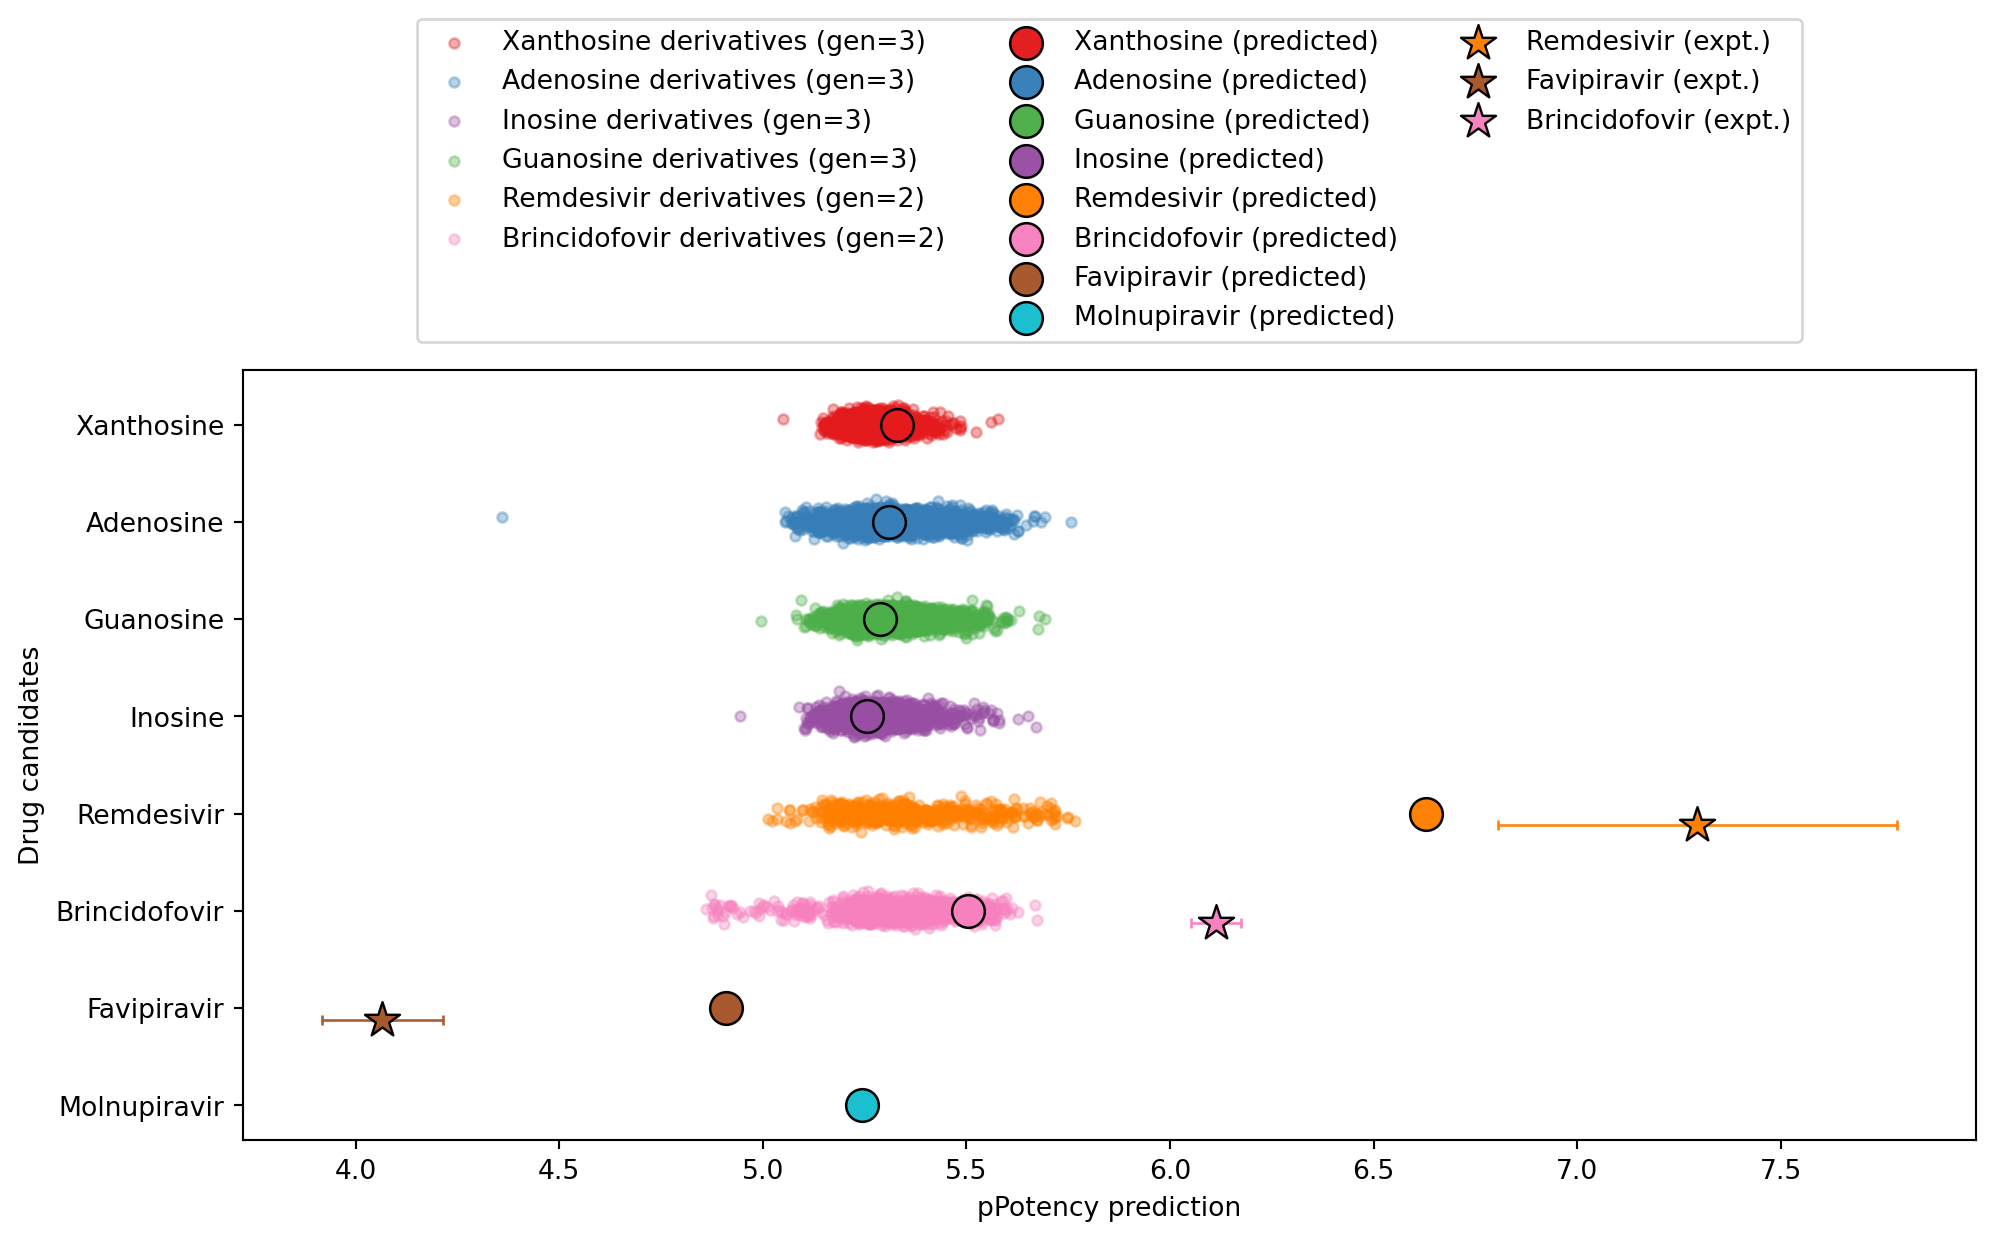

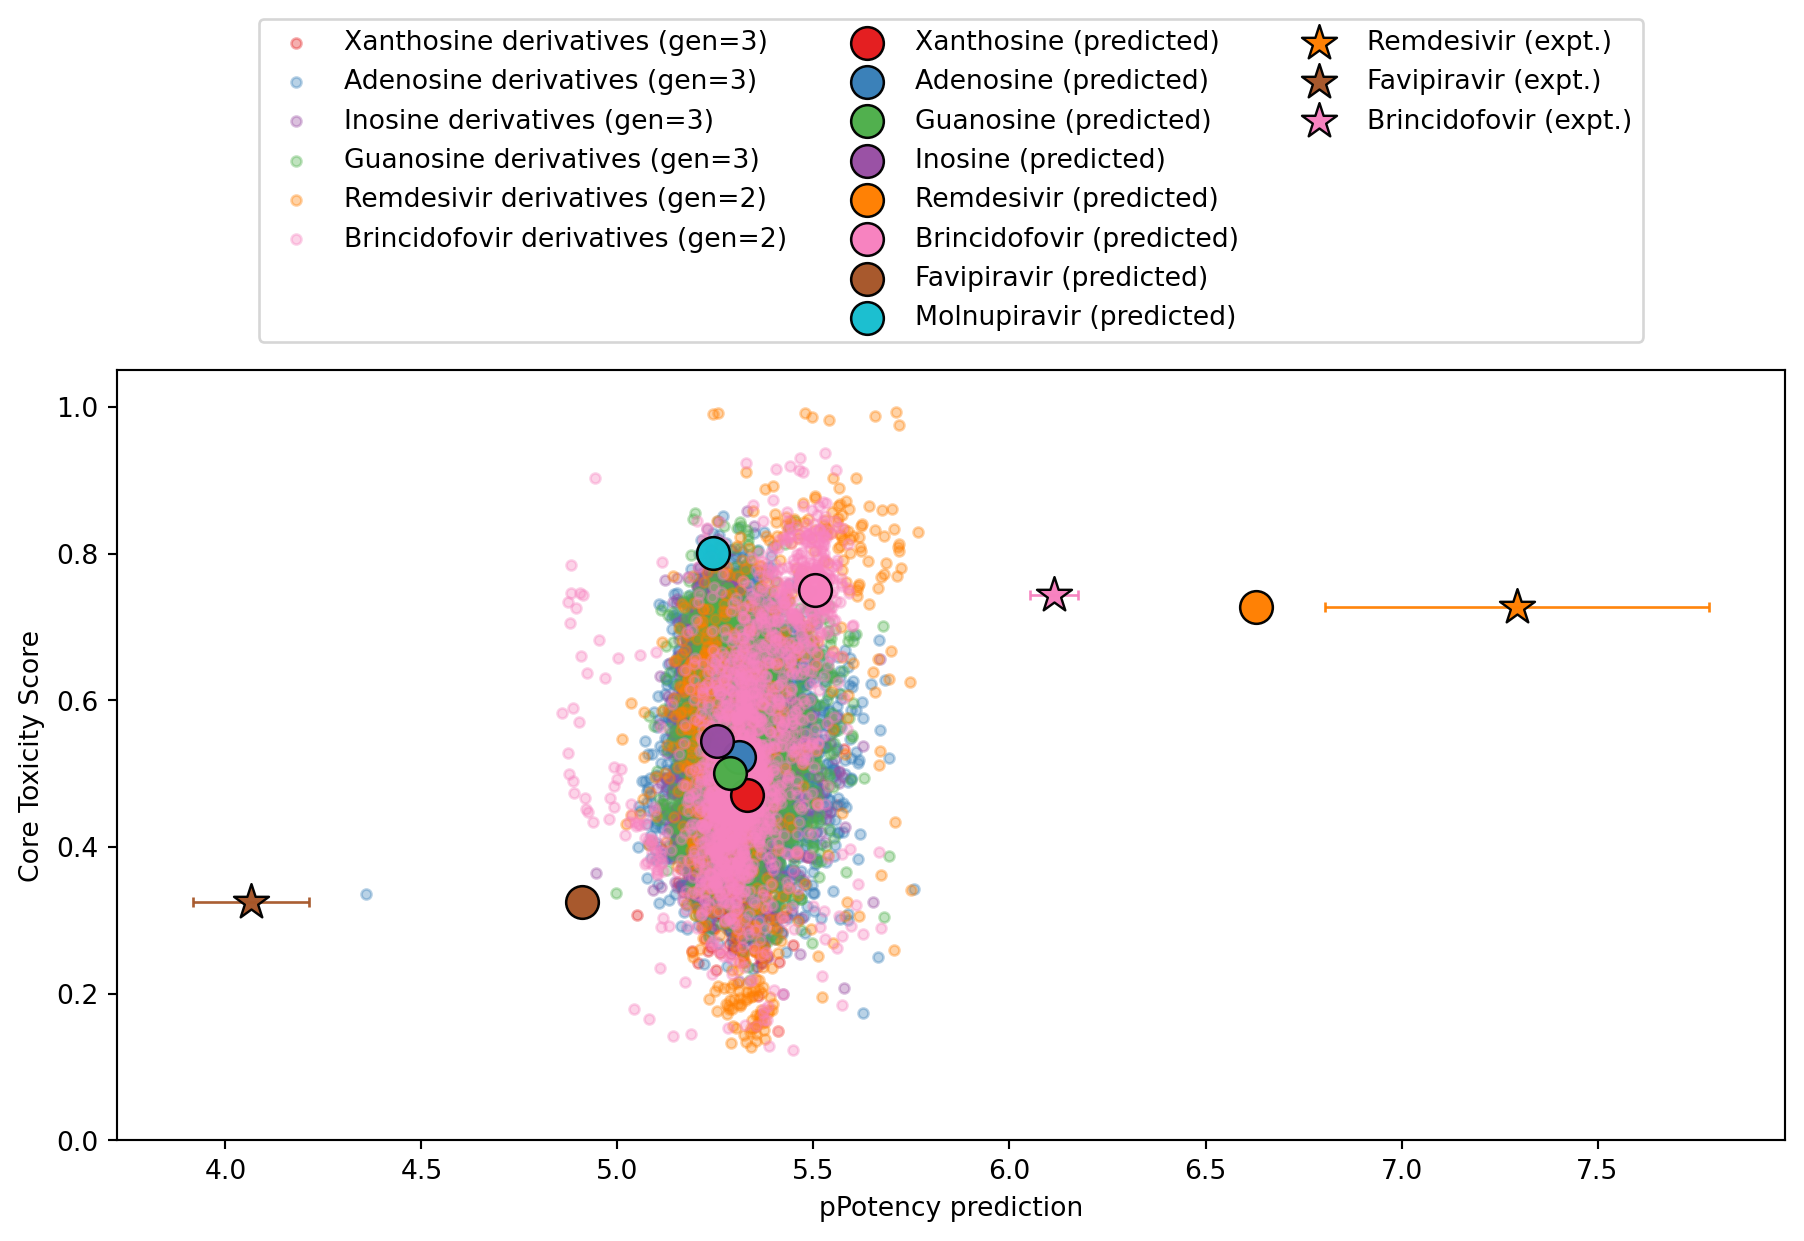

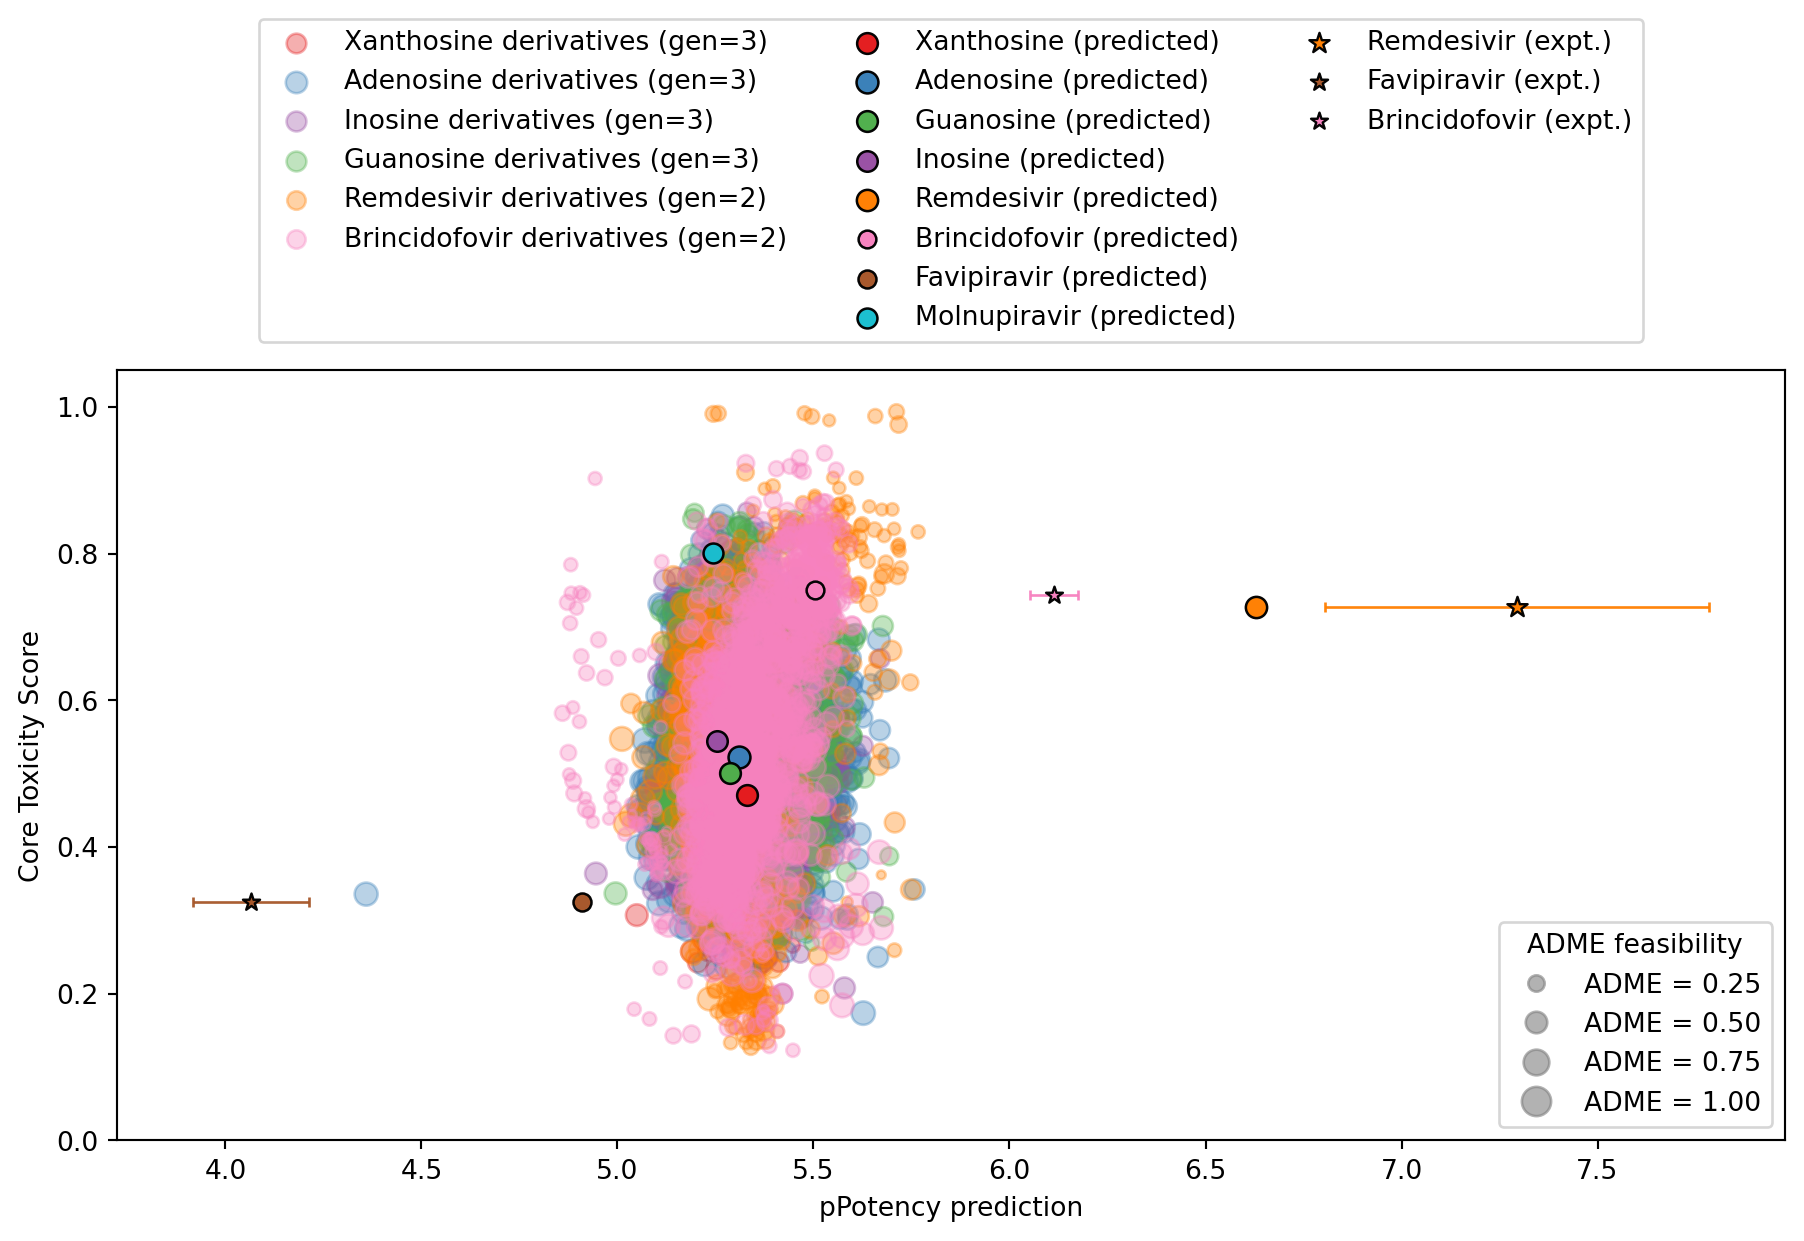

In [117]:
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
import matplotlib.lines as mlines

tnr = FontProperties(family="serif", style="normal", size=10)

plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size":        10,
    "axes.titlesize":   10,
    "axes.labelsize":   10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
})

potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

toxicityMeta = [
    ("AMES",             "lowerBetter"),  ("Carcinogens_Lagunin", "lowerBetter"),
    ("ClinTox",          "lowerBetter"),  ("DILI",                "lowerBetter"),
    ("Skin_Reaction",    "lowerBetter"),  ("hERG",                "lowerBetter"),
    ("LD50_Zhu",         "higherBetter"), ("NR-AR-LBD",           "lowerBetter"),
    ("NR-AR",            "lowerBetter"),  ("NR-AhR",              "lowerBetter"),
    ("NR-Aromatase",     "lowerBetter"),  ("NR-ER-LBD",           "lowerBetter"),
    ("NR-ER",            "lowerBetter"),  ("NR-PPAR-gamma",       "lowerBetter"),
    ("SR-ARE",           "lowerBetter"),  ("SR-ATAD5",            "lowerBetter"),
    ("SR-HSE",           "lowerBetter"),  ("SR-MMP",              "lowerBetter"),
    ("SR-p53",           "lowerBetter"),
]
toxicityCols = [x for x, _ in toxicityMeta]
toxDesCols   = [f"{ep}_des" for ep, _ in toxicityMeta]

admeMeta = [
    ("Bioavailability_Ma",             "higherBetter"),
    ("HIA_Hou",                        "higherBetter"),
    ("Caco2_Wang",                     "higherBetter"),
    ("PAMPA_NCATS",                    "higherBetter"),
    ("Pgp_Broccatelli",                "lowerBetter"),
    ("BBB_Martins",                    "lowerBetter"),
    ("CYP1A2_Veith",                   "lowerBetter"),
    ("CYP2C19_Veith",                  "lowerBetter"),
    ("CYP2C9_Veith",                   "lowerBetter"),
    ("CYP2D6_Veith",                   "lowerBetter"),
    ("CYP3A4_Veith",                   "lowerBetter"),
    ("CYP2C9_Substrate_CarbonMangels", "lowerBetter"),
    ("CYP2D6_Substrate_CarbonMangels", "lowerBetter"),
    ("CYP3A4_Substrate_CarbonMangels", "lowerBetter"),
]
admeCols    = [x for x, _ in admeMeta]
admeDesCols = [f"{ep}_des_adme" for ep, _ in admeMeta]

keepCols = ["drugName", "SMILES"] + potencyCols + toxicityCols + admeCols


def prepareDF(df, datasetLabel):
    df = df.copy()
    if "Canonical_SMILES" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"Canonical_SMILES": "SMILES"})
    elif "smiles" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"smiles": "SMILES"})
    if "drugName" not in df.columns:
        df["drugName"] = df["Drug_Type"] if "Drug_Type" in df.columns else df.get("SMILES", np.nan)
    df["datasetLabel"] = datasetLabel
    return df


def ensureCols(df, colList):
    df = df.copy()
    for c in colList:
        if c not in df.columns:
            df[c] = np.nan
    return df[colList].copy()


def robustIQR(series):
    arr = pd.to_numeric(series, errors="coerce").dropna()
    if len(arr) < 5:
        return np.nan
    q25, q75 = np.percentile(arr, [25, 75])
    return q75 - q25


def getSortedRefArray(series):
    arr = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    return np.sort(arr[np.isfinite(arr)])


def higherBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out    = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m      = np.isfinite(valArr)
    out[m] = np.clip(np.searchsorted(refArr, valArr[m], side="right") / len(refArr), 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def lowerBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out    = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m      = np.isfinite(valArr)
    out[m] = np.clip(1.0 - np.searchsorted(refArr, valArr[m], side="right") / len(refArr), 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def weightedGeoMeanSeries(df, valueCols, weightSeries):
    val = df[valueCols].to_numpy(dtype=float)
    w   = np.asarray(weightSeries, dtype=float)
    out = np.full(val.shape[0], np.nan)
    for i in range(val.shape[0]):
        row    = val[i]
        m      = np.isfinite(row)
        if m.sum() == 0:
            continue
        rowVal = np.clip(row[m], 1e-6, 1.0)
        rowW   = w[m]
        out[i] = np.exp(np.sum(rowW * np.log(rowVal)) / np.sum(rowW))
    return pd.Series(out, index=df.index)


def computeWeights(refDF, metaList, cols):
    corrDF     = refDF[cols].apply(pd.to_numeric, errors="coerce").corr().abs()
    weightRows = []
    for endpointName, directionName in metaList:
        iqrVal          = robustIQR(refDF[endpointName])
        informativeness = 1.0 / (iqrVal + 1e-6) if pd.notna(iqrVal) else 1.0
        others          = [x for x in cols if x != endpointName]
        meanAbsCorr     = corrDF.loc[endpointName, others].dropna().mean() \
                          if (endpointName in corrDF.index and len(others) > 0) else np.nan
        uniqueness      = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        weightRows.append({"endpoint": endpointName, "direction": directionName,
                           "rawWeight": informativeness * uniqueness})
    wDF               = pd.DataFrame(weightRows)
    wDF["finalWeight"] = wDF["rawWeight"] / wDF["rawWeight"].sum()
    return wDF


def build_scored_data(ref_raw, generated_raw, expt_raw):
    ref  = prepareDF(ref_raw,  "Reference")
    expt = prepareDF(expt_raw, "Expt")
    generated = {}
    for source_name, source_df in generated_raw.items():
        t = prepareDF(source_df, "Generated")
        t["candidateSource"] = source_name
        generated[source_name] = t

    refScoreDF   = ensureCols(ref,  keepCols)
    candScoreMap = {k: ensureCols(v, keepCols) for k, v in generated.items()}
    exptScoreDF  = ensureCols(expt, keepCols)

    for c in potencyCols + toxicityCols + admeCols:
        refScoreDF[c] = pd.to_numeric(refScoreDF[c], errors="coerce")
        for k in candScoreMap:
            candScoreMap[k][c] = pd.to_numeric(candScoreMap[k][c], errors="coerce")
        exptScoreDF[c] = pd.to_numeric(exptScoreDF[c], errors="coerce")

    toxWeightDF  = computeWeights(refScoreDF, toxicityMeta, toxicityCols)
    admeWeightDF = computeWeights(refScoreDF, admeMeta,     admeCols)

    def scoreCandidateDF(df):
        df = df.copy()
        for endpointName, directionName in toxicityMeta:
            desCol     = f"{endpointName}_des"
            df[desCol] = higherBetterDes(refScoreDF[endpointName], df[endpointName]) \
                         if directionName == "higherBetter" \
                         else lowerBetterDes(refScoreDF[endpointName], df[endpointName])
        for endpointName, directionName in admeMeta:
            desCol     = f"{endpointName}_des_adme"
            df[desCol] = higherBetterDes(refScoreDF[endpointName], df[endpointName]) \
                         if directionName == "higherBetter" \
                         else lowerBetterDes(refScoreDF[endpointName], df[endpointName])
        df["PotencyDesRaw"]    = higherBetterDes(refScoreDF["pPotency_prediction"], df["pPotency_prediction"])
        df["ToxicitySafety"]   = weightedGeoMeanSeries(df, toxDesCols,  toxWeightDF["finalWeight"])
        df["ADMEfeasibility"]  = weightedGeoMeanSeries(df, admeDesCols, admeWeightDF["finalWeight"])
        df["coreToxicityScore"] = 1.0 - df["ToxicitySafety"]
        return df

    scoredCandMap = {k: scoreCandidateDF(v) for k, v in candScoreMap.items()}
    exptScoreDF   = scoreCandidateDF(exptScoreDF)
    return refScoreDF, scoredCandMap, exptScoreDF


def admeToSize(val, sizeMin=10, sizeMax=120):
    return sizeMin + np.clip(val, 0.0, 1.0) * (sizeMax - sizeMin)


def buildOrderedLegend(ax):
    handles, labels = ax.get_legend_handles_labels()
    uniq       = dict(zip(labels, handles))
    derivPairs = [(l, h) for l, h in uniq.items() if "derivatives" in l.lower()]
    predPairs  = [(l, h) for l, h in uniq.items() if "(predicted)" in l.lower()]
    exptPairs  = [(l, h) for l, h in uniq.items() if "(expt.)" in l.lower()]
    nrows      = max(len(derivPairs), len(predPairs), len(exptPairs))
    blank      = Patch(color="none", label="")
    def pad(pairs):
        return pairs + [("", blank)] * (nrows - len(pairs))
    allEntries = pad(derivPairs) + pad(predPairs) + pad(exptPairs)
    return [e[1] for e in allEntries], [e[0] for e in allEntries]


refDrugbankDF  = drugBankDrug_FDAapproved_Antiviral_wART_wADMET.copy()
Expt_Candidate = ExperimentalDataDF_wADMET.copy()

base_color_map = {
    "Xanthosine":    "#E41A1C",
    "Adenosine":     "#377EB8",
    "Guanosine":     "#4DAF4A",
    "Inosine":       "#984EA3",
    "Remdesivir":    "#FF7F00",
    "Favipiravir":   "#A65628",
    "Brincidofovir": "#F781BF",
    "Molnupiravir":  "#17BECF",
}
source_to_base = {
    "Xanthosine derivatives":    "Xanthosine",
    "Adenosine derivatives":     "Adenosine",
    "Inosine derivatives":       "Inosine",
    "Guanosine derivatives":     "Guanosine",
    "Remdesivir derivatives":    "Remdesivir",
    "Brincidofovir derivatives": "Brincidofovir",
}
legend_name_map = {
    "Xanthosine derivatives":    "Xanthosine derivatives (gen=3)",
    "Adenosine derivatives":     "Adenosine derivatives (gen=3)",
    "Guanosine derivatives":     "Guanosine derivatives (gen=3)",
    "Inosine derivatives":       "Inosine derivatives (gen=3)",
    "Remdesivir derivatives":    "Remdesivir derivatives (gen=2)",
    "Brincidofovir derivatives": "Brincidofovir derivatives (gen=2)",
}
candidate_order = ["Xanthosine", "Adenosine", "Guanosine", "Inosine",
                   "Remdesivir", "Brincidofovir", "Favipiravir", "Molnupiravir"]

generated_dict_raw = {
    "Xanthosine derivatives":    combinedEbola_allXanthosineGenerated_Antivirals_wART_wADMET.copy(),
    "Adenosine derivatives":     combinedEbola_allAdenosineGenerated_Antivirals_wART_wADMET.copy(),
    "Inosine derivatives":       combinedEbola_allInosineGenerated_Antivirals_wART_wADMET.copy(),
    "Guanosine derivatives":     combinedEbola_allGuanosineGenerated_Antivirals_wART_wADMET.copy(),
    "Remdesivir derivatives":    RemdesivirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.copy(),
    "Brincidofovir derivatives": BrincidofovirOnly_DORAnetGenerated_ARTprediction_wART_wADMET.copy(),
    "Individual":                InoAdeGuoXan_queryAntivirals_dF.copy(),
}

_, scoredCandMap, exptScoreDF = build_scored_data(refDrugbankDF, generated_dict_raw, Expt_Candidate)


# Plot 1: pPotency strip plot
ypos = {name: i for i, name in enumerate(candidate_order)}
rng  = np.random.default_rng(123)

fig, ax = plt.subplots(figsize=(10.5, 7.5))

for source_name, source_df in scoredCandMap.items():
    if source_name == "Individual":
        continue
    src_plot_df = source_df.dropna(subset=["pPotency_prediction", "coreToxicityScore"]).copy()
    base_name   = source_to_base.get(source_name)
    y0          = ypos.get(base_name)
    if y0 is None:
        continue
    yj = y0 + rng.normal(0, 0.06, len(src_plot_df))
    c  = base_color_map.get(base_name, "gray")
    ax.scatter(src_plot_df["pPotency_prediction"], yj, s=14, alpha=0.35, color=c,
               label=legend_name_map.get(source_name, source_name))

if "Individual" in scoredCandMap:
    individualDF = (scoredCandMap["Individual"]
                    .dropna(subset=["drugName", "pPotency_prediction"])
                    .drop_duplicates(subset=["drugName", "SMILES"])
                    .copy())
    individualDF["order"] = individualDF["drugName"].map(
        {n: i for i, n in enumerate(candidate_order)}
    )
    individualDF = individualDF.sort_values("order", na_position="last").drop(columns="order")
    for _, row in individualDF.iterrows():
        dname = row["drugName"]
        if dname not in ypos:
            continue
        c = base_color_map.get(dname, "black")
        ax.scatter(row["pPotency_prediction"], ypos[dname], marker="o", s=150, color=c,
                   edgecolors="black", linewidths=0.95, alpha=0.98,
                   label=f"{dname} (predicted)", zorder=6)

exptPlotDF = (exptScoreDF
              .dropna(subset=["drugName", "pPotency_prediction"])
              .drop_duplicates(subset=["drugName", "SMILES"])
              .copy())
for _, row in exptPlotDF.iterrows():
    dname = row["drugName"]
    if dname not in ypos:
        continue
    c  = base_color_map.get(dname, "black")
    yy = ypos[dname] + 0.12
    ax.scatter(row["pPotency_prediction"], yy, marker="*", s=190, color=c,
               edgecolors="black", linewidths=0.9, alpha=0.98,
               label=f"{dname} (expt.)", zorder=7)
    if pd.notna(row.get("pPotency_std", np.nan)):
        ax.errorbar(row["pPotency_prediction"], yy, xerr=float(row["pPotency_std"]),
                    fmt="none", ecolor=c, elinewidth=1.0, capsize=2,
                    capthick=1.0, alpha=0.95, zorder=6)

ax.set_xlabel("pPotency prediction", fontsize=10, fontfamily="serif")
ax.set_ylabel("Drug candidates",     fontsize=10, fontfamily="serif")
ax.set_yticks(range(len(candidate_order)))
ax.set_yticklabels(candidate_order,  fontsize=10, fontfamily="serif")
ax.tick_params(axis="both", labelsize=10)
ax.invert_yaxis()
ax.yaxis.grid(False)

orderedHandles, orderedLabels = buildOrderedLegend(ax)
ax.legend(orderedHandles, orderedLabels, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=True, prop=tnr)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotencyOnly.svg"), format="svg", dpi=600)
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotencyOnly.png"), format="png", dpi=600)
plt.show()


# Plot 2: pPotency vs coreToxicityScore (fixed point sizes, unchanged)
fig, ax = plt.subplots(figsize=(9.5, 7.5))

for source_name, source_df in scoredCandMap.items():
    if source_name == "Individual":
        continue
    src_plot_df = source_df.dropna(subset=["pPotency_prediction", "coreToxicityScore"]).copy()
    base_name   = source_to_base.get(source_name)
    c           = base_color_map.get(base_name, "gray")
    ax.scatter(src_plot_df["pPotency_prediction"], src_plot_df["coreToxicityScore"],
               s=14, alpha=0.35, color=c,
               label=legend_name_map.get(source_name, source_name))

if "Individual" in scoredCandMap:
    individualDF = (scoredCandMap["Individual"]
                    .dropna(subset=["drugName", "pPotency_prediction", "coreToxicityScore"])
                    .drop_duplicates(subset=["drugName", "SMILES"])
                    .copy())
    individualDF["order"] = individualDF["drugName"].map(
        {n: i for i, n in enumerate(candidate_order)}
    )
    individualDF = individualDF.sort_values("order", na_position="last").drop(columns="order")
    for _, row in individualDF.iterrows():
        dname = row["drugName"]
        c     = base_color_map.get(dname, "black")
        ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
                   marker="o", s=150, color=c, edgecolors="black",
                   linewidths=0.95, alpha=0.98,
                   label=f"{dname} (predicted)", zorder=6)

exptPlotDF2 = (exptScoreDF
               .dropna(subset=["drugName", "pPotency_prediction", "coreToxicityScore"])
               .drop_duplicates(subset=["drugName", "SMILES"])
               .copy())
for _, row in exptPlotDF2.iterrows():
    dname = row["drugName"]
    c     = base_color_map.get(dname, "black")
    ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
               marker="*", s=190, color=c, edgecolors="black",
               linewidths=0.9, alpha=0.98,
               label=f"{dname} (expt.)", zorder=7)
    if pd.notna(row.get("pPotency_std", np.nan)):
        ax.errorbar(row["pPotency_prediction"], row["coreToxicityScore"],
                    xerr=float(row["pPotency_std"]), fmt="none", ecolor=c,
                    elinewidth=1.0, capsize=2, capthick=1.0, alpha=0.95, zorder=6)

ax.set_xlabel("pPotency prediction", fontsize=10, fontfamily="serif")
ax.set_ylabel("Core Toxicity Score", fontsize=10, fontfamily="serif")
ax.tick_params(axis="both", labelsize=10)
ax.set_ylim(0, 1.05)
ax.grid(False)

orderedHandles, orderedLabels = buildOrderedLegend(ax)
ax.legend(orderedHandles, orderedLabels, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=True, prop=tnr)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotency_CoreToxicity.svg"), format="svg", dpi=600)
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotency_CoreToxicity.png"), format="png", dpi=600)
plt.show()


# Plot 3: pPotency vs coreToxicityScore with ADMEfeasibility as bubble size
fig, ax = plt.subplots(figsize=(9.5, 7.5))

for source_name, source_df in scoredCandMap.items():
    if source_name == "Individual":
        continue
    src_plot_df = source_df.dropna(
        subset=["pPotency_prediction", "coreToxicityScore", "ADMEfeasibility"]
    ).copy()
    base_name = source_to_base.get(source_name)
    c         = base_color_map.get(base_name, "gray")
    sizes     = admeToSize(src_plot_df["ADMEfeasibility"].values)
    ax.scatter(src_plot_df["pPotency_prediction"], src_plot_df["coreToxicityScore"],
               s=sizes, alpha=0.35, color=c,
               label=legend_name_map.get(source_name, source_name))

if "Individual" in scoredCandMap:
    individualDF = (scoredCandMap["Individual"]
                    .dropna(subset=["drugName", "pPotency_prediction",
                                    "coreToxicityScore", "ADMEfeasibility"])
                    .drop_duplicates(subset=["drugName", "SMILES"])
                    .copy())
    individualDF["order"] = individualDF["drugName"].map(
        {n: i for i, n in enumerate(candidate_order)}
    )
    individualDF = individualDF.sort_values("order", na_position="last").drop(columns="order")
    for _, row in individualDF.iterrows():
        dname = row["drugName"]
        c     = base_color_map.get(dname, "black")
        sz    = admeToSize(float(row["ADMEfeasibility"]))
        ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
                   marker="o", s=sz, color=c, edgecolors="black",
                   linewidths=0.95, alpha=0.98,
                   label=f"{dname} (predicted)", zorder=6)

exptPlotDF3 = (exptScoreDF
               .dropna(subset=["drugName", "pPotency_prediction",
                                "coreToxicityScore", "ADMEfeasibility"])
               .drop_duplicates(subset=["drugName", "SMILES"])
               .copy())
for _, row in exptPlotDF3.iterrows():
    dname = row["drugName"]
    c     = base_color_map.get(dname, "black")
    sz    = admeToSize(float(row["ADMEfeasibility"]))
    ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
               marker="*", s=sz, color=c, edgecolors="black",
               linewidths=0.9, alpha=0.98,
               label=f"{dname} (expt.)", zorder=7)
    if pd.notna(row.get("pPotency_std", np.nan)):
        ax.errorbar(row["pPotency_prediction"], row["coreToxicityScore"],
                    xerr=float(row["pPotency_std"]), fmt="none", ecolor=c,
                    elinewidth=1.0, capsize=2, capthick=1.0, alpha=0.95, zorder=6)

admeLegendHandles = [
    mlines.Line2D([], [], linestyle="none", marker="o", color="gray", alpha=0.6,
                  markersize=np.sqrt(admeToSize(v)), label=f"ADME = {v:.2f}")
    for v in [0.25, 0.50, 0.75, 1.00]
]
admeLegend = ax.legend(handles=admeLegendHandles, title="ADME feasibility",
                       loc="lower right", frameon=True, prop=tnr,
                       title_fontproperties=tnr)
ax.add_artist(admeLegend)

ax.set_xlabel("pPotency prediction", fontsize=10, fontfamily="serif")
ax.set_ylabel("Core Toxicity Score", fontsize=10, fontfamily="serif")
ax.tick_params(axis="both", labelsize=10)
ax.set_ylim(0, 1.05)
ax.grid(False)

orderedHandles, orderedLabels = buildOrderedLegend(ax)
ax.legend(orderedHandles, orderedLabels, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=True, prop=tnr)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotency_CoreToxicity_ADME.svg"), format="svg", dpi=600)
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotency_CoreToxicity_ADME.png"), format="png", dpi=600)
plt.show()

#### Alternate figure style (sub-plot)

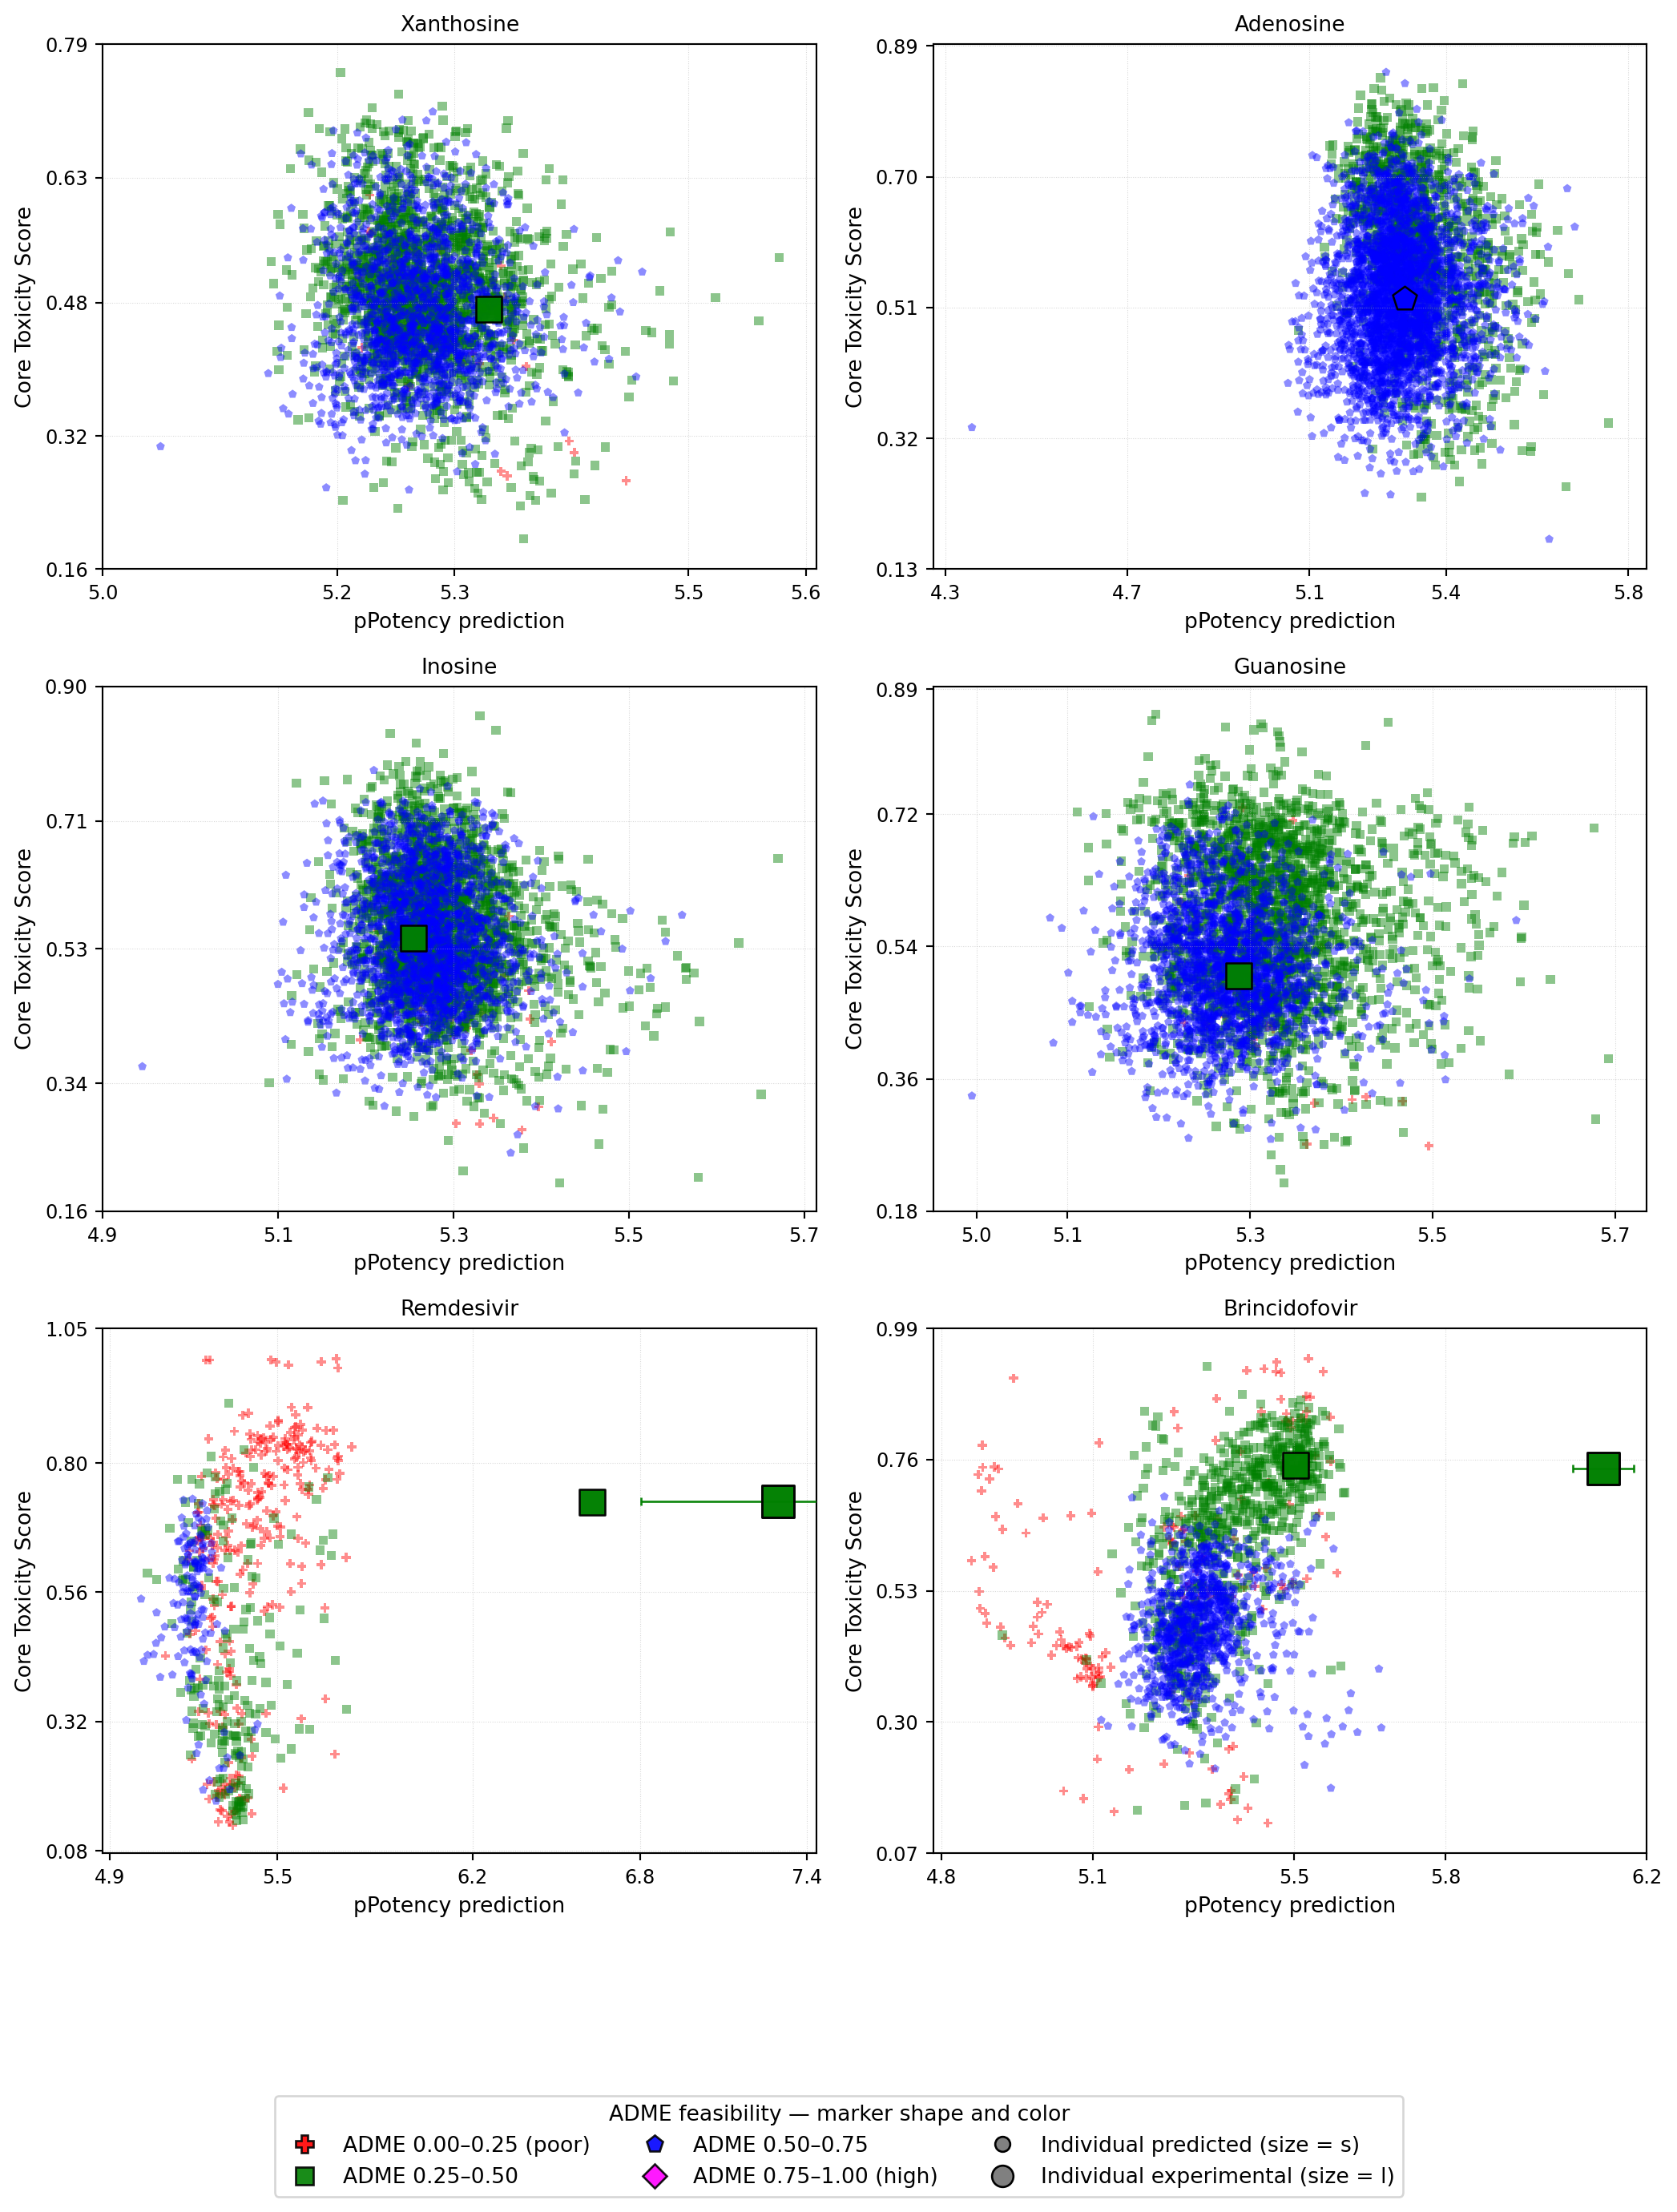

In [127]:
admeBins = [
    (0.00, 0.25, "P", "red", "ADME 0.00–0.25 (poor)"),
    (0.25, 0.50, "s", "green", "ADME 0.25–0.50"),
    (0.50, 0.75, "p", "blue", "ADME 0.50–0.75"),
    (0.75, 1.00, "D", "magenta", "ADME 0.75–1.00 (high)"),
]

def getAdmeBin(val):
    for lo, hi, marker, color, label in admeBins:
        if lo <= float(val) <= hi:
            return marker, color
    return "P", "#D73027"

def computeAxisTicks(values, nTicks=5, nDecimals=1):
    vMin, vMax = np.nanmin(values), np.nanmax(values)
    pad        = (vMax - vMin) * 0.06
    axMin      = max(vMin - pad, 0)
    axMax      = vMax + pad
    ticks      = np.linspace(axMin, axMax, nTicks)
    ticks      = np.round(ticks, nDecimals)
    return axMin, axMax, ticks

familyPlotOrder = [s for s in source_to_base.keys() if s in scoredCandMap]
nFamilies       = len(familyPlotOrder)
nCols           = 2
nRows           = -(-nFamilies // nCols)

indivDF_all = pd.DataFrame()
if "Individual" in scoredCandMap:
    indivDF_all = (scoredCandMap["Individual"]
                   .dropna(subset=["drugName", "pPotency_prediction",
                                   "coreToxicityScore", "ADMEfeasibility"])
                   .drop_duplicates(subset=["drugName", "SMILES"])
                   .copy())

exptDF_all = (exptScoreDF
              .dropna(subset=["drugName", "pPotency_prediction",
                               "coreToxicityScore", "ADMEfeasibility"])
              .drop_duplicates(subset=["drugName", "SMILES"])
              .copy())

fig, axes = plt.subplots(nRows, nCols, figsize=(11, nRows * 4.8))
axes = axes.flatten()

for i, sourceName in enumerate(familyPlotOrder):
    ax       = axes[i]
    baseName = source_to_base[sourceName]

    plotDF = scoredCandMap[sourceName].dropna(
        subset=["pPotency_prediction", "coreToxicityScore", "ADMEfeasibility"]
    ).copy()

    drugPredRows = indivDF_all[indivDF_all["drugName"] == baseName]
    drugExptRows = exptDF_all[exptDF_all["drugName"] == baseName]

    allX = pd.concat([
        plotDF["pPotency_prediction"],
        drugPredRows["pPotency_prediction"],
        drugExptRows["pPotency_prediction"],
    ]).dropna().values

    allY = pd.concat([
        plotDF["coreToxicityScore"],
        drugPredRows["coreToxicityScore"],
        drugExptRows["coreToxicityScore"],
    ]).dropna().values

    xMin, xMax, xTicks = computeAxisTicks(allX, nTicks=5, nDecimals=1)
    yMin, yMax, yTicks = computeAxisTicks(allY, nTicks=5, nDecimals=2)

    for lo, hi, marker, color, binLabel in admeBins:
        mask  = (plotDF["ADMEfeasibility"] >= lo) & (plotDF["ADMEfeasibility"] <= hi)
        binDF = plotDF[mask]
        if len(binDF) == 0:
            continue
        ax.scatter(
            binDF["pPotency_prediction"], binDF["coreToxicityScore"],
            s=18, marker=marker, alpha=0.45, color=color, edgecolors="none"
        )

    for _, row in drugPredRows.iterrows():
        marker, color = getAdmeBin(row["ADMEfeasibility"])
        ax.scatter(
            row["pPotency_prediction"], row["coreToxicityScore"],
            marker=marker, s=140, color=color, edgecolors="black",
            linewidths=0.95, alpha=0.98, zorder=6
        )

    for _, row in drugExptRows.iterrows():
        marker, color = getAdmeBin(row["ADMEfeasibility"])
        ax.scatter(
            row["pPotency_prediction"], row["coreToxicityScore"],
            marker=marker, s=220, color=color, edgecolors="black",
            linewidths=1.1, alpha=0.98, zorder=7
        )
        if pd.notna(row.get("pPotency_std", np.nan)):
            ax.errorbar(
                row["pPotency_prediction"], row["coreToxicityScore"],
                xerr=float(row["pPotency_std"]), fmt="none", ecolor=color,
                elinewidth=1.0, capsize=2, capthick=1.0, alpha=0.95, zorder=6
            )

    ax.set_title(baseName,               fontsize=10, fontfamily="serif")
    ax.set_xlabel("pPotency prediction", fontsize=10, fontfamily="serif")
    ax.set_ylabel("Core Toxicity Score", fontsize=10, fontfamily="serif")
    ax.set_xlim(xMin, xMax)
    ax.set_ylim(yMin, yMax)
    ax.set_xticks(xTicks)
    ax.set_yticks(yTicks)
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(axis="both", linestyle=":", linewidth=0.4, alpha=0.5)

for j in range(nFamilies, len(axes)):
    axes[j].set_visible(False)

masterLegendHandles = [
    mlines.Line2D([], [], linestyle="none", marker=marker,
                  color=color, markersize=8, markeredgecolor="black",
                  alpha=0.9, label=binLabel)
    for _, _, marker, color, binLabel in admeBins
] + [
    mlines.Line2D([], [], linestyle="none", marker="o", color="gray",
                  markersize=7, markeredgecolor="black",
                  label="Individual predicted (size = s)"),
    mlines.Line2D([], [], linestyle="none", marker="o", color="gray",
                  markersize=10, markeredgecolor="black",
                  label="Individual experimental (size = l)"),
]

fig.legend(
    handles=masterLegendHandles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=3,
    frameon=True,
    prop=tnr,
    title="ADME feasibility — marker shape and color",
    title_fontproperties=tnr,
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotency_CoreToxicity_ADME_all.svg"), format="svg", dpi=600)
plt.savefig(os.path.join(resultsDir, "combinedEbola_pPotency_CoreToxicity_ADME_all.png"), format="png", dpi=600)
plt.show()

# 5. Reinforcement learning `wPotency`

## 4.3.1.2 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span> from high potency compounds

DORAnet starter: `top 20 high potency` candidates from Inosine + Guanosine + Xanthosine + Adenosine

### Import all compounds generated by `DORAnet` from `InoAdeGuoXan` with (gen=1,2,3) --> Possible `Antivirals`

In [ ]:
Top20_InoAdeGuoXan_DORAnetGenerated = pd.read_csv(resultsDir + "/DORAnet/InoAdeGuoXan/EbolaTop20_InoAdeGuoXan_DORAnet_generatedCompounds.csv", dtype=str)
print(f"Loaded {len(Top20_InoAdeGuoXan_DORAnetGenerated)} molecules")
Top20_InoAdeGuoXan_DORAnetGenerated['source_DataBase'] = 'Top20_InoAdeGuoXan'
Top20_InoAdeGuoXan_DORAnetGenerated = Top20_InoAdeGuoXan_DORAnetGenerated.rename(columns={'Generated_Compound_SMILES': 'Canonical_SMILES'})
print("Generated_Compound_SMILES columns has been renamed to Canonical_SMILES")
Top20_InoAdeGuoXan_DORAnetGenerated

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# --- Canonicalize SMILES helper ---
def canonicalizeSmiles(x):
    if pd.isna(x):
        return None
    mol = Chem.MolFromSmiles(str(x))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

# ---- training SMILES from EbolaVirusData_allDB ----
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# ---- ALSO exclude smiles already present in generated top20 set ----
generated_top20_smiles_set = set(
    combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20["Canonical_SMILES"]
    .dropna().astype(str)
)

# Final exclusion set = union of both
exclusion_smiles_set = training_smiles_set | generated_top20_smiles_set

# ---- overlap check with external ----
external_canon_set = set(
    Top20_InoAdeGuoXan_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)

common_with_training = external_canon_set & training_smiles_set
common_with_generated_top20 = external_canon_set & generated_top20_smiles_set
common_with_either = common_with_training | common_with_generated_top20

print(f"Overlap (external ∩ EbolaVirusData_allDB): {len(common_with_training)}")
print(f"Overlap (external ∩ combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20): "
      f"{len(common_with_generated_top20)}")
print(f"Total overlap to remove (either set): {len(common_with_either)}")

# ---- remove rows from external that overlap with either exclusion set ----
before = len(Top20_InoAdeGuoXan_DORAnetGenerated)
Top20_InoAdeGuoXan_DORAnetGenerated = Top20_InoAdeGuoXan_DORAnetGenerated[
    ~Top20_InoAdeGuoXan_DORAnetGenerated["Canonical_SMILES"].isin(exclusion_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(Top20_InoAdeGuoXan_DORAnetGenerated)
print(f"Training/generation overlap rows removed from external: {removed_external_rows}")
print(f"Total buyable antiviral molecules for external validation after removal: "
      f"{len(Top20_InoAdeGuoXan_DORAnetGenerated)}")

Top20_InoAdeGuoXan_DORAnetGenerated

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Top20_InoAdeGuoXan_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Top20_InoAdeGuoXan_DORAnetGenerated.index)

Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW = pd.concat([Top20_InoAdeGuoXan_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Top20_InoAdeGuoXan_DORAnetGenerated.shape}")
print(f"New dataframe shape: {Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.csv"), index=False)
Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction = Top20_InoAdeGuoXan_DORAnetGenerated_wMACAW.copy()

Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction = Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.filter(
    items=["Starter_Compound_SMILES", "Canonical_SMILES", "DORAnet_gen", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction = (
    Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.csv"), index=False)
Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.loc[Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.loc[Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.2f} ± {min_std:.2f} - {max_pred:.2f} ± {max_std:.2f}")

Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction

### Compare the performance of newly generated compounds with starter molecules

In [ ]:
newlyGeneratedDF = Top20_InoAdeGuoXan_DORAnetGenerated_ARTprediction.copy()
baseDF = combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.copy()

# --- ensure numeric ---
for d in (baseDF, newlyGeneratedDF):
    d["pPotency_prediction"] = pd.to_numeric(d["pPotency_prediction"], errors="coerce")
    d["pPotency_std"] = pd.to_numeric(d["pPotency_std"], errors="coerce")

# Use top 20 by pPotency_prediction (safe even if already top20)
baseDF20 = baseDF.sort_values("pPotency_prediction", ascending=False).head(20)
newlyGeneratedDF20 = newlyGeneratedDF.sort_values("pPotency_prediction", ascending=False).head(20)

# --- compare potency range (min/max) ---
potency_min_base = baseDF20.loc[baseDF20["pPotency_prediction"].idxmin()]
potency_max_base = baseDF20.loc[baseDF20["pPotency_prediction"].idxmax()]

potency_min_other = newlyGeneratedDF20.loc[newlyGeneratedDF20["pPotency_prediction"].idxmin()]
potency_max_other = newlyGeneratedDF20.loc[newlyGeneratedDF20["pPotency_prediction"].idxmax()]

min_base, min_other = potency_min_base["pPotency_prediction"], potency_min_other["pPotency_prediction"]
max_base, max_other = potency_max_base["pPotency_prediction"], potency_max_other["pPotency_prediction"]

def pct_change(new, old):
    old = float(old)
    if old == 0:
        return np.nan
    return (float(new) - old) / old * 100.0

print("Potency range comparison")
print(f"DORAnet starterDF top20:  {min_base:.2f} ± {potency_min_base['pPotency_std']:.2f} - {max_base:.2f} ± {potency_max_base['pPotency_std']:.2f}")

print(f"DORAnet newlyGeneratedDF top20: {min_other:.2f} ± {potency_min_other['pPotency_std']:.2f} - {max_other:.2f} ± {potency_max_other['pPotency_std']:.2f}")

print(f"Percent change in Min potency : {pct_change(min_other, min_base):.2f}%")
print(f"Percent change in Max potency: {pct_change(max_other, max_base):.2f}%")

# --- optional: compound-by-compound percent change (match by Canonical_SMILES) ---
if "Canonical_SMILES" in baseDF20.columns and "Canonical_SMILES" in newlyGeneratedDF20.columns:
    merged = baseDF20[["Canonical_SMILES", "pPotency_prediction"]].merge(
        newlyGeneratedDF20[["Canonical_SMILES", "pPotency_prediction"]],
        on="Canonical_SMILES",
        how="inner",
        suffixes=("_base", "_other")
    )

    # element-wise % change in log-space score (pPotency)
    merged["pct_change_pPotency_prediction"] = merged.apply(
        lambda r: pct_change(r["pPotency_prediction_other"], r["pPotency_prediction_base"]),
        axis=1
    )

    print("\nMatched compounds")
    print(f"Matched top20 compounds: {len(merged)} / 20")
    if len(merged) > 0:
        print(f"Mean % change:   {merged['pct_change_pPotency_prediction'].mean():.2f}%")
        print(f"Median % change: {merged['pct_change_pPotency_prediction'].median():.2f}%")
        print(f"Min % change:    {merged['pct_change_pPotency_prediction'].min():.2f}%")
        print(f"Max % change:    {merged['pct_change_pPotency_prediction'].max():.2f}%")

newlyGeneratedDF20 = newlyGeneratedDF20.drop(columns = ['IC50(M)_prediction', 'IC50(M)_lower_95CI', 'IC50(M)_upper_95CI'])
newlyGeneratedDF20

## 4.3.2.2 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span> from high potency compounds

DORAnet starter: `top 20 high potency` candidates from `Remdesivir`

### Import all compounds generated by `DORAnet` from `Remdesivir` with (gen=1,2,3) --> Possible `Antivirals`

In [ ]:
Top20_Remdesivir_DORAnetGenerated = pd.read_csv(resultsDir + "/DORAnet/Remdesivir/EbolaTop20_Remdesivir_DORAnet_generatedCompounds.csv", dtype=str)
print(f"Loaded {len(Top20_Remdesivir_DORAnetGenerated)} molecules")
Top20_Remdesivir_DORAnetGenerated['source_DataBase'] = 'Top20_Remdesivir'
Top20_Remdesivir_DORAnetGenerated = Top20_Remdesivir_DORAnetGenerated.rename(columns={'Generated_Compound_SMILES': 'Canonical_SMILES'})
print("Generated_Compound_SMILES columns has been renamed to Canonical_SMILES")
Top20_Remdesivir_DORAnetGenerated

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# --- Canonicalize SMILES helper ---
def canonicalizeSmiles(x):
    if pd.isna(x):
        return None
    mol = Chem.MolFromSmiles(str(x))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

# ---- training SMILES from EbolaVirusData_allDB ----
training_smiles_set = set(
    EbolaVirusData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# ---- ALSO exclude smiles already present in generated top20 set ----
generated_top20_smiles_set = set(
    RemdesivirOnly_DORAnetGenerated_wARTprediction_top20["Canonical_SMILES"]
    .dropna().astype(str)
)

# Final exclusion set = union of both
exclusion_smiles_set = training_smiles_set | generated_top20_smiles_set

# ---- overlap check with external ----
external_canon_set = set(
    Top20_Remdesivir_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)

common_with_training = external_canon_set & training_smiles_set
common_with_generated_top20 = external_canon_set & generated_top20_smiles_set
common_with_either = common_with_training | common_with_generated_top20

print(f"Overlap (external ∩ EbolaVirusData_allDB): {len(common_with_training)}")
print(f"Overlap (external ∩ combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20): "
      f"{len(common_with_generated_top20)}")
print(f"Total overlap to remove (either set): {len(common_with_either)}")

# ---- remove rows from external that overlap with either exclusion set ----
before = len(Top20_Remdesivir_DORAnetGenerated)
Top20_Remdesivir_DORAnetGenerated = Top20_Remdesivir_DORAnetGenerated[
    ~Top20_Remdesivir_DORAnetGenerated["Canonical_SMILES"].isin(exclusion_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(Top20_Remdesivir_DORAnetGenerated)
print(f"Training/generation overlap rows removed from external: {removed_external_rows}")
print(f"Total buyable antiviral molecules for external validation after removal: "
      f"{len(Top20_Remdesivir_DORAnetGenerated)}")

Top20_Remdesivir_DORAnetGenerated

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "EbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Top20_Remdesivir_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Top20_Remdesivir_DORAnetGenerated.index)

Top20_Remdesivir_DORAnetGenerated_wMACAW = pd.concat([Top20_Remdesivir_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Top20_Remdesivir_DORAnetGenerated.shape}")
print(f"New dataframe shape: {Top20_Remdesivir_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Top20_Remdesivir_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "Top20_Remdesivir_DORAnetGenerated_wMACAW.csv"), index=False)
Top20_Remdesivir_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in Top20_Remdesivir_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = Top20_Remdesivir_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
Top20_Remdesivir_DORAnetGenerated_ARTprediction = Top20_Remdesivir_DORAnetGenerated_wMACAW.copy()

Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
Top20_Remdesivir_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
Top20_Remdesivir_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
Top20_Remdesivir_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-Top20_Remdesivir_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
Top20_Remdesivir_DORAnetGenerated_ARTprediction = Top20_Remdesivir_DORAnetGenerated_ARTprediction.filter(
    items=["Starter_Compound_SMILES", "Canonical_SMILES", "DORAnet_gen", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

Top20_Remdesivir_DORAnetGenerated_ARTprediction = (
    Top20_Remdesivir_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

Top20_Remdesivir_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/Top20_Remdesivir_DORAnetGenerated_ARTprediction.csv"), index=False)
Top20_Remdesivir_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/Top20_Remdesivir_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = Top20_Remdesivir_DORAnetGenerated_ARTprediction.loc[Top20_Remdesivir_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = Top20_Remdesivir_DORAnetGenerated_ARTprediction.loc[Top20_Remdesivir_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.2f} ± {min_std:.2f} - {max_pred:.2f} ± {max_std:.2f}")

Top20_Remdesivir_DORAnetGenerated_ARTprediction

### Compare the performance of newly generated compounds with starter molecules

In [ ]:
newlyGeneratedDF = Top20_Remdesivir_DORAnetGenerated_ARTprediction.copy()
baseDF = RemdesivirOnly_DORAnetGenerated_wARTprediction_top20.copy()

# --- ensure numeric ---
for d in (baseDF, newlyGeneratedDF):
    d["pPotency_prediction"] = pd.to_numeric(d["pPotency_prediction"], errors="coerce")
    d["pPotency_std"] = pd.to_numeric(d["pPotency_std"], errors="coerce")

# Use top 20 by pPotency_prediction (safe even if already top20)
baseDF20 = baseDF.sort_values("pPotency_prediction", ascending=False).head(20)
newlyGeneratedDF20 = newlyGeneratedDF.sort_values("pPotency_prediction", ascending=False).head(20)

# --- compare potency range (min/max) ---
potency_min_base = baseDF20.loc[baseDF20["pPotency_prediction"].idxmin()]
potency_max_base = baseDF20.loc[baseDF20["pPotency_prediction"].idxmax()]

potency_min_other = newlyGeneratedDF20.loc[newlyGeneratedDF20["pPotency_prediction"].idxmin()]
potency_max_other = newlyGeneratedDF20.loc[newlyGeneratedDF20["pPotency_prediction"].idxmax()]

min_base, min_other = potency_min_base["pPotency_prediction"], potency_min_other["pPotency_prediction"]
max_base, max_other = potency_max_base["pPotency_prediction"], potency_max_other["pPotency_prediction"]

def pct_change(new, old):
    old = float(old)
    if old == 0:
        return np.nan
    return (float(new) - old) / old * 100.0

print("Potency range comparison")
print(f"DORAnet starterDF top20:  {min_base:.2f} ± {potency_min_base['pPotency_std']:.2f} - {max_base:.2f} ± {potency_max_base['pPotency_std']:.2f}")

print(f"DORAnet newlyGeneratedDF top20: {min_other:.2f} ± {potency_min_other['pPotency_std']:.2f} - {max_other:.2f} ± {potency_max_other['pPotency_std']:.2f}")

print(f"Percent change in Min potency : {pct_change(min_other, min_base):.2f}%")
print(f"Percent change in Max potency: {pct_change(max_other, max_base):.2f}%")

# --- optional: compound-by-compound percent change (match by Canonical_SMILES) ---
if "Canonical_SMILES" in baseDF20.columns and "Canonical_SMILES" in newlyGeneratedDF20.columns:
    merged = baseDF20[["Canonical_SMILES", "pPotency_prediction"]].merge(
        newlyGeneratedDF20[["Canonical_SMILES", "pPotency_prediction"]],
        on="Canonical_SMILES",
        how="inner",
        suffixes=("_base", "_other")
    )

    # element-wise % change in log-space score (pPotency)
    merged["pct_change_pPotency_prediction"] = merged.apply(
        lambda r: pct_change(r["pPotency_prediction_other"], r["pPotency_prediction_base"]),
        axis=1
    )

    print("\nMatched compounds")
    print(f"Matched top20 compounds: {len(merged)} / 20")
    if len(merged) > 0:
        print(f"Mean % change:   {merged['pct_change_pPotency_prediction'].mean():.2f}%")
        print(f"Median % change: {merged['pct_change_pPotency_prediction'].median():.2f}%")
        print(f"Min % change:    {merged['pct_change_pPotency_prediction'].min():.2f}%")
        print(f"Max % change:    {merged['pct_change_pPotency_prediction'].max():.2f}%")

newlyGeneratedDF20 = newlyGeneratedDF20.drop(columns = ['IC50(M)_prediction', 'IC50(M)_lower_95CI', 'IC50(M)_upper_95CI'])
#newlyGeneratedDF20.to_csv(os.path.join(resultsDir, "Top20_Remdesivir_DORAnetGenerated_.csv"), index=False)
newlyGeneratedDF20

# How structurally close are the `DORAnet generated` validation compounds with the model `training` compounds?

In [ ]:
%%time

# -----------------------------
# User settings
# -----------------------------
smilesCol = "Canonical_SMILES"
randomSeed = 42
fpRadius = 2
fpBits = 2048

# Training selection
nTrainingToUse = None
trainingSortCol = "pPotency"
trainingSortAscending = False

# External selection
nExternalToUse = 5000   # selected from EACH external dataframe; reduce if MDS is slow

# Options:
#   "topPotency"        = top predicted-potency candidates
#   "random"            = random candidates
#   "diverse"           = chemically diverse candidates
#   "topPotencyDiverse" = top predicted-potency pool, then diverse subset
externalSelectionMode = "diverse"

externalSortCol = "pPotency_prediction"
externalSortAscending = False
topPotencyPoolSize = 10000

# Plot settings
savePlots = True

# -----------------------------
# External datasets to compare
# -----------------------------
externalDatasetDict = {
    "DORAnet generated antivirals": {
        "DF": combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.copy(),
        "color": "blue",
        "marker": "+",
    },
    "Remdesivir-only DORAnet": {
        "DF": RemdesivirOnly_DORAnetGenerated_ARTprediction.copy(),
        "color": "red",
        "marker": "+",
    },
    "Buyable antivirals": {
        "DF": combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.copy(),
        "color": "green",
        "marker": "+",
    },
}

# -----------------------------
# Helper: select all, top-N, or random-N molecules
# -----------------------------
def selectMolecules(DF, nToUse=None, sortCol=None, ascending=False, randomSeed=42):
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    if sortCol is not None and sortCol in DF.columns:
        return DF.sort_values(sortCol, ascending=ascending).head(nToUse).copy()

    return DF.sample(n=nToUse, random_state=randomSeed).copy()


# -----------------------------
# Helper: diversity-aware MaxMin selection
# -----------------------------
def selectDiverseMoleculesByMaxMin(DF, fpCol="fp", nToUse=1000, randomSeed=42):
    """
    Selects a chemically diverse subset using RDKit MaxMinPicker.
    This spreads molecules across Morgan/Tanimoto chemical space.
    """
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    fps = list(DF[fpCol])
    picker = MaxMinPicker()

    selectedIdx = list(
        picker.LazyBitVectorPick(
            fps,
            len(fps),
            nToUse,
            seed=randomSeed
        )
    )

    return DF.iloc[selectedIdx].copy()


def selectExternalCandidates(
    DF,
    mode="diverse",
    nToUse=1000,
    sortCol="pPotency_prediction",
    ascending=False,
    topPotencyPoolSize=10000,
    randomSeed=42
):
    """
    Select external candidates using topPotency, random, diverse, or topPotencyDiverse.
    """
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    if mode == "topPotency":
        return DF.sort_values(sortCol, ascending=ascending).head(nToUse).copy()

    if mode == "random":
        return DF.sample(n=nToUse, random_state=randomSeed).copy()

    if mode == "diverse":
        return selectDiverseMoleculesByMaxMin(
            DF,
            fpCol="fp",
            nToUse=nToUse,
            randomSeed=randomSeed
        )

    if mode == "topPotencyDiverse":
        if sortCol not in DF.columns:
            raise ValueError(f"{sortCol} not found in external dataframe.")

        poolSize = min(topPotencyPoolSize, len(DF))
        potencyPoolDF = DF.sort_values(sortCol, ascending=ascending).head(poolSize).copy()

        return selectDiverseMoleculesByMaxMin(
            potencyPoolDF,
            fpCol="fp",
            nToUse=nToUse,
            randomSeed=randomSeed
        )

    raise ValueError(f"Unknown externalSelectionMode: {mode}")


# -----------------------------
# Prepare training dataset
# -----------------------------
trainingDF = EbolaVirusData_allDB.copy()
trainingDF["dataSet"] = "Training"

# Use Canonical_SMILES directly; only check RDKit validity
trainingDF["mol"] = trainingDF[smilesCol].apply(
    lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None
)

trainingDF = trainingDF.dropna(subset=["mol"]).drop_duplicates(subset=[smilesCol]).copy()

# Morgan fingerprint generator
morganGenerator = rdFingerprintGenerator.GetMorganGenerator(
    radius=fpRadius,
    fpSize=fpBits
)

trainingDF["fp"] = trainingDF["mol"].apply(morganGenerator.GetFingerprint)

trainingDF = selectMolecules(
    trainingDF,
    nToUse=nTrainingToUse,
    sortCol=trainingSortCol,
    ascending=trainingSortAscending,
    randomSeed=randomSeed
)

print(f"Selected training molecules: {len(trainingDF)}")

# -----------------------------
# Prepare and select all external datasets
# -----------------------------
selectedExternalDFList = []

for externalName, externalInfo in externalDatasetDict.items():
    tmpDF = externalInfo["DF"].copy()
    tmpDF["dataSet"] = externalName

    tmpDF["mol"] = tmpDF[smilesCol].apply(
        lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None
    )

    tmpDF = tmpDF.dropna(subset=["mol"]).drop_duplicates(subset=[smilesCol]).copy()
    tmpDF["fp"] = tmpDF["mol"].apply(morganGenerator.GetFingerprint)

    tmpDF = selectExternalCandidates(
        tmpDF,
        mode=externalSelectionMode,
        nToUse=nExternalToUse,
        sortCol=externalSortCol,
        ascending=externalSortAscending,
        topPotencyPoolSize=topPotencyPoolSize,
        randomSeed=randomSeed
    )

    overlapSmiles = set(trainingDF[smilesCol]).intersection(set(tmpDF[smilesCol]))

    print(f"{externalName}: selected molecules = {len(tmpDF)}")
    print(f"{externalName}: exact overlap with training = {len(overlapSmiles)}")

    selectedExternalDFList.append(tmpDF)

externalAllDF = pd.concat(selectedExternalDFList, ignore_index=True).copy()

print(f"Total selected external molecules: {len(externalAllDF)}")
print(f"External selection mode: {externalSelectionMode}")

# -----------------------------
# Potency distribution plot
# -----------------------------
trainingPotencyCol = "pPotency"
externalPotencyCol = "pPotency_prediction"

trainingPotency = pd.to_numeric(trainingDF[trainingPotencyCol], errors="coerce").dropna()

allPotencyList = [trainingPotency]

for externalName in externalDatasetDict.keys():
    tmpPotency = pd.to_numeric(
        externalAllDF.loc[externalAllDF["dataSet"] == externalName, externalPotencyCol],
        errors="coerce"
    ).dropna()
    allPotencyList.append(tmpPotency)

allPotency = pd.concat(allPotencyList, ignore_index=True)
potencyBins = np.linspace(allPotency.min(), allPotency.max(), 25)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    trainingPotency,
    bins=potencyBins,
    alpha=0.8,
    color="orange",
    label=f"Training set, n={len(trainingPotency)}"
)

for externalName, externalInfo in externalDatasetDict.items():
    tmpPotency = pd.to_numeric(
        externalAllDF.loc[externalAllDF["dataSet"] == externalName, externalPotencyCol],
        errors="coerce"
    ).dropna()

    ax.hist(
        tmpPotency,
        bins=potencyBins,
        alpha=0.45,
        color=externalInfo["color"],
        label=f"{externalName}, n={len(tmpPotency)}"
    )

ax.set_xlabel("Potency / predicted potency")
ax.set_ylabel("Number of molecules")
ax.set_title("Potency distribution: training vs external validation datasets")
ax.legend(frameon=False)

plt.tight_layout()

if savePlots:
    plt.savefig(resultsDir + "potency_distribution_all_external_sets.png", dpi=600)

plt.show()

# -----------------------------
# Quantify distance: each external molecule -> nearest training molecule
# -----------------------------
trainingFps = list(trainingDF["fp"])
nearestRows = []

for _, externalRow in externalAllDF.iterrows():
    similarities = np.array(DataStructs.BulkTanimotoSimilarity(externalRow["fp"], trainingFps))
    bestIdx = int(np.argmax(similarities))
    bestSimilarity = float(similarities[bestIdx])
    nearestTrainingRow = trainingDF.iloc[bestIdx]

    nearestRows.append({
        "External_Source": externalRow["dataSet"],
        "External_Rank": externalRow.get("Rank", np.nan),
        "External_SMILES": externalRow[smilesCol],
        "External_pPotency_prediction": externalRow.get("pPotency_prediction", np.nan),
        "External_pPotency_std": externalRow.get("pPotency_std", np.nan),
        "External_IC50_uM": externalRow.get("IC50 (µM)", np.nan),

        "Nearest_training_compound_id": nearestTrainingRow.get("compound_id", np.nan),
        "Nearest_training_SMILES": nearestTrainingRow[smilesCol],
        "Nearest_training_pPotency": nearestTrainingRow.get("pPotency", np.nan),
        "Nearest_training_StrainClassifier": nearestTrainingRow.get("StrainClassifier", np.nan),

        "Max_Tanimoto_to_training": bestSimilarity,
        "Tanimoto_distance_to_training": 1.0 - bestSimilarity
    })

nearestNeighborDF = pd.DataFrame(nearestRows).sort_values(
    ["External_Source", "Max_Tanimoto_to_training"],
    ascending=[True, False]
)

nearestNeighborDF["Chemical_space_category"] = pd.cut(
    nearestNeighborDF["Max_Tanimoto_to_training"],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=["Far from training set", "Moderately close", "Close to training set"]
)

print("Nearest-neighbor summary by external source:")
display(
    nearestNeighborDF
    .groupby(["External_Source", "Chemical_space_category"], observed=False)
    .size()
    .reset_index(name="Number_of_molecules")
)

# -----------------------------
# Build MDS embedding using training + all selected external datasets
# Warning: all-vs-all MDS can become slow if total selected molecules is large
# -----------------------------
plotDF = pd.concat([trainingDF, externalAllDF], ignore_index=True).copy()
plotFps = list(plotDF["fp"])

print(f"Total molecules used in MDS plot: {len(plotDF)}")

distanceMatrix = np.zeros((len(plotFps), len(plotFps)), dtype=np.float32)

for i, fp in enumerate(plotFps):
    distanceMatrix[i, :] = 1.0 - np.array(DataStructs.BulkTanimotoSimilarity(fp, plotFps))

mdsModel = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=randomSeed,
    n_init=4,
    max_iter=500
)

embedding = mdsModel.fit_transform(distanceMatrix)

plotDF["MDS1"] = embedding[:, 0]
plotDF["MDS2"] = embedding[:, 1]

# -----------------------------
# Plot chemical embedding space with requested colors/symbols
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 7))

trainingMask = plotDF["dataSet"] == "Training"

# Training: red dot
ax.scatter(
    plotDF.loc[trainingMask, "MDS1"],
    plotDF.loc[trainingMask, "MDS2"],
    s=22,
    alpha=0.8,
    color="orange",
    marker="o",
    label=f"Training set (n={trainingMask.sum()})"
)

# External datasets: + marker with specified colors
for externalName, externalInfo in externalDatasetDict.items():
    externalMask = plotDF["dataSet"] == externalName

    ax.scatter(
        plotDF.loc[externalMask, "MDS1"],
        plotDF.loc[externalMask, "MDS2"],
        s=70,
        alpha=0.85,
        color=externalInfo["color"],
        marker=externalInfo["marker"],
        label=f"{externalName} (n={externalMask.sum()})"
    )

ax.set_xlabel("MDS1 from Morgan/Tanimoto distance")
ax.set_ylabel("MDS2 from Morgan/Tanimoto distance")
ax.set_title("Training vs multiple external validation datasets in chemical embedding space")
ax.legend(frameon=False,loc="center left",bbox_to_anchor=(1.02, 0.5),borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.78, 1])

if savePlots:
    plt.savefig(resultsDir + "structural_similarity_embeddings.png", dpi=600)

plt.show()

# -----------------------------
# Plot nearest-neighbor similarity distribution by external source
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

similarityBins = np.linspace(0, 1, 21)

for externalName, externalInfo in externalDatasetDict.items():
    tmpSimilarity = nearestNeighborDF.loc[
        nearestNeighborDF["External_Source"] == externalName,
        "Max_Tanimoto_to_training"
    ]

    ax.hist(
        tmpSimilarity,
        bins=similarityBins,
        alpha=0.45,
        color=externalInfo["color"],
        label=f"{externalName}, n={len(tmpSimilarity)}"
    )

ax.axvline(0.50, linestyle="--", linewidth=1, c='k')

ax.set_xlabel("Maximum Tanimoto similarity to selected training set")
ax.set_ylabel("Number of external molecules")
ax.set_title("Nearest training-set similarity by external dataset")
ax.legend(frameon=False)

plt.tight_layout()

if savePlots:
    plt.savefig(resultsDir + "nearest_neighbor_similarity_distribution.png", dpi=600)

plt.show()


# -----------------------------
# Plot predicted potency vs maximum Tanimoto similarity to training set
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

for externalName, externalInfo in externalDatasetDict.items():
    tmpDF = nearestNeighborDF.loc[
        nearestNeighborDF["External_Source"] == externalName
    ].copy()

    tmpDF["External_pPotency_prediction"] = pd.to_numeric(
        tmpDF["External_pPotency_prediction"],
        errors="coerce"
    )

    tmpDF["Max_Tanimoto_to_training"] = pd.to_numeric(
        tmpDF["Max_Tanimoto_to_training"],
        errors="coerce"
    )

    tmpDF = tmpDF.dropna(
        subset=["External_pPotency_prediction", "Max_Tanimoto_to_training"]
    )

    ax.scatter(
        tmpDF["External_pPotency_prediction"],
        tmpDF["Max_Tanimoto_to_training"],
        s=45,
        alpha=0.70,
        color=externalInfo["color"],
        marker=externalInfo["marker"],
        label=f"{externalName} (n={len(tmpDF)})"
    )


ax.set_ylim(0,1)
ax.set_xlabel("Predicted pPotency")
ax.set_ylabel("Tanimoto similarity with training set")
ax.set_title("Predicted potency vs chemical-space support")
ax.legend(frameon=False,loc="center left",bbox_to_anchor=(1, 0.5),borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.78, 1])
if savePlots:
    plt.savefig(resultsDir + "pPotency_vs_tanimoto.png",dpi=600,bbox_inches="tight")
plt.show()

### USing Atom pair similairty inspired by Tyler's previous work `eiR`

https://github.com/girke-lab/eiR

In [ ]:
%%time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import rdMolDescriptors
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

from sklearn.neighbors import NearestNeighbors

# -----------------------------
# User settings
# -----------------------------
smilesCol = "Canonical_SMILES"
randomSeed = 42

# Atom-pair fingerprint settings
fpBits = 2048

# eiR-style embedding/indexing settings
nReferenceCompounds = 128       # reference / exemplar compounds
embeddingDim = 16               # low-dimensional EI-MDS space
indexTopK = 50                  # retrieve top-K embedded neighbors, then exact re-rank
nJobs = 16

# Optional validation against exact brute-force search
runExactValidation = True
nValidationQueries = 500

# Training selection
nTrainingToUse = None
trainingSortCol = "pPotency"
trainingSortAscending = False

# External selection
nExternalToUse = None           # selected from EACH external dataframe

# Options:
#   "topPotency"        = top predicted-potency candidates
#   "random"            = random candidates
#   "diverse"           = diversity-aware candidates
#   "topPotencyDiverse" = first take top potency pool, then diverse subset
externalSelectionMode = "diverse"

externalSortCol = "pPotency_prediction"
externalSortAscending = False
topPotencyPoolSize = 10000

# Plot settings
savePlots = False

if "resultsDir" not in globals():
    resultsDir = "./"

fpLabel = "atom-pair/Tanimoto"
outputSuffix = "eiR_atomPair"

# -----------------------------
# External datasets to compare
# -----------------------------
externalDatasetDict = {
    "DORAnet generated antivirals": {
        "DF": combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.copy(),
        "color": "blue",
        "marker": "+",
    },
    "Remdesivir-only DORAnet": {
        "DF": RemdesivirOnly_DORAnetGenerated_ARTprediction.copy(),
        "color": "red",
        "marker": "+",
    },
    "Buyable antivirals": {
        "DF": combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.copy(),
        "color": "green",
        "marker": "+",
    },
}

# -----------------------------
# Fingerprint function: atom-pair descriptors
# -----------------------------
def getAtomPairFingerprint(mol, nBits=2048):
    return rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(
        mol,
        nBits=nBits
    )

# -----------------------------
# Helper: select all, top-N, or random-N molecules
# -----------------------------
def selectMolecules(DF, nToUse=None, sortCol=None, ascending=False, randomSeed=42):
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    if sortCol is not None and sortCol in DF.columns:
        return DF.sort_values(sortCol, ascending=ascending).head(nToUse).copy()

    return DF.sample(n=nToUse, random_state=randomSeed).copy()

# -----------------------------
# Helper: diversity-aware MaxMin selection
# -----------------------------
def selectDiverseMoleculesByMaxMin(DF, fpCol="fp", nToUse=1000, randomSeed=42):
    """
    Selects a chemically diverse subset using RDKit MaxMinPicker.
    Here diversity is based on atom-pair fingerprints.
    """
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    fps = list(DF[fpCol])
    picker = MaxMinPicker()

    selectedIdx = list(
        picker.LazyBitVectorPick(
            fps,
            len(fps),
            int(nToUse),
            seed=int(randomSeed)
        )
    )

    return DF.iloc[selectedIdx].copy()

def selectExternalCandidates(
    DF,
    mode="diverse",
    nToUse=1000,
    sortCol="pPotency_prediction",
    ascending=False,
    topPotencyPoolSize=10000,
    randomSeed=42
):
    DF = DF.copy()

    if nToUse is None or nToUse >= len(DF):
        return DF

    if mode == "topPotency":
        return DF.sort_values(sortCol, ascending=ascending).head(nToUse).copy()

    if mode == "random":
        return DF.sample(n=nToUse, random_state=randomSeed).copy()

    if mode == "diverse":
        return selectDiverseMoleculesByMaxMin(
            DF,
            fpCol="fp",
            nToUse=nToUse,
            randomSeed=randomSeed
        )

    if mode == "topPotencyDiverse":
        if sortCol not in DF.columns:
            raise ValueError(f"{sortCol} not found in external dataframe.")

        poolSize = min(topPotencyPoolSize, len(DF))
        potencyPoolDF = DF.sort_values(sortCol, ascending=ascending).head(poolSize).copy()

        return selectDiverseMoleculesByMaxMin(
            potencyPoolDF,
            fpCol="fp",
            nToUse=nToUse,
            randomSeed=randomSeed
        )

    raise ValueError(f"Unknown externalSelectionMode: {mode}")

# -----------------------------
# eiR-style landmark MDS functions
# -----------------------------
def buildLandmarkMdsModel(referenceFps, embeddingDim=16):
    """
    Build landmark-MDS model from reference compounds.

    Reference distance matrix:
        D_ref = 1 - atom-pair Tanimoto

    Classical MDS is fit only on references.
    New compounds are projected using their distances to references.
    """
    nRef = len(referenceFps)
    refDistanceMatrix = np.zeros((nRef, nRef), dtype=np.float64)

    for i, fp in enumerate(referenceFps):
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fp, referenceFps), dtype=np.float64)
        refDistanceMatrix[i, :] = 1.0 - sims

    refD2 = refDistanceMatrix ** 2

    rowMean = refD2.mean(axis=1)
    grandMean = refD2.mean()

    centeredB = -0.5 * (
        refD2
        - rowMean[:, None]
        - rowMean[None, :]
        + grandMean
    )

    eigVals, eigVecs = np.linalg.eigh(centeredB)
    order = np.argsort(eigVals)[::-1]

    eigVals = eigVals[order]
    eigVecs = eigVecs[:, order]

    positiveMask = eigVals > 1e-12
    eigVals = eigVals[positiveMask]
    eigVecs = eigVecs[:, positiveMask]

    k = min(embeddingDim, len(eigVals))
    eigVals = eigVals[:k]
    eigVecs = eigVecs[:, :k]

    model = {
        "referenceFps": referenceFps,
        "refD2RowMean": rowMean,
        "refD2GrandMean": grandMean,
        "eigVals": eigVals,
        "eigVecs": eigVecs,
        "embeddingDimActual": k,
    }

    return model

def transformFpsWithLandmarkMds(fps, landmarkModel):
    """
    Project molecules into landmark-MDS space using distances to reference compounds.
    """
    referenceFps = landmarkModel["referenceFps"]
    refD2RowMean = landmarkModel["refD2RowMean"]
    refD2GrandMean = landmarkModel["refD2GrandMean"]
    eigVals = landmarkModel["eigVals"]
    eigVecs = landmarkModel["eigVecs"]

    coords = np.zeros((len(fps), len(eigVals)), dtype=np.float64)

    for i, fp in enumerate(fps):
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fp, referenceFps), dtype=np.float64)
        dist = 1.0 - sims
        dist2 = dist ** 2
        dist2Mean = dist2.mean()

        # Out-of-sample classical MDS projection
        b = -0.5 * (
            dist2
            - dist2Mean
            - refD2RowMean
            + refD2GrandMean
        )

        coords[i, :] = b @ eigVecs / np.sqrt(eigVals)

    return coords

def indexedNearestTrainingSearch(
    trainingDF,
    externalAllDF,
    trainingCoords,
    externalCoords,
    smilesCol,
    indexTopK=50,
    nJobs=16
):
    """
    eiR-style search:
      1. Search nearest training molecules in embedded/indexed space.
      2. Re-rank retrieved top-K candidates using exact atom-pair Tanimoto.
      3. Keep best exact Tanimoto among retrieved candidates.
    """
    trainingFps = list(trainingDF["fp"])
    externalFps = list(externalAllDF["fp"])

    topK = min(indexTopK, len(trainingDF))

    nnIndex = NearestNeighbors(
        n_neighbors=topK,
        algorithm="auto",
        metric="euclidean",
        n_jobs=nJobs
    )

    nnIndex.fit(trainingCoords)

    embeddedDistances, embeddedNeighborIdx = nnIndex.kneighbors(
        externalCoords,
        return_distance=True
    )

    nearestRows = []

    for i, (_, externalRow) in enumerate(externalAllDF.iterrows()):
        candidateIdx = embeddedNeighborIdx[i]
        candidateFps = [trainingFps[j] for j in candidateIdx]

        exactSims = np.array(
            DataStructs.BulkTanimotoSimilarity(externalFps[i], candidateFps),
            dtype=np.float64
        )

        localBest = int(np.argmax(exactSims))
        bestTrainingIdx = int(candidateIdx[localBest])
        bestSimilarity = float(exactSims[localBest])
        nearestTrainingRow = trainingDF.iloc[bestTrainingIdx]

        nearestRows.append({
            "External_Source": externalRow["dataSet"],
            "External_Rank": externalRow.get("Rank", np.nan),
            "External_SMILES": externalRow[smilesCol],
            "External_pPotency_prediction": externalRow.get("pPotency_prediction", np.nan),
            "External_pPotency_std": externalRow.get("pPotency_std", np.nan),
            "External_IC50_uM": externalRow.get("IC50 (µM)", np.nan),

            "Nearest_training_compound_id": nearestTrainingRow.get("compound_id", np.nan),
            "Nearest_training_SMILES": nearestTrainingRow[smilesCol],
            "Nearest_training_pPotency": nearestTrainingRow.get("pPotency", np.nan),
            "Nearest_training_StrainClassifier": nearestTrainingRow.get("StrainClassifier", np.nan),

            "Max_Tanimoto_to_training": bestSimilarity,
            "Tanimoto_distance_to_training": 1.0 - bestSimilarity,

            "EI_index_topK": topK,
            "EI_embedding_distance": float(embeddedDistances[i][localBest]),
            "Search_method": "eiR_style_landmarkMDS_index_exactRerank",
            "Fingerprint_type": "atomPair"
        })

        if (i + 1) % 10000 == 0:
            print(f"Indexed nearest-neighbor search completed for {i + 1:,} external molecules")

    return pd.DataFrame(nearestRows)

def validateIndexedSearch(trainingDF, externalAllDF, embeddedNeighborIdx, nValidationQueries=500, randomSeed=42):
    """
    Optional validation:
    Compare EI-style indexed top-K retrieval against exact brute-force atom-pair Tanimoto
    on a sample of external queries.
    """
    nQueries = min(nValidationQueries, len(externalAllDF))
    rng = np.random.default_rng(randomSeed)
    sampledIdx = rng.choice(len(externalAllDF), size=nQueries, replace=False)

    trainingFps = list(trainingDF["fp"])
    externalFps = list(externalAllDF["fp"])

    exactBestInTopK = []
    similarityLoss = []

    for i in sampledIdx:
        fullSims = np.array(
            DataStructs.BulkTanimotoSimilarity(externalFps[i], trainingFps),
            dtype=np.float64
        )
        exactBestIdx = int(np.argmax(fullSims))
        exactBestSim = float(fullSims[exactBestIdx])

        topKIdx = embeddedNeighborIdx[i]
        topKFps = [trainingFps[j] for j in topKIdx]
        topKSims = np.array(
            DataStructs.BulkTanimotoSimilarity(externalFps[i], topKFps),
            dtype=np.float64
        )

        approxBestSim = float(np.max(topKSims))
        exactBestInTopK.append(exactBestIdx in set(topKIdx))
        similarityLoss.append(exactBestSim - approxBestSim)

    validationSummary = {
        "nValidationQueries": nQueries,
        "recallExactBestAtTopK": float(np.mean(exactBestInTopK)),
        "meanSimilarityLoss": float(np.mean(similarityLoss)),
        "medianSimilarityLoss": float(np.median(similarityLoss)),
        "maxSimilarityLoss": float(np.max(similarityLoss)),
    }

    return validationSummary

# -----------------------------
# Prepare training dataset
# -----------------------------
trainingDF = EbolaVirusData_allDB.copy()
trainingDF["dataSet"] = "Training"

trainingDF["mol"] = trainingDF[smilesCol].apply(
    lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None
)

trainingDF = trainingDF.dropna(subset=["mol"]).drop_duplicates(subset=[smilesCol]).copy()

trainingDF["fp"] = trainingDF["mol"].apply(
    lambda mol: getAtomPairFingerprint(mol, nBits=fpBits)
)

trainingDF = selectMolecules(
    trainingDF,
    nToUse=nTrainingToUse,
    sortCol=trainingSortCol,
    ascending=trainingSortAscending,
    randomSeed=randomSeed
)

print(f"Selected training molecules: {len(trainingDF)}")
print(f"Atom-pair fingerprint bits: {fpBits}")

# -----------------------------
# Prepare and select all external datasets
# -----------------------------
selectedExternalDFList = []

for externalName, externalInfo in externalDatasetDict.items():
    tmpDF = externalInfo["DF"].copy()
    tmpDF["dataSet"] = externalName

    tmpDF["mol"] = tmpDF[smilesCol].apply(
        lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None
    )

    tmpDF = tmpDF.dropna(subset=["mol"]).drop_duplicates(subset=[smilesCol]).copy()

    tmpDF["fp"] = tmpDF["mol"].apply(
        lambda mol: getAtomPairFingerprint(mol, nBits=fpBits)
    )

    tmpDF = selectExternalCandidates(
        tmpDF,
        mode=externalSelectionMode,
        nToUse=nExternalToUse,
        sortCol=externalSortCol,
        ascending=externalSortAscending,
        topPotencyPoolSize=topPotencyPoolSize,
        randomSeed=randomSeed
    )

    overlapSmiles = set(trainingDF[smilesCol]).intersection(set(tmpDF[smilesCol]))

    print(f"{externalName}: selected molecules = {len(tmpDF)}")
    print(f"{externalName}: exact overlap with training = {len(overlapSmiles)}")

    selectedExternalDFList.append(tmpDF)

externalAllDF = pd.concat(selectedExternalDFList, ignore_index=True).copy()

print(f"Total selected external molecules: {len(externalAllDF)}")
print(f"External selection mode: {externalSelectionMode}")

# -----------------------------
# Potency distribution plot
# -----------------------------
trainingPotencyCol = "pPotency"
externalPotencyCol = "pPotency_prediction"

trainingPotency = pd.to_numeric(trainingDF[trainingPotencyCol], errors="coerce").dropna()

allPotencyList = [trainingPotency]

for externalName in externalDatasetDict.keys():
    tmpPotency = pd.to_numeric(
        externalAllDF.loc[externalAllDF["dataSet"] == externalName, externalPotencyCol],
        errors="coerce"
    ).dropna()
    allPotencyList.append(tmpPotency)

allPotency = pd.concat(allPotencyList, ignore_index=True)
potencyBins = np.linspace(allPotency.min(), allPotency.max(), 25)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    trainingPotency,
    bins=potencyBins,
    alpha=0.8,
    color="orange",
    label=f"Training set, n={len(trainingPotency)}"
)

for externalName, externalInfo in externalDatasetDict.items():
    tmpPotency = pd.to_numeric(
        externalAllDF.loc[externalAllDF["dataSet"] == externalName, externalPotencyCol],
        errors="coerce"
    ).dropna()

    ax.hist(
        tmpPotency,
        bins=potencyBins,
        alpha=0.45,
        color=externalInfo["color"],
        label=f"{externalName}, n={len(tmpPotency)}"
    )

ax.set_xlabel("Potency / predicted potency")
ax.set_ylabel("Number of molecules")
ax.set_title("Potency distribution: training vs external validation datasets")
ax.legend(frameon=False)

plt.tight_layout()

if savePlots:
    plt.savefig(resultsDir + f"potency_distribution_all_external_sets_{outputSuffix}.png", dpi=600)

plt.show()

# -----------------------------
# eiR-style accelerated embedding/indexing
# -----------------------------
nReferenceCompounds = min(nReferenceCompounds, len(trainingDF))

referenceDF = selectDiverseMoleculesByMaxMin(
    trainingDF,
    fpCol="fp",
    nToUse=nReferenceCompounds,
    randomSeed=randomSeed
)

referenceFps = list(referenceDF["fp"])

print(f"Reference compounds used for EI embedding: {len(referenceFps)}")

landmarkModel = buildLandmarkMdsModel(
    referenceFps=referenceFps,
    embeddingDim=embeddingDim
)

print(f"Actual embedding dimension: {landmarkModel['embeddingDimActual']}")

trainingCoords = transformFpsWithLandmarkMds(
    list(trainingDF["fp"]),
    landmarkModel
)

externalCoords = transformFpsWithLandmarkMds(
    list(externalAllDF["fp"]),
    landmarkModel
)

# Build index and query external molecules
topK = min(indexTopK, len(trainingDF))

nnIndex = NearestNeighbors(
    n_neighbors=topK,
    algorithm="auto",
    metric="euclidean",
    n_jobs=nJobs
)

nnIndex.fit(trainingCoords)

embeddedDistances, embeddedNeighborIdx = nnIndex.kneighbors(
    externalCoords,
    return_distance=True
)

# Optional validation of indexed retrieval against brute-force exact search
if runExactValidation:
    validationSummary = validateIndexedSearch(
        trainingDF=trainingDF,
        externalAllDF=externalAllDF,
        embeddedNeighborIdx=embeddedNeighborIdx,
        nValidationQueries=nValidationQueries,
        randomSeed=randomSeed
    )
    print("EI-style indexed search validation:")
    for key, value in validationSummary.items():
        print(f"  {key}: {value}")

# Exact re-ranking of indexed top-K hits
trainingFps = list(trainingDF["fp"])
externalFps = list(externalAllDF["fp"])

nearestRows = []

for i, (_, externalRow) in enumerate(externalAllDF.iterrows()):
    candidateIdx = embeddedNeighborIdx[i]
    candidateFps = [trainingFps[j] for j in candidateIdx]

    exactSims = np.array(
        DataStructs.BulkTanimotoSimilarity(externalFps[i], candidateFps),
        dtype=np.float64
    )

    localBest = int(np.argmax(exactSims))
    bestTrainingIdx = int(candidateIdx[localBest])
    bestSimilarity = float(exactSims[localBest])
    nearestTrainingRow = trainingDF.iloc[bestTrainingIdx]

    nearestRows.append({
        "External_Source": externalRow["dataSet"],
        "External_Rank": externalRow.get("Rank", np.nan),
        "External_SMILES": externalRow[smilesCol],
        "External_pPotency_prediction": externalRow.get("pPotency_prediction", np.nan),
        "External_pPotency_std": externalRow.get("pPotency_std", np.nan),
        "External_IC50_uM": externalRow.get("IC50 (µM)", np.nan),

        "Nearest_training_compound_id": nearestTrainingRow.get("compound_id", np.nan),
        "Nearest_training_SMILES": nearestTrainingRow[smilesCol],
        "Nearest_training_pPotency": nearestTrainingRow.get("pPotency", np.nan),
        "Nearest_training_StrainClassifier": nearestTrainingRow.get("StrainClassifier", np.nan),

        "Max_Tanimoto_to_training": bestSimilarity,
        "Tanimoto_distance_to_training": 1.0 - bestSimilarity,

        "EI_index_topK": topK,
        "EI_embedding_distance": float(embeddedDistances[i][localBest]),
        "Search_method": "eiR_style_landmarkMDS_index_exactRerank",
        "Fingerprint_type": "atomPair"
    })

    if (i + 1) % 10000 == 0:
        print(f"Indexed nearest-neighbor search completed for {i + 1:,} external molecules")

nearestNeighborDF = pd.DataFrame(nearestRows).sort_values(
    ["External_Source", "Max_Tanimoto_to_training"],
    ascending=[True, False]
)

nearestNeighborDF["Chemical_space_category"] = pd.cut(
    nearestNeighborDF["Max_Tanimoto_to_training"],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=["Far from training set", "Moderately close", "Close to training set"]
)

print("Nearest-neighbor summary by external source:")
display(
    nearestNeighborDF
    .groupby(["External_Source", "Chemical_space_category"], observed=False)
    .size()
    .reset_index(name="Number_of_molecules")
)

if savePlots:
    nearestNeighborDF.to_csv(
        resultsDir + f"nearest_neighbor_table_{outputSuffix}.csv",
        index=False
    )

# -----------------------------
# Plot EI landmark-MDS embedding using subplots
# One subplot per external dataset, same x/y scale for fair comparison
# -----------------------------
plotDF = pd.concat([trainingDF, externalAllDF], ignore_index=True).copy()
plotCoords = np.vstack([trainingCoords, externalCoords])

plotDF["MDS1"] = plotCoords[:, 0]
plotDF["MDS2"] = plotCoords[:, 1]

if savePlots:
    plotDF.drop(columns=["mol", "fp"]).to_csv(
        resultsDir + f"structural_similarity_embedding_coordinates_{outputSuffix}.csv",
        index=False
    )

# Global axis limits across all molecules
xMin, xMax = plotDF["MDS1"].min(), plotDF["MDS1"].max()
yMin, yMax = plotDF["MDS2"].min(), plotDF["MDS2"].max()

xPad = 0.05 * (xMax - xMin)
yPad = 0.05 * (yMax - yMin)

xLim = (xMin - xPad, xMax + xPad)
yLim = (yMin - yPad, yMax + yPad)

trainingMask = plotDF["dataSet"] == "Training"

nExternalSets = len(externalDatasetDict)
nCols = min(3, nExternalSets)
nRows = int(np.ceil(nExternalSets / nCols))

fig, axes = plt.subplots(
    nRows,
    nCols,
    figsize=(6 * nCols, 5 * nRows),
    sharex=True,
    sharey=True
)

# Make axes iterable even if only one subplot exists
axes = np.array(axes).reshape(-1)

for ax, (externalName, externalInfo) in zip(axes, externalDatasetDict.items()):
    externalMask = plotDF["dataSet"] == externalName

    # 1. Plot external dataset FIRST so it stays in the background
    ax.scatter(
        plotDF.loc[externalMask, "MDS1"],
        plotDF.loc[externalMask, "MDS2"],
        s=70,
        alpha=0.55,   # slightly lower alpha helps training points remain visible
        color=externalInfo["color"],
        marker=externalInfo["marker"],
        label=f"{externalName} (n={externalMask.sum()})",
        zorder=1
    )

    # 2. Plot training set SECOND so it appears on top
    ax.scatter(
        plotDF.loc[trainingMask, "MDS1"],
        plotDF.loc[trainingMask, "MDS2"],
        s=28,
        alpha=0.95,
        color="orange",
        marker="o",
        edgecolors="black",
        linewidths=0.4,
        label=f"Training set (n={trainingMask.sum()})",
        zorder=2
    )

    ax.set_xlim(xLim)
    ax.set_ylim(yLim)
    ax.set_title(externalName)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=9)

# Hide unused subplot panels
for ax in axes[nExternalSets:]:
    ax.axis("off")

# Shared axis labels and title
fig.supxlabel("EI-MDS1 from atom-pair reference embedding")
fig.supylabel("EI-MDS2 from atom-pair reference embedding")
fig.suptitle(
    "Training vs external validation datasets in eiR-style atom-pair embedding space",
    y=1.02,
    fontsize=14
)

plt.tight_layout()

if savePlots:
    plt.savefig(
        resultsDir + f"structural_similarity_embeddings_subplots_{outputSuffix}.png",
        dpi=600,
        bbox_inches="tight"
    )

plt.show()

# -----------------------------
# Plot nearest-neighbor similarity distribution by external source
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

similarityBins = np.linspace(0, 1, 21)

for externalName, externalInfo in externalDatasetDict.items():
    tmpSimilarity = nearestNeighborDF.loc[
        nearestNeighborDF["External_Source"] == externalName,
        "Max_Tanimoto_to_training"
    ]

    ax.hist(
        tmpSimilarity,
        bins=similarityBins,
        alpha=0.45,
        color=externalInfo["color"],
        label=f"{externalName}, n={len(tmpSimilarity)}"
    )

ax.axvline(0.50, linestyle="--", linewidth=1, c="k")

ax.set_xlabel("Maximum atom-pair Tanimoto similarity to selected training set")
ax.set_ylabel("Number of external molecules")
ax.set_title("Nearest training-set similarity by external dataset")
ax.legend(frameon=False)

plt.tight_layout()

if savePlots:
    plt.savefig(
        resultsDir + f"nearest_neighbor_similarity_distribution_{outputSuffix}.png",
        dpi=600,
        bbox_inches="tight"
    )

plt.show()

# -----------------------------
# Plot predicted potency vs maximum Tanimoto similarity to training set
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

for externalName, externalInfo in externalDatasetDict.items():
    tmpDF = nearestNeighborDF.loc[
        nearestNeighborDF["External_Source"] == externalName
    ].copy()

    tmpDF["External_pPotency_prediction"] = pd.to_numeric(
        tmpDF["External_pPotency_prediction"],
        errors="coerce"
    )

    tmpDF["Max_Tanimoto_to_training"] = pd.to_numeric(
        tmpDF["Max_Tanimoto_to_training"],
        errors="coerce"
    )

    tmpDF = tmpDF.dropna(
        subset=["External_pPotency_prediction", "Max_Tanimoto_to_training"]
    )

    ax.scatter(
        tmpDF["External_pPotency_prediction"],
        tmpDF["Max_Tanimoto_to_training"],
        s=45,
        alpha=0.70,
        color=externalInfo["color"],
        marker=externalInfo["marker"],
        label=f"{externalName} (n={len(tmpDF)})"
    )

ax.set_ylim(0, 1)
ax.set_xlabel("Predicted pPotency")
ax.set_ylabel("Atom-pair Tanimoto similarity with training set")
ax.set_title("Predicted potency vs chemical-space support")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1, 0.5), borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.78, 1])

if savePlots:
    plt.savefig(
        resultsDir + f"pPotency_vs_tanimoto_{outputSuffix}.png",
        dpi=600,
        bbox_inches="tight"
    )

plt.show()